# Compare YOLO26-seg model sizes (v7)  —  Nano · Small · Medium · Large · XLarge

Notebook unificado para comparar os **5 tamanhos** do YOLO26-seg fine-tunados
com a config **v7** no ISIC 2018 Task 1 (segmentação de lesão).

## Conteúdo

1. **Setup** — paths, paleta categórica acessível, helpers
2. **Carga de dados** — `results.csv` + `args.yaml`
3. **Resumo executivo** — champion + tabela de scaling (Δ vs Nano)
4. **Performance principal** — Mask/BBox mAP, Y cropado
5. **Métricas operacionais** — P/R/loss/tempo
6. **Robustez geométrica** — `mAP@50-95 / mAP@50` (qualidade da borda)
7. **Estabilidade** — std nas últimas 10 ep
8. **Convergência** — épocas até 95% / 99% do best
9. **Curvas de treino** — `mAP@50-95` e `val/seg_loss` suavizados
10. **Train vs Val seg_loss** — overfit gap
11. **LR efetivo** — `lr/pg0` médio
12. **Scaling**: mAP vs params (log-x), eficiência mAP/min e mAP/M-param
13. **Pareto** — `mAP × tempo`
14. **Hyperparams** — diff entre runs (devem estar todos iguais exceto o pre-trained weight)
15. **Insights automáticos**
16. **Lado-a-lado de plots nativos** do Ultralytics (results.png, MaskF1, val_batch)
17. **Inferência qualitativa** em imagens de teste (todos os 5 modelos sobrepostos no GT)

## Decisões de visualização

- **Paleta** Okabe-Ito ordenada do menor (cool) ao maior (warm):
  Nano = sky blue, Small = blue, Medium = green, Large = orange, XLarge = vermillion.
- **Y-axis cropado** para a região de sinal (mAP@50 0.85–1.0; mAP@50-95 0.55–0.80).
- **Legendas fora dos eixos** (`bbox_to_anchor`).


## 1. Setup

In [1]:
import warnings
from pathlib import Path
from typing import Iterable

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display, Markdown
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ----- estilo global ---------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
})
sns.set_context("notebook", font_scale=1.0)

# ----- paleta por tamanho do modelo (Okabe-Ito, ordenado small→large) -------
MODEL_PALETTE = {
    "Nano":   "#56B4E9",
    "Small":  "#0072B2",
    "Medium": "#009E73",
    "Large":  "#E69F00",
    "XLarge": "#D55E00",
}

# Specs nominais YOLO26-seg (params em milhões; GFLOPs aproximados)
MODEL_SPECS = {
    "Nano":   {"params_m":  3.4, "gflops":  10.4},
    "Small":  {"params_m": 11.4, "gflops":  37.1},
    "Medium": {"params_m": 25.9, "gflops":  98.9},
    "Large":  {"params_m": 43.7, "gflops": 165.7},
    "XLarge": {"params_m": 68.2, "gflops": 257.8},
}

SUCCESS = "#2A9D8F"
DANGER = "#E63946"
NEUTRAL = "#6C757D"

print("Setup OK — palette:", list(MODEL_PALETTE))


Setup OK — palette: ['Nano', 'Small', 'Medium', 'Large', 'XLarge']


### 1.1 Path configuration

In [2]:
# Mude `unb_server` conforme o ambiente.
unb_server = True

if unb_server:
    BASE_DIR = Path("/home/antoniovinicius/projects/sandbox_yolo26")
else:
    BASE_DIR = Path("/home/avmoura_linux/Documents/unb/sandbox_yolo26")

LOG_DIR = BASE_DIR / "logs" / "train_isic_2018_task_1_v7"

# Edite aqui se o nome das pastas mudar
MODEL_DIRS = {
    "Nano":   "yolo26_nano_ft_isic_2018_v7",
    "Small":  "yolo26_small_ft_isic_2018_v7",
    "Medium": "yolo26_medium_ft_isic_2018_v7",
    "Large":  "yolo26_large_ft_isic_2018_v7",
    "XLarge": "yolo26_xlarge_ft_isic_2018_v7",
}

MODEL_ORDER = list(MODEL_DIRS.keys())

print("Conferindo runs:")
for m, d in MODEL_DIRS.items():
    p = LOG_DIR / d
    print(f"  [{'ok' if p.exists() else 'MISSING':>7}] {m}: {p}")


Conferindo runs:
  [     ok] Nano: /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v7/yolo26_nano_ft_isic_2018_v7
  [     ok] Small: /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v7/yolo26_small_ft_isic_2018_v7
  [     ok] Medium: /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v7/yolo26_medium_ft_isic_2018_v7
  [     ok] Large: /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v7/yolo26_large_ft_isic_2018_v7
  [     ok] XLarge: /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v7/yolo26_xlarge_ft_isic_2018_v7


## 2. Helpers

In [3]:
def smooth(x: np.ndarray, window: int = 5) -> np.ndarray:
    """Centered moving average (NaN-safe)."""
    s = pd.Series(x).rolling(window=window, center=True, min_periods=1).mean()
    return s.to_numpy()


def add_value_labels(ax, fmt: str = "{:.3f}", padding: float = 0.005, fontsize: int = 9) -> None:
    """Annotate bars with their height. Padding is proportional to ymax-ymin."""
    ymin, ymax = ax.get_ylim()
    pad = (ymax - ymin) * padding
    for p in ax.patches:
        h = p.get_height()
        if not np.isfinite(h):
            continue
        ax.annotate(
            fmt.format(h),
            (p.get_x() + p.get_width() / 2.0, h + pad),
            ha="center", va="bottom", fontsize=fontsize, color="#333",
        )


def epochs_to_threshold(df: pd.DataFrame, col: str, frac: float = 0.95) -> int | float:
    if col not in df or df[col].dropna().empty:
        return np.nan
    target = df[col].max() * frac
    hit = df.loc[df[col] >= target, "epoch"]
    if hit.empty:
        return np.nan
    return int(hit.iloc[0])


def stability(df: pd.DataFrame, col: str, last_n: int = 10) -> float:
    if col not in df:
        return np.nan
    s = df[col].dropna().tail(last_n)
    return float(s.std()) if not s.empty else np.nan


def overfit_gap(df: pd.DataFrame, best_idx: int, train_col: str, val_col: str) -> float:
    try:
        return float(df.loc[best_idx, val_col] - df.loc[best_idx, train_col])
    except (KeyError, IndexError):
        return np.nan


print("Helpers ready")


Helpers ready


## 3. Carga de dados

In [4]:
def extract_summary(model_name: str, results_dir: Path) -> dict | None:
    rcsv = results_dir / "results.csv"
    if not rcsv.exists():
        return None
    df = pd.read_csv(rcsv)
    df.columns = [c.strip() for c in df.columns]

    if "metrics/mAP50-95(M)" not in df:
        return None

    best_idx = df["metrics/mAP50-95(M)"].idxmax()
    best = df.loc[best_idx]

    args_path = results_dir / "args.yaml"
    args = {}
    if args_path.exists():
        try:
            args = yaml.safe_load(args_path.read_text()) or {}
        except yaml.YAMLError:
            args = {}

    if "lr/pg0" in df:
        lr = df["lr/pg0"]
        n = len(lr)
        lr_start = float(lr.iloc[: max(1, n // 10)].mean())
        lr_mid = float(lr.iloc[n // 3: 2 * n // 3].mean())
        lr_end = float(lr.iloc[-max(1, n // 10):].mean())
    else:
        lr_start = lr_mid = lr_end = np.nan

    specs = MODEL_SPECS.get(model_name, {})

    return {
        "Model": model_name,
        "Run dir": results_dir.name,
        # specs
        "Params (M)": specs.get("params_m", np.nan),
        "GFLOPs": specs.get("gflops", np.nan),
        # best metrics
        "Mask mAP@50": float(best.get("metrics/mAP50(M)", np.nan)),
        "Mask mAP@50-95": float(best.get("metrics/mAP50-95(M)", np.nan)),
        "BBox mAP@50": float(best.get("metrics/mAP50(B)", np.nan)),
        "BBox mAP@50-95": float(best.get("metrics/mAP50-95(B)", np.nan)),
        "Mask Precision": float(best.get("metrics/precision(M)", np.nan)),
        "Mask Recall": float(best.get("metrics/recall(M)", np.nan)),
        # losses
        "Val seg_loss": float(best.get("val/seg_loss", np.nan)),
        "Train seg_loss": float(best.get("train/seg_loss", np.nan)),
        "Overfit gap (seg)": overfit_gap(df, best_idx, "train/seg_loss", "val/seg_loss"),
        # training dynamics
        "Best epoch": int(best.get("epoch", best_idx)),
        "Total epochs": int(df["epoch"].max()),
        "Train time (min)": float(df["time"].iloc[-1] / 60.0) if "time" in df else np.nan,
        # convergence + stability
        "Eps to 95% best": epochs_to_threshold(df, "metrics/mAP50-95(M)", 0.95),
        "Eps to 99% best": epochs_to_threshold(df, "metrics/mAP50-95(M)", 0.99),
        "Stability (std last10)": stability(df, "metrics/mAP50-95(M)", last_n=10),
        # LR effective
        "lr/pg0 start": lr_start,
        "lr/pg0 mid": lr_mid,
        "lr/pg0 end": lr_end,
        # hyperparams
        "optimizer": args.get("optimizer", "?"),
        "lr0": args.get("lr0", np.nan),
        "amp": args.get("amp", "?"),
        "batch": args.get("batch", "?"),
        "epochs (cfg)": args.get("epochs", "?"),
        "close_mosaic": args.get("close_mosaic", "?"),
        "erasing": args.get("erasing", "?"),
        "weight_decay": args.get("weight_decay", "?"),
        "dropout": args.get("dropout", "?"),
        "_df": df,
    }


rows = []
for m in MODEL_ORDER:
    d = LOG_DIR / MODEL_DIRS[m]
    s = extract_summary(m, d)
    if s is None:
        print(f"  [skip] {m} (no results.csv at {d})")
        continue
    rows.append(s)

df_long = pd.DataFrame(rows)
if df_long.empty:
    raise RuntimeError("Nenhum run encontrado — verifique LOG_DIR / MODEL_DIRS")

present_models = [m for m in MODEL_ORDER if m in df_long["Model"].unique()]
df_long["Model"] = pd.Categorical(df_long["Model"], categories=present_models, ordered=True)
df_long = df_long.sort_values("Model").reset_index(drop=True)
MODEL_ORDER_PRESENT = present_models

print(f"Loaded {len(df_long)} runs: {MODEL_ORDER_PRESENT}")
display(df_long.drop(columns=["_df"]))


Loaded 5 runs: ['Nano', 'Small', 'Medium', 'Large', 'XLarge']


,Model,Run dir,Params (M),GFLOPs,Mask mAP@50,Mask mAP@50-95,BBox mAP@50,BBox mAP@50-95,Mask Precision,Mask Recall,...,lr/pg0 end,optimizer,lr0,amp,batch,epochs (cfg),close_mosaic,erasing,weight_decay,dropout
0,Nano,yolo26_nano_ft_isic_2018_v7,3.4,10.4,0.95778,0.69596,0.95752,0.68925,0.90852,0.89383,...,0.004679,MuSGD,0.002,True,32,120,15,0.0,0.0005,0.0
1,Small,yolo26_small_ft_isic_2018_v7,11.4,37.1,0.95760,0.69640,0.97281,0.67234,0.94925,0.93527,...,0.005237,MuSGD,0.002,True,32,120,15,0.0,0.0005,0.0
2,Medium,yolo26_medium_ft_isic_2018_v7,25.9,98.9,0.96526,0.70969,0.96223,0.71400,0.91370,0.94000,...,0.004775,MuSGD,0.002,True,32,120,15,0.0,0.0005,0.0
3,Large,yolo26_large_ft_isic_2018_v7,43.7,165.7,0.96183,0.72274,0.97178,0.70362,0.92095,0.93209,...,0.003723,MuSGD,0.002,True,32,120,15,0.0,0.0005,0.0
4,XLarge,yolo26_xlarge_ft_isic_2018_v7,68.2,257.8,0.96705,0.70902,0.96648,0.71201,0.93034,0.93495,...,0.005263,MuSGD,0.002,True,32,120,15,0.0,0.0005,0.0


## 4. Resumo executivo

Champion (melhor `Mask mAP@50-95`) e tabela de **scaling** com Δ vs `Nano`
(modelo de referência mais leve).


In [5]:
best_row = df_long.loc[df_long["Mask mAP@50-95"].idxmax()]
display(Markdown(
    f"### 🏆 Champion: **{best_row['Model']}** "
    f"(Mask mAP@50-95 = **{best_row['Mask mAP@50-95']:.4f}** @ ep {best_row['Best epoch']})"
))


def highlight_max(s: pd.Series):
    is_max = s == s.max()
    return [
        f"background-color: {SUCCESS}; color: white; font-weight: 600" if v else ""
        for v in is_max
    ]


display(Markdown("### 4.1 Métricas principais"))
main_cols = ["Mask mAP@50", "Mask mAP@50-95", "BBox mAP@50", "BBox mAP@50-95",
             "Mask Precision", "Mask Recall"]
main_table = df_long.set_index("Model")[main_cols].T.reindex(columns=MODEL_ORDER_PRESENT)
display(main_table.style.apply(highlight_max, axis=1).format("{:.4f}", na_rep="—")
        .set_caption("Verde = melhor modelo para a métrica"))


display(Markdown("### 4.2 Scaling: Δ vs Nano (modelo de referência)"))
if "Nano" in df_long["Model"].values:
    base = df_long[df_long["Model"] == "Nano"].iloc[0]
    rows_scale = []
    for m in MODEL_ORDER_PRESENT:
        cur = df_long[df_long["Model"] == m].iloc[0]
        rows_scale.append({
            "Model": m,
            "Params (M)": cur["Params (M)"],
            "Δ params vs Nano": (cur["Params (M)"] / base["Params (M)"]) if base["Params (M)"] else np.nan,
            "Mask mAP@50-95": cur["Mask mAP@50-95"],
            "Δ mAP vs Nano": cur["Mask mAP@50-95"] - base["Mask mAP@50-95"],
            "Train time (min)": cur["Train time (min)"],
            "Δ time vs Nano": cur["Train time (min)"] - base["Train time (min)"],
        })
    scale_df = pd.DataFrame(rows_scale)
    display(scale_df.style.format({
        "Params (M)": "{:.1f}",
        "Δ params vs Nano": "{:.1f}×",
        "Mask mAP@50-95": "{:.4f}",
        "Δ mAP vs Nano": "{:+.4f}",
        "Train time (min)": "{:.1f}",
        "Δ time vs Nano": "{:+.1f}",
    }).background_gradient(subset=["Δ mAP vs Nano"], cmap="RdYlGn"))


### 🏆 Champion: **Large** (Mask mAP@50-95 = **0.7227** @ ep 34)

### 4.1 Métricas principais

Model,Nano,Small,Medium,Large,XLarge
Mask mAP@50,0.9578,0.9576,0.9653,0.9618,0.9670
Mask mAP@50-95,0.6960,0.6964,0.7097,0.7227,0.7090
BBox mAP@50,0.9575,0.9728,0.9622,0.9718,0.9665
BBox mAP@50-95,0.6893,0.6723,0.7140,0.7036,0.7120
Mask Precision,0.9085,0.9493,0.9137,0.9210,0.9303
Mask Recall,0.8938,0.9353,0.9400,0.9321,0.9349


### 4.2 Scaling: Δ vs Nano (modelo de referência)

,Model,Params (M),Δ params vs Nano,Mask mAP@50-95,Δ mAP vs Nano,Train time (min),Δ time vs Nano
0,Nano,3.4,1.0×,0.6960,+0.0000,21.2,+0.0
1,Small,11.4,3.4×,0.6964,+0.0004,17.8,-3.4
2,Medium,25.9,7.6×,0.7097,+0.0137,31.8,+10.6
3,Large,43.7,12.9×,0.7227,+0.0268,52.6,+31.4
4,XLarge,68.2,20.1×,0.7090,+0.0131,38.2,+17.0


## 5. Performance principal

Barras lado a lado: `mAP@50` (localização) e `mAP@50-95` (fidelidade de borda).
Y-axis **cropado** para a região de sinal.


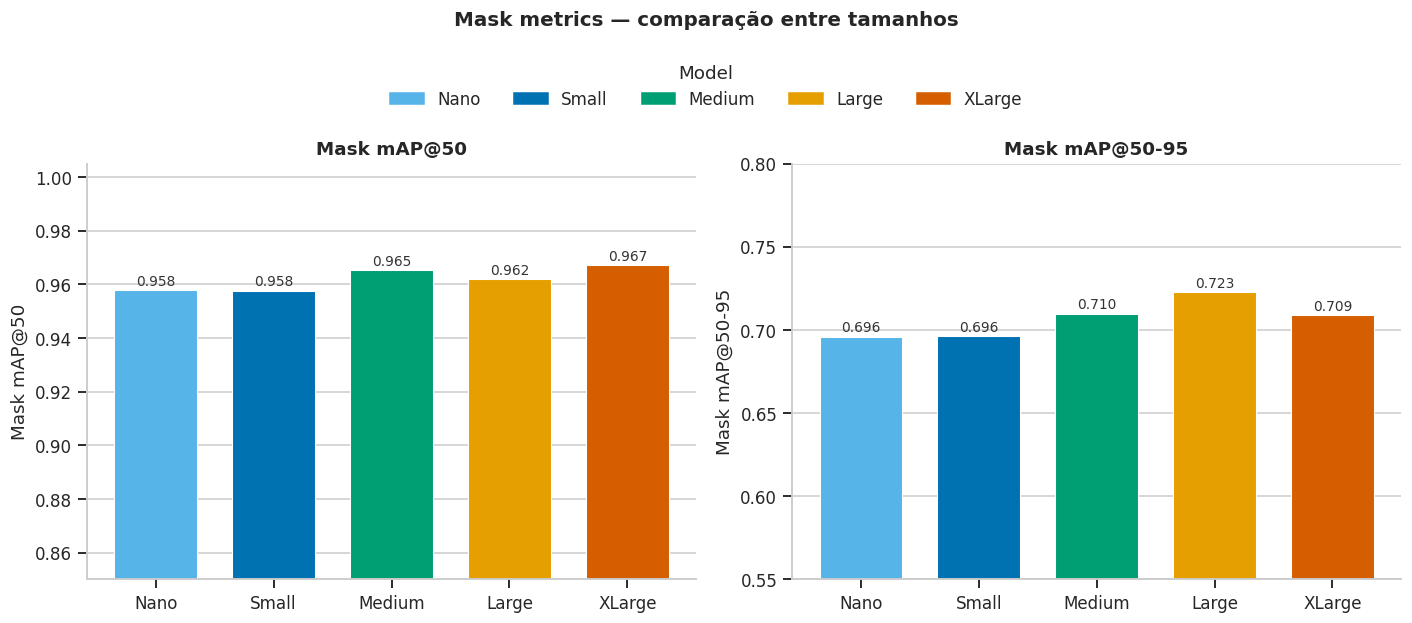

In [6]:
def model_bar(ax, value_col: str, title: str, ylim=None, fmt="{:.3f}"):
    data = df_long.set_index("Model")[value_col].reindex(MODEL_ORDER_PRESENT)
    bars = ax.bar(
        range(len(data)), data.values,
        color=[MODEL_PALETTE[m] for m in data.index],
        edgecolor="white", linewidth=0.7, width=0.7,
    )
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.index, rotation=0)
    ax.set_title(title)
    ax.set_ylabel(value_col)
    ax.set_xlabel("")
    if ylim:
        ax.set_ylim(*ylim)
    add_value_labels(ax, fmt=fmt)
    ax.grid(axis="x", visible=False)


# ---- Mask -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
model_bar(axes[0], "Mask mAP@50",    "Mask mAP@50",    ylim=(0.85, 1.005))
model_bar(axes[1], "Mask mAP@50-95", "Mask mAP@50-95", ylim=(0.55, 0.80))

handles = [Patch(color=MODEL_PALETTE[m], label=m) for m in MODEL_ORDER_PRESENT]
fig.legend(handles=handles, title="Model", loc="upper center",
           bbox_to_anchor=(0.5, 1.06), ncol=len(MODEL_ORDER_PRESENT))
fig.suptitle("Mask metrics — comparação entre tamanhos", y=1.13, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


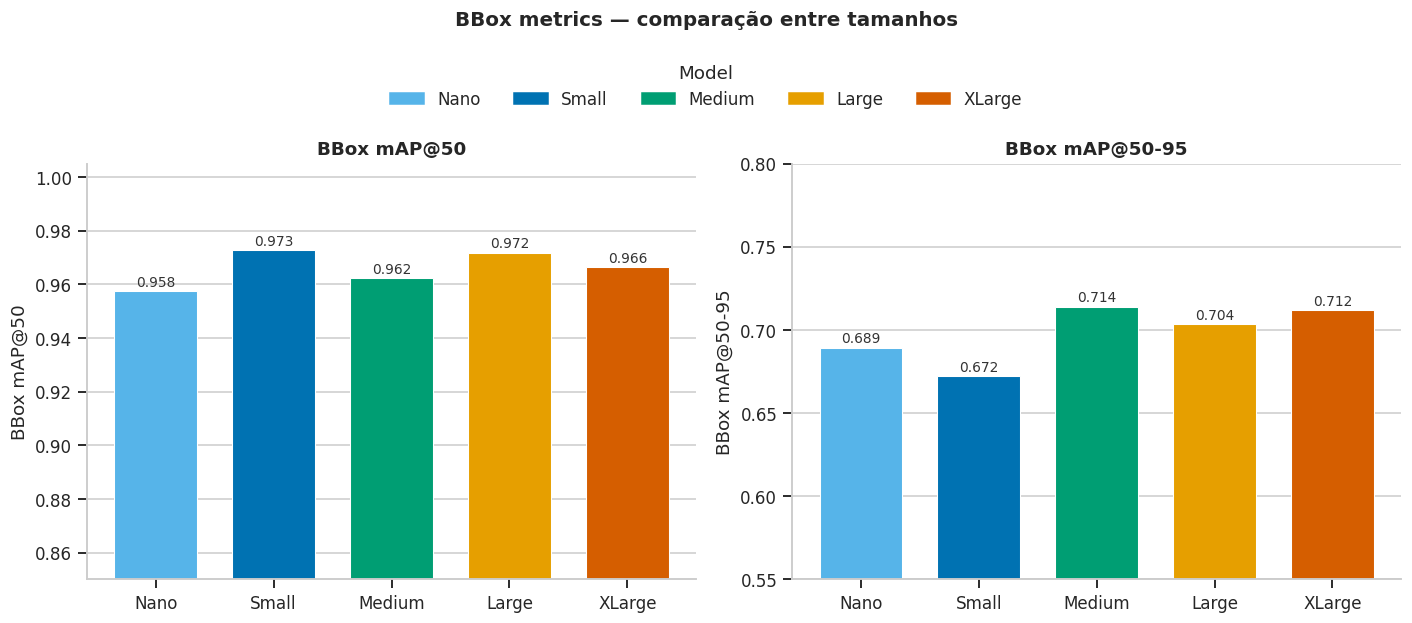

In [7]:
# ---- BBox -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
model_bar(axes[0], "BBox mAP@50",    "BBox mAP@50",    ylim=(0.85, 1.005))
model_bar(axes[1], "BBox mAP@50-95", "BBox mAP@50-95", ylim=(0.55, 0.80))

handles = [Patch(color=MODEL_PALETTE[m], label=m) for m in MODEL_ORDER_PRESENT]
fig.legend(handles=handles, title="Model", loc="upper center",
           bbox_to_anchor=(0.5, 1.06), ncol=len(MODEL_ORDER_PRESENT))
fig.suptitle("BBox metrics — comparação entre tamanhos", y=1.13, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Métricas operacionais

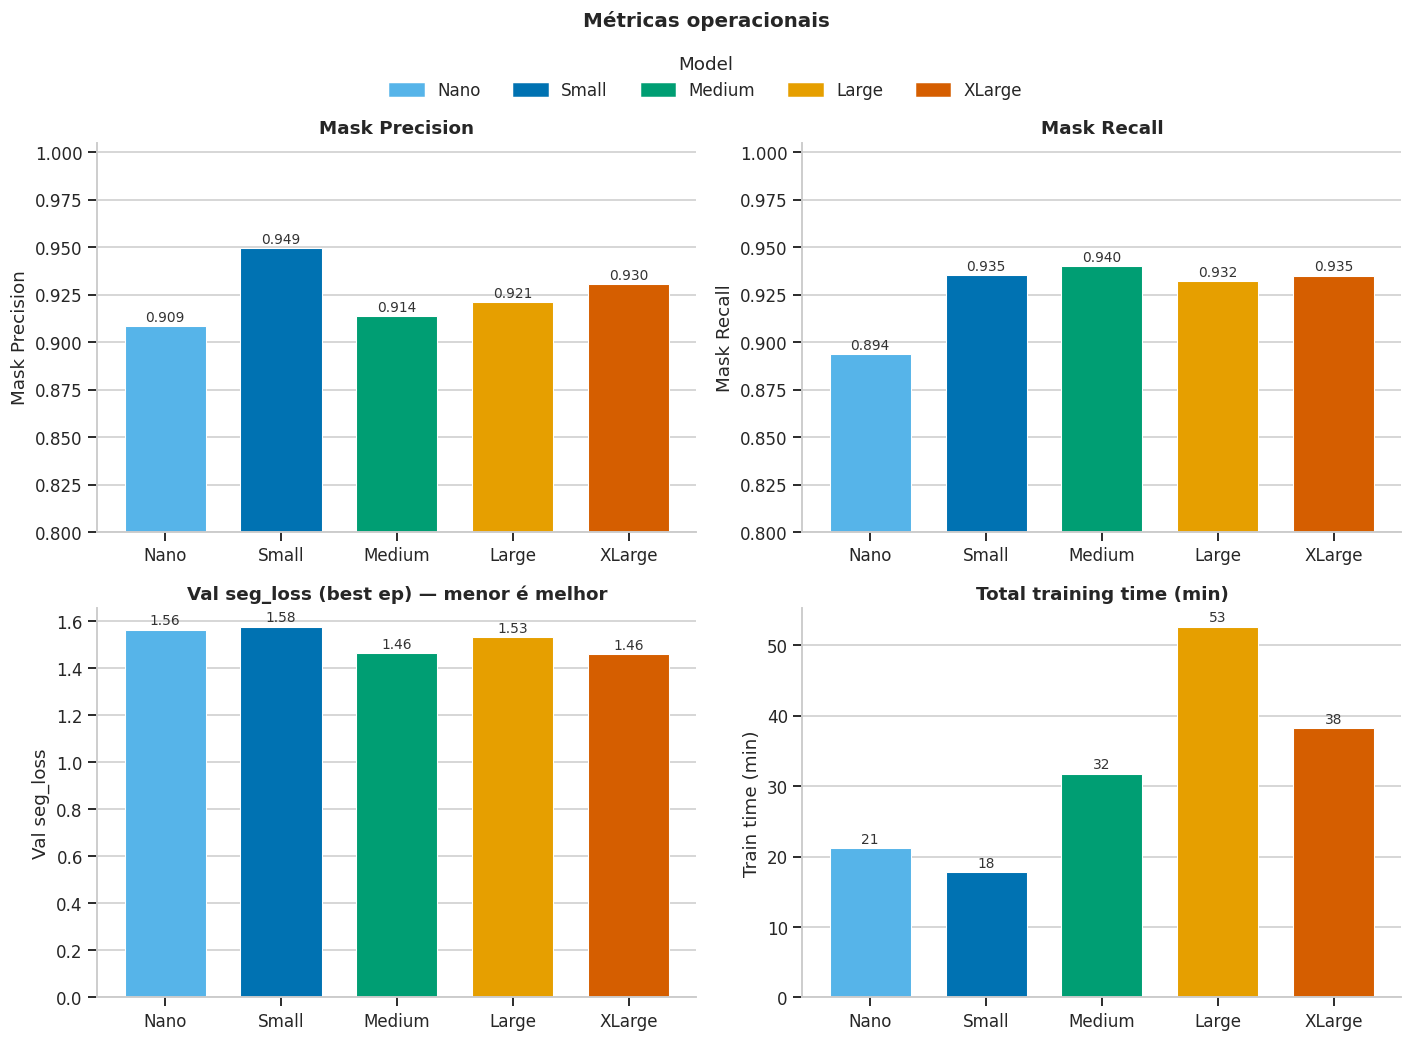

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
model_bar(axes[0, 0], "Mask Precision", "Mask Precision", ylim=(0.80, 1.005))
model_bar(axes[0, 1], "Mask Recall",    "Mask Recall",    ylim=(0.80, 1.005))
model_bar(axes[1, 0], "Val seg_loss",   "Val seg_loss (best ep) — menor é melhor", fmt="{:.2f}")
model_bar(axes[1, 1], "Train time (min)", "Total training time (min)", fmt="{:.0f}")

handles = [Patch(color=MODEL_PALETTE[m], label=m) for m in MODEL_ORDER_PRESENT]
fig.legend(handles=handles, title="Model", loc="upper center",
           bbox_to_anchor=(0.5, 1.02), ncol=len(MODEL_ORDER_PRESENT))
fig.suptitle("Métricas operacionais", y=1.05, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Robustez geométrica — `mAP@50-95 / mAP@50`

Quanto da localização (mAP@50) sobrevive ao critério mais rigoroso (mAP@50-95)?
Modelos maiores costumam manter mais — proxy direto de qualidade da borda.


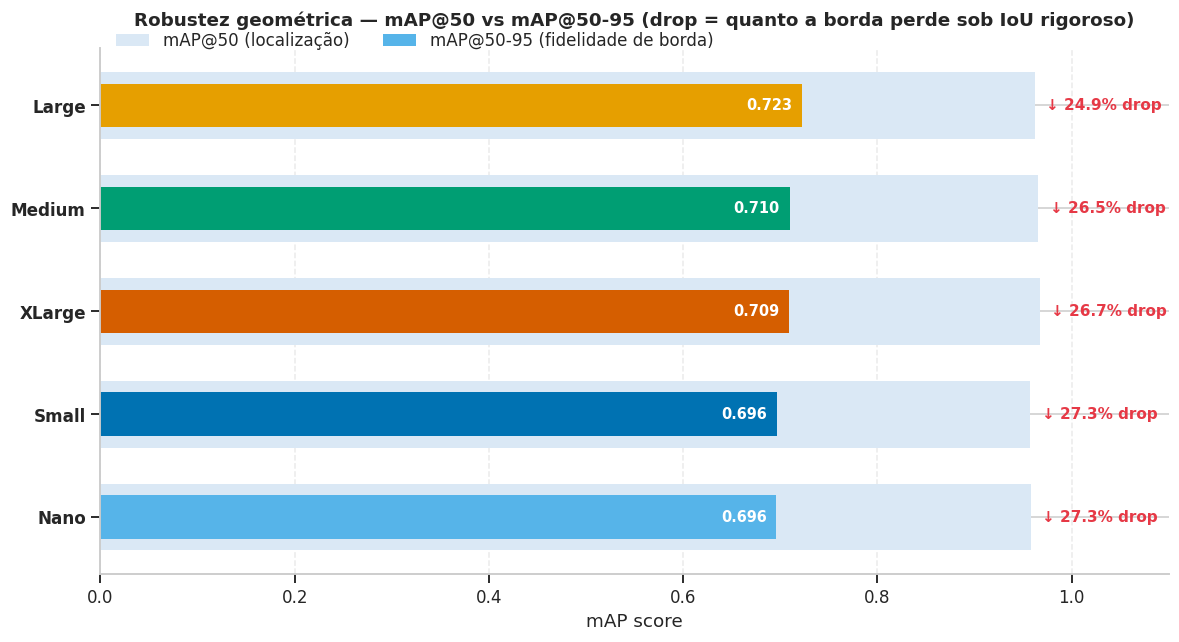

In [9]:
df_long["Mask retention"] = df_long["Mask mAP@50-95"] / df_long["Mask mAP@50"]
df_long["BBox retention"] = df_long["BBox mAP@50-95"] / df_long["BBox mAP@50"]
df_long["Mask drop %"] = (1 - df_long["Mask retention"]) * 100

# Bar plot horizontal estilo Tufte
df_plot = df_long.sort_values("Mask mAP@50-95", ascending=True)

fig, ax = plt.subplots(figsize=(11, 0.9 * len(df_plot) + 1.5))

y_pos = np.arange(len(df_plot))
colors_50 = ["#dae8f5"] * len(df_plot)        # cinza-azul (background)
colors_95 = [MODEL_PALETTE[m] for m in df_plot["Model"]]

ax.barh(y_pos, df_plot["Mask mAP@50"].values, color=colors_50,
        height=0.65, label="mAP@50 (localização)")
ax.barh(y_pos, df_plot["Mask mAP@50-95"].values, color=colors_95,
        height=0.42, label="mAP@50-95 (fidelidade de borda)")

for i, (_, r) in enumerate(df_plot.iterrows()):
    ax.text(r["Mask mAP@50"] + 0.012, i, f"↓ {r['Mask drop %']:.1f}% drop",
            va="center", color=DANGER, fontweight="bold", fontsize=10)
    ax.text(r["Mask mAP@50-95"] - 0.01, i, f"{r['Mask mAP@50-95']:.3f}",
            va="center", ha="right", color="white", fontweight="bold", fontsize=9.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot["Model"].astype(str), fontweight="bold", fontsize=11)
ax.set_xlabel("mAP score")
ax.set_title("Robustez geométrica — mAP@50 vs mAP@50-95 (drop = quanto a borda perde sob IoU rigoroso)",
             fontsize=12, pad=15)
ax.set_xlim(0, 1.1)
ax.legend(loc="upper left", bbox_to_anchor=(0, 1.06), ncol=2)
ax.xaxis.grid(True, ls="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 8. Estabilidade do treino

Std de `mAP@50-95(M)` nas últimas 10 épocas — modelos maiores tendem a ser
mais sensíveis a hiperparâmetros e oscilar mais.


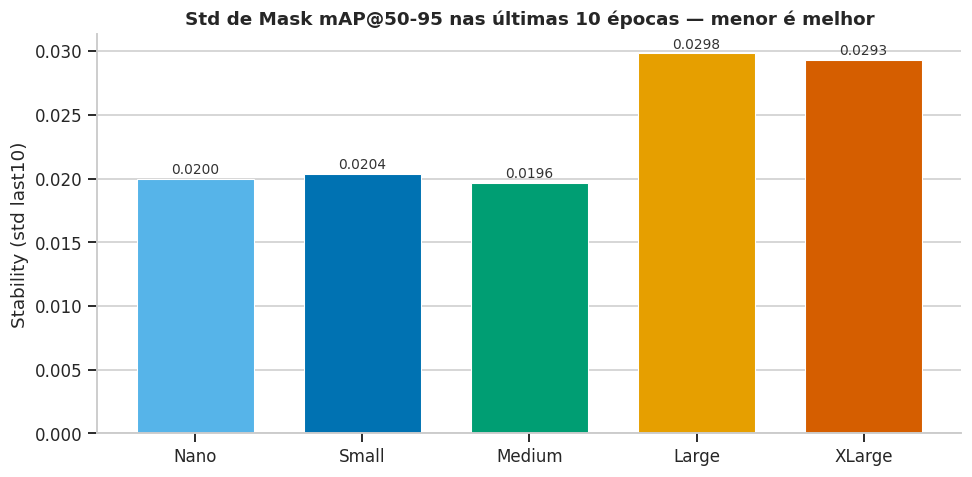

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
model_bar(ax, "Stability (std last10)",
          "Std de Mask mAP@50-95 nas últimas 10 épocas — menor é melhor", fmt="{:.4f}")
plt.tight_layout()
plt.show()


## 9. Convergência

Em qual época cada modelo atingiu 95% / 99% do seu próprio best?


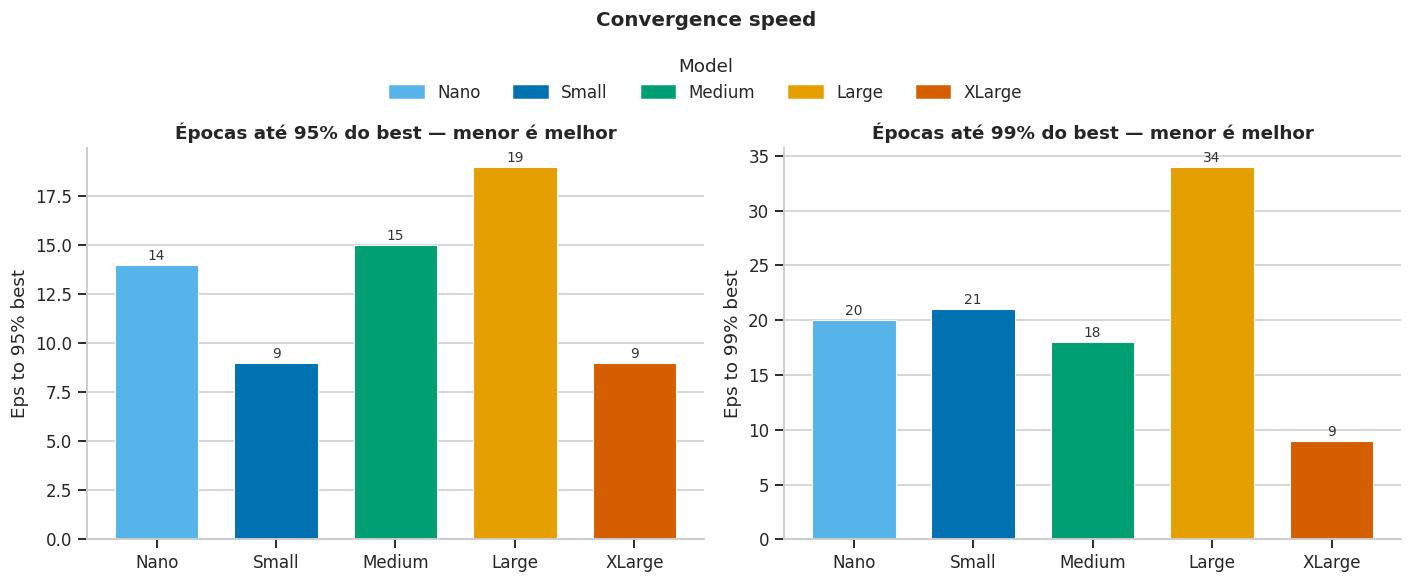

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
model_bar(axes[0], "Eps to 95% best", "Épocas até 95% do best — menor é melhor", fmt="{:.0f}")
model_bar(axes[1], "Eps to 99% best", "Épocas até 99% do best — menor é melhor", fmt="{:.0f}")

handles = [Patch(color=MODEL_PALETTE[m], label=m) for m in MODEL_ORDER_PRESENT]
fig.legend(handles=handles, title="Model", loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=len(MODEL_ORDER_PRESENT))
fig.suptitle("Convergence speed", y=1.10, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Curvas de treino

`mAP@50-95(M)` (esquerda) e `val/seg_loss` (direita) ao longo das épocas, suavizado.


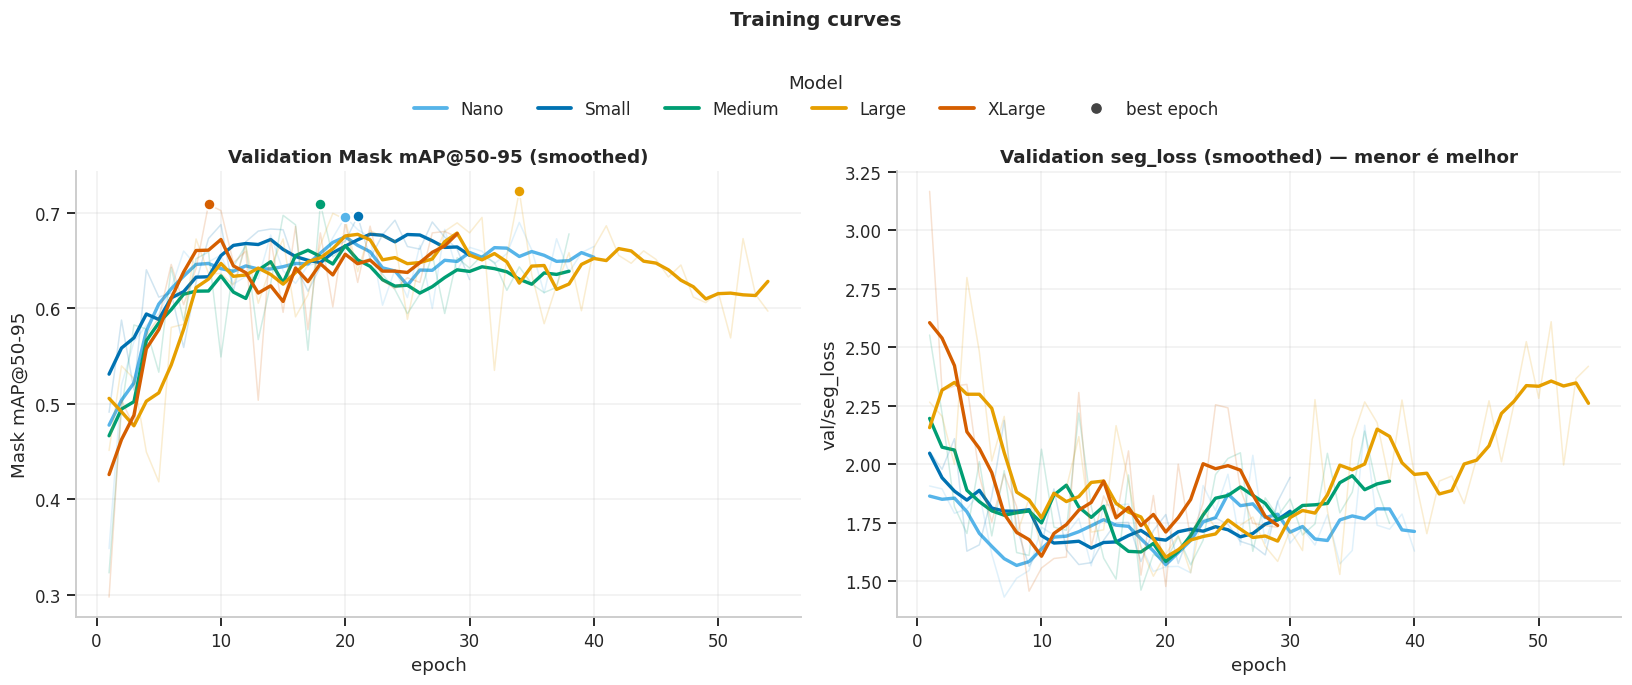

In [12]:
WINDOW = 5
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for m in MODEL_ORDER_PRESENT:
    sel = df_long[df_long["Model"] == m]
    if sel.empty:
        continue
    df = sel.iloc[0]["_df"]
    eps = df["epoch"].to_numpy()
    c = MODEL_PALETTE[m]
    if "metrics/mAP50-95(M)" in df:
        y = df["metrics/mAP50-95(M)"].to_numpy()
        axes[0].plot(eps, y, color=c, alpha=0.18, lw=1)
        axes[0].plot(eps, smooth(y, WINDOW), color=c, lw=2.2, label=m)
        b = int(np.argmax(y))
        axes[0].scatter([eps[b]], [y[b]], color=c, s=55, zorder=5, edgecolor="white", lw=1.2)
    if "val/seg_loss" in df:
        loss = df["val/seg_loss"].to_numpy()
        axes[1].plot(eps, loss, color=c, alpha=0.18, lw=1)
        axes[1].plot(eps, smooth(loss, WINDOW), color=c, lw=2.2, label=m)

axes[0].set_title("Validation Mask mAP@50-95 (smoothed)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("Mask mAP@50-95")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation seg_loss (smoothed) — menor é melhor")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val/seg_loss")
axes[1].grid(True, alpha=0.3)

handles = [
    plt.Line2D([0], [0], color=MODEL_PALETTE[m], lw=2.5, label=m) for m in MODEL_ORDER_PRESENT
]
handles.append(plt.Line2D([0], [0], marker="o", color="#444", markersize=8, lw=0,
                          markeredgecolor="white", label="best epoch"))
fig.legend(handles=handles, title="Model", loc="upper center",
           bbox_to_anchor=(0.5, 1.05), ncol=len(MODEL_ORDER_PRESENT) + 1)
fig.suptitle("Training curves", y=1.13, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 11. Train vs Val seg_loss

Linha sólida = train, tracejada = val. Gap final = sinal de overfit.
Modelos maiores tendem a overfittar mais em datasets pequenos.


### Overfit gap (val − train seg_loss no best ep)

,Overfit gap (seg)
Model,
Nano,-0.042
Small,+0.018
Medium,-0.174
Large,+0.134
XLarge,-0.178


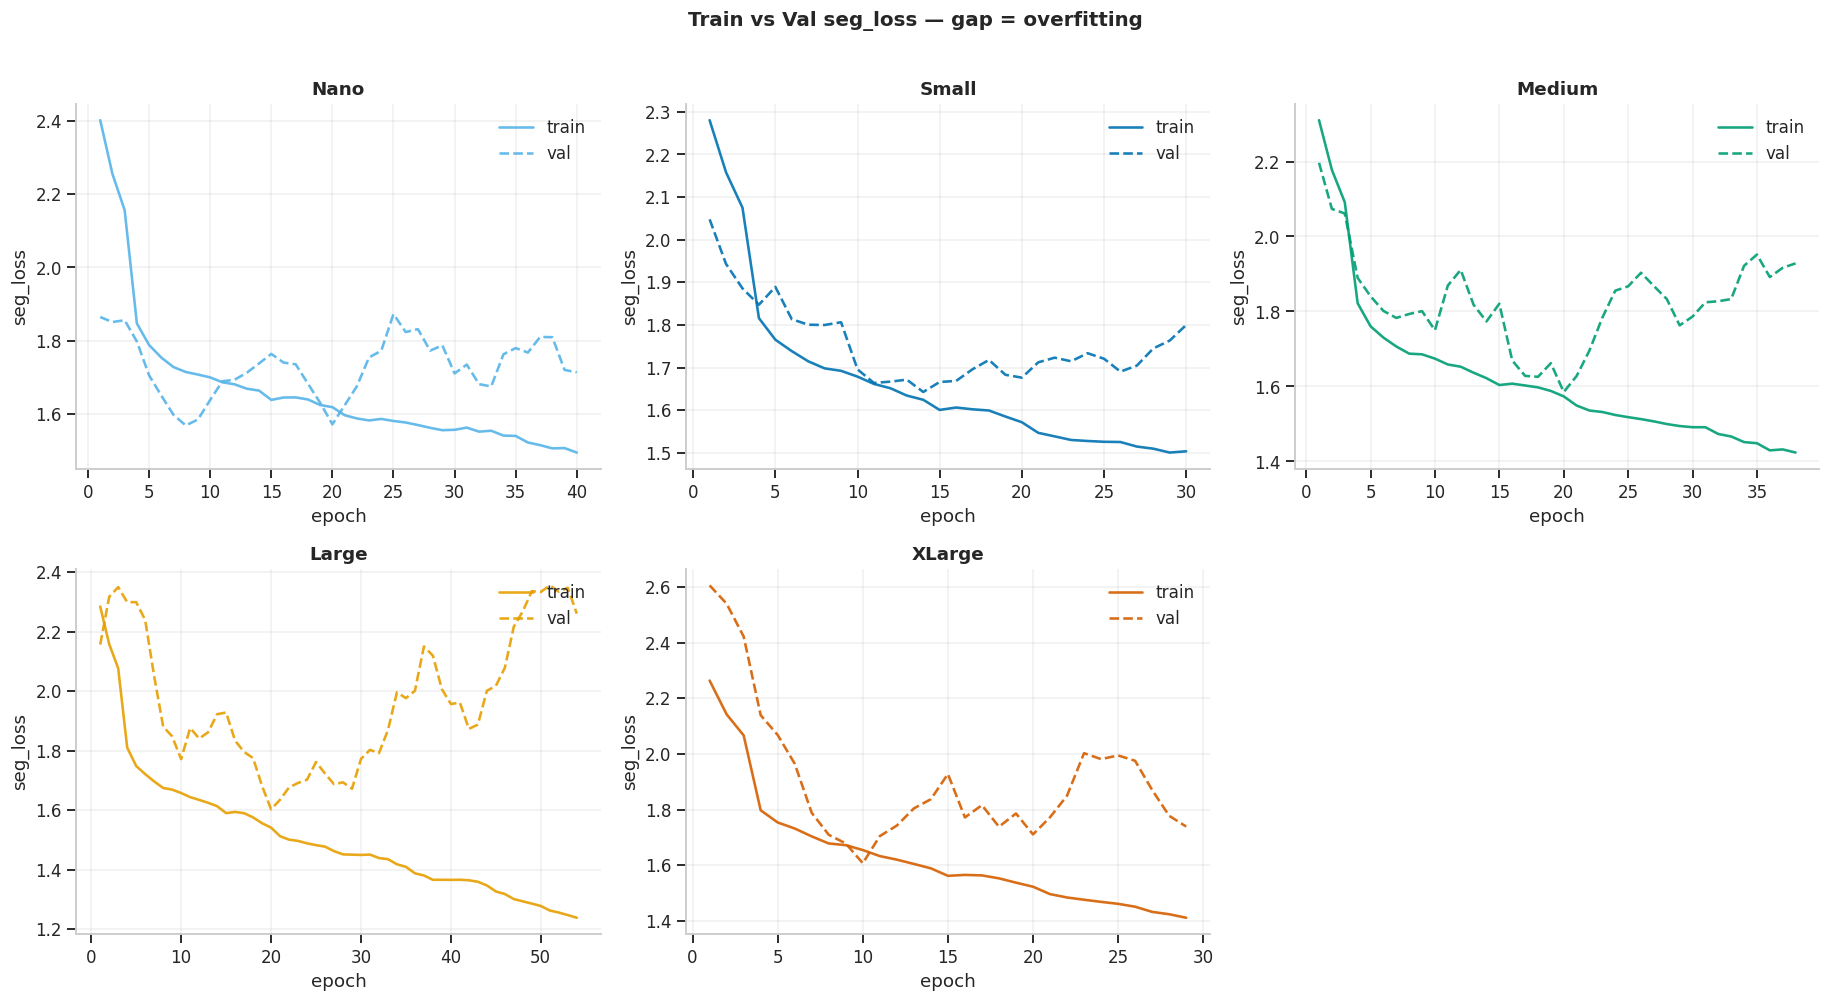

In [13]:
n = len(MODEL_ORDER_PRESENT)
ncols = min(3, max(1, n))
nrows = int(np.ceil((n + 1) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 4.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, m in enumerate(MODEL_ORDER_PRESENT):
    ax = axes_flat[i]
    sel = df_long[df_long["Model"] == m]
    if sel.empty:
        continue
    df = sel.iloc[0]["_df"]
    if "train/seg_loss" not in df or "val/seg_loss" not in df:
        continue
    eps = df["epoch"].to_numpy()
    c = MODEL_PALETTE[m]
    ax.plot(eps, smooth(df["train/seg_loss"].to_numpy(), 5),
            color=c, lw=1.7, alpha=0.9, label="train")
    ax.plot(eps, smooth(df["val/seg_loss"].to_numpy(), 5),
            color=c, lw=1.7, alpha=0.9, ls="--", label="val")
    ax.set_title(m)
    ax.set_xlabel("epoch")
    ax.set_ylabel("seg_loss")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

for j in range(n, len(axes_flat) - 1):
    axes_flat[j].axis("off")
axes_flat[-1].axis("off")

# Tabela: overfit gap
display(Markdown("### Overfit gap (val − train seg_loss no best ep)"))
gap_df = df_long.set_index("Model")[["Overfit gap (seg)"]].reindex(MODEL_ORDER_PRESENT)
display(gap_df.style.format("{:+.3f}").background_gradient(cmap="RdYlGn_r"))

fig.suptitle("Train vs Val seg_loss — gap = overfitting", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 12. LR efetivo (`lr/pg0` no meio do treino)

Como todos os modelos usam o mesmo `lr0` nominal, o LR efetivo no meio do
run deve ficar próximo entre eles. Diferenças significativas indicam que
o cosine schedule pegou cada um em momento diferente do treino.


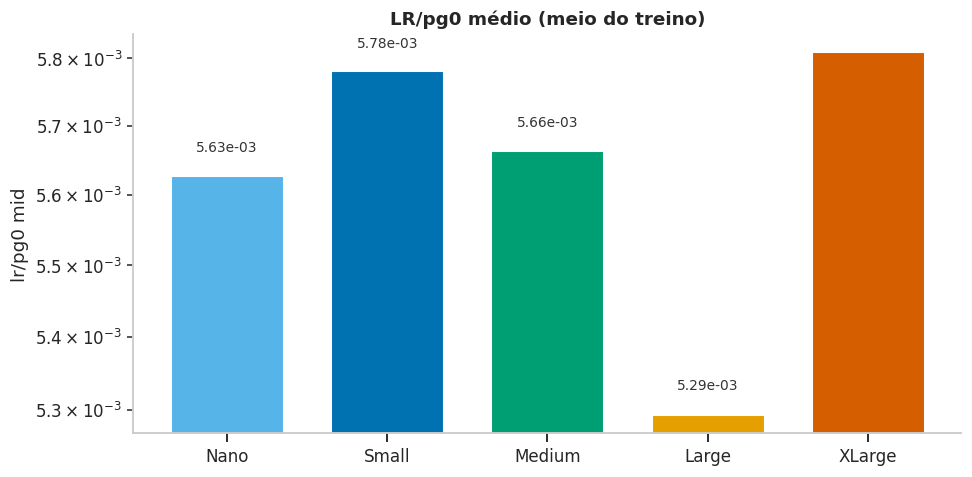

### LR diagnostics (start / mid / end)

,lr/pg0 start,lr/pg0 mid,lr/pg0 end
Model,,,
Nano,4.48e-03,5.63e-03,4.68e-03
Small,3.97e-03,5.78e-03,5.24e-03
Medium,3.97e-03,5.66e-03,4.78e-03
Large,4.78e-03,5.29e-03,3.72e-03
XLarge,2.97e-03,5.81e-03,5.26e-03


In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
model_bar(ax, "lr/pg0 mid", "LR/pg0 médio (meio do treino)", fmt="{:.2e}")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

display(Markdown("### LR diagnostics (start / mid / end)"))
display(
    df_long.set_index("Model")[["lr/pg0 start", "lr/pg0 mid", "lr/pg0 end"]]
    .reindex(MODEL_ORDER_PRESENT).style.format("{:.2e}", na_rep="—")
)


## 13. Scaling: mAP × tamanho do modelo

Curva log-x: como `mAP@50-95(M)` varia com o número de parâmetros?
Plotagem de **eficiência** (mAP por minuto de treino e mAP por milhão de
parâmetros) ajuda a escolher o melhor custo-benefício.


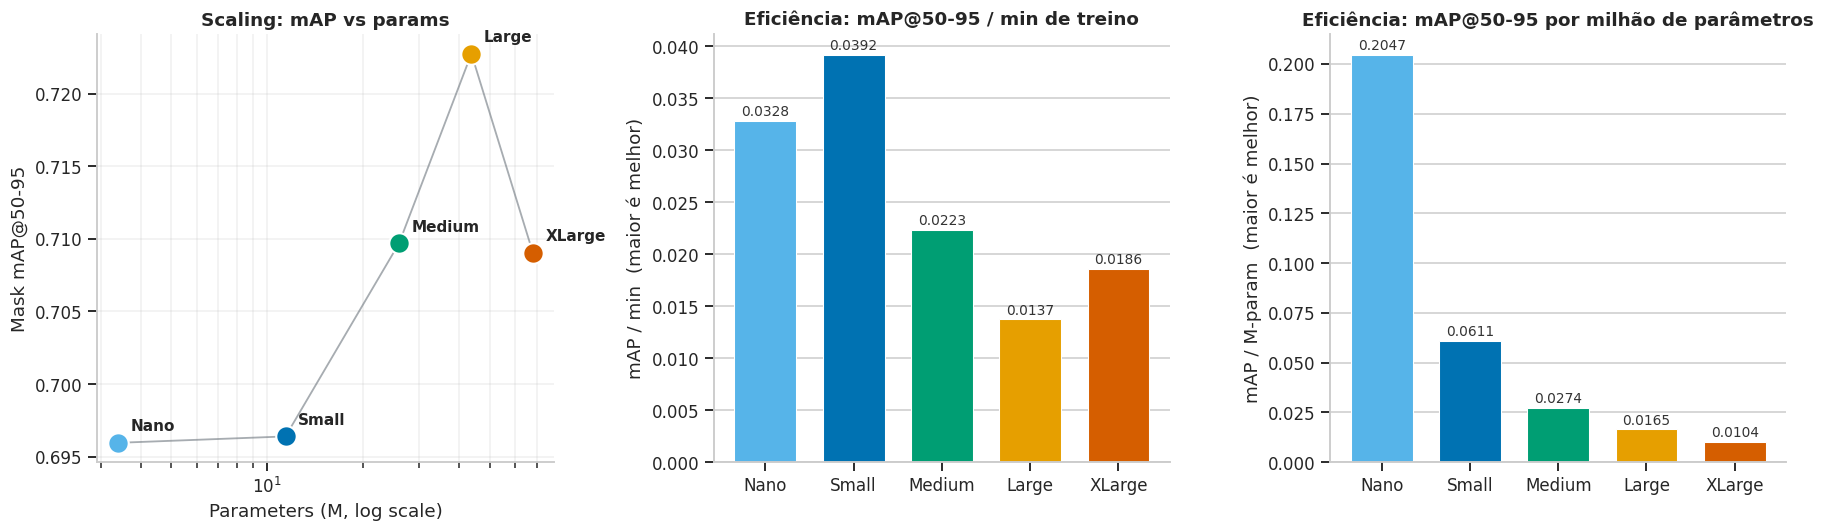

In [15]:
df_long["mAP / min"]      = df_long["Mask mAP@50-95"] / df_long["Train time (min)"]
df_long["mAP / M-param"]   = df_long["Mask mAP@50-95"] / df_long["Params (M)"]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))

# (a) mAP vs params (log)
ax = axes[0]
sub = df_long.dropna(subset=["Params (M)", "Mask mAP@50-95"])
ax.plot(sub["Params (M)"], sub["Mask mAP@50-95"], "-", color=NEUTRAL, alpha=0.6, lw=1.2, zorder=1)
for _, r in sub.iterrows():
    ax.scatter(r["Params (M)"], r["Mask mAP@50-95"],
               s=180, color=MODEL_PALETTE[r["Model"]], edgecolor="white", lw=1.4, zorder=2)
    ax.annotate(r["Model"], (r["Params (M)"], r["Mask mAP@50-95"]),
                xytext=(8, 8), textcoords="offset points", fontsize=10, fontweight="bold")
ax.set_xscale("log")
ax.set_xlabel("Parameters (M, log scale)")
ax.set_ylabel("Mask mAP@50-95")
ax.set_title("Scaling: mAP vs params")
ax.grid(True, alpha=0.3, which="both")

# (b) mAP / min (eficiência de treino)
ax = axes[1]
data = df_long.set_index("Model")["mAP / min"].reindex(MODEL_ORDER_PRESENT)
ax.bar(range(len(data)), data.values,
       color=[MODEL_PALETTE[m] for m in data.index],
       edgecolor="white", linewidth=0.7, width=0.7)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index)
ax.set_title("Eficiência: mAP@50-95 / min de treino")
ax.set_ylabel("mAP / min  (maior é melhor)")
ax.grid(axis="x", visible=False)
add_value_labels(ax, fmt="{:.4f}")

# (c) mAP / M-param (eficiência por parâmetro)
ax = axes[2]
data = df_long.set_index("Model")["mAP / M-param"].reindex(MODEL_ORDER_PRESENT)
ax.bar(range(len(data)), data.values,
       color=[MODEL_PALETTE[m] for m in data.index],
       edgecolor="white", linewidth=0.7, width=0.7)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data.index)
ax.set_title("Eficiência: mAP@50-95 por milhão de parâmetros")
ax.set_ylabel("mAP / M-param  (maior é melhor)")
ax.grid(axis="x", visible=False)
add_value_labels(ax, fmt="{:.4f}")

plt.tight_layout()
plt.show()


## 14. Pareto: `mAP@50-95` × `Train time`

Identifica modelos dominados (mais lentos OU menos precisos que outro).


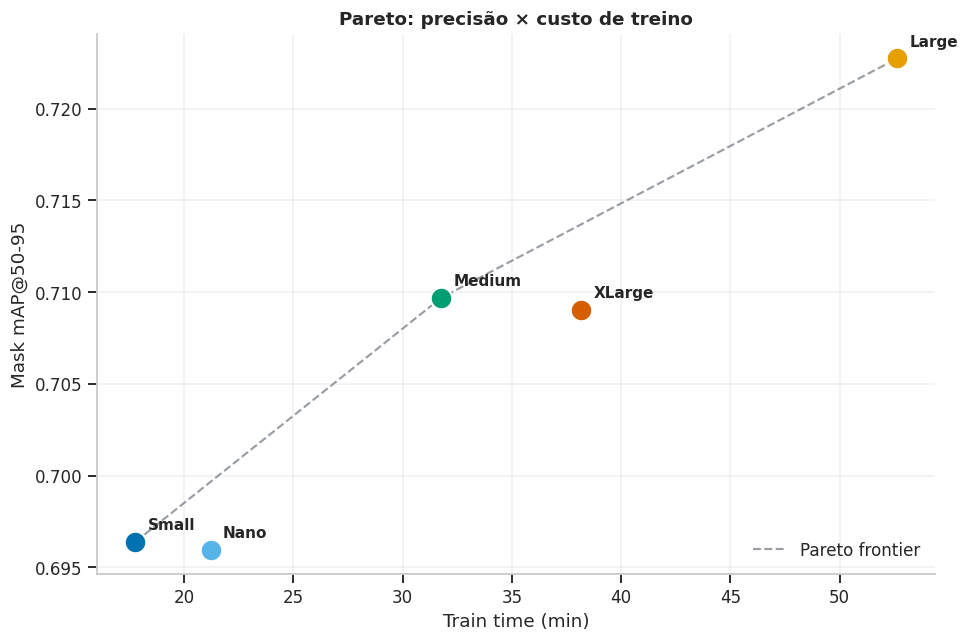

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

for _, r in df_long.iterrows():
    ax.scatter(r["Train time (min)"], r["Mask mAP@50-95"],
               s=200, color=MODEL_PALETTE[r["Model"]],
               edgecolor="white", linewidth=1.4, zorder=3)
    ax.annotate(r["Model"], (r["Train time (min)"], r["Mask mAP@50-95"]),
                xytext=(8, 8), textcoords="offset points",
                fontsize=10, fontweight="bold")

# Pareto frontier
pf = df_long.dropna(subset=["Train time (min)", "Mask mAP@50-95"]).sort_values("Train time (min)")
front = []; best_y = -np.inf
for _, r in pf.iterrows():
    if r["Mask mAP@50-95"] > best_y:
        front.append((r["Train time (min)"], r["Mask mAP@50-95"]))
        best_y = r["Mask mAP@50-95"]
if len(front) >= 2:
    fx, fy = zip(*front)
    ax.plot(fx, fy, color=NEUTRAL, ls="--", lw=1.4, alpha=0.7, label="Pareto frontier")
    ax.legend(loc="lower right")

ax.set_xlabel("Train time (min)")
ax.set_ylabel("Mask mAP@50-95")
ax.set_title("Pareto: precisão × custo de treino")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Diff de hiperparâmetros entre runs

Espera-se que **todos os runs usem a mesma config v7**, diferindo apenas no
peso pré-treinado. Se algum hiperparâmetro divergir, esta tabela destaca.


In [17]:
hp_cols = ["optimizer", "lr0", "amp", "batch", "epochs (cfg)",
           "close_mosaic", "erasing", "weight_decay", "dropout"]
hp = df_long.set_index("Model")[hp_cols].T.reindex(columns=MODEL_ORDER_PRESENT)


def style_diff(row: pd.Series):
    if row.dropna().empty:
        return ["" for _ in row]
    ref = row.dropna().iloc[0]
    return ["background-color: #FFF3CD" if (str(v) != str(ref)) else "" for v in row]


display(Markdown("### Hiperparâmetros chave (esperado: tudo igual entre modelos)"))
display(hp.style.apply(style_diff, axis=1).set_caption("Amarelo = difere do primeiro modelo"))


### Hiperparâmetros chave (esperado: tudo igual entre modelos)

Model,Nano,Small,Medium,Large,XLarge
optimizer,MuSGD,MuSGD,MuSGD,MuSGD,MuSGD
lr0,0.002000,0.002000,0.002000,0.002000,0.002000
amp,True,True,True,True,True
batch,32,32,32,32,32
epochs (cfg),120,120,120,120,120
close_mosaic,15,15,15,15,15
erasing,0.000000,0.000000,0.000000,0.000000,0.000000
weight_decay,0.000500,0.000500,0.000500,0.000500,0.000500
dropout,0.000000,0.000000,0.000000,0.000000,0.000000


## 16. Insights automáticos

In [18]:
insights = []

# 1. Champion
champ = df_long.loc[df_long["Mask mAP@50-95"].idxmax()]
insights.append(
    f"**Champion**: `{champ['Model']}` com Mask mAP@50-95 = "
    f"**{champ['Mask mAP@50-95']:.4f}** (best ep {champ['Best epoch']})."
)

# 2. Best efficiency (mAP / min)
eff_train = df_long.dropna(subset=["mAP / min"])
if not eff_train.empty:
    e = eff_train.loc[eff_train["mAP / min"].idxmax()]
    insights.append(
        f"**Mais eficiente em tempo**: `{e['Model']}` "
        f"({e['mAP / min']:.4f} mAP@50-95 / min)."
    )

# 3. Best params efficiency
eff_p = df_long.dropna(subset=["mAP / M-param"])
if not eff_p.empty:
    e = eff_p.loc[eff_p["mAP / M-param"].idxmax()]
    insights.append(
        f"**Mais eficiente em parâmetros**: `{e['Model']}` "
        f"({e['mAP / M-param']:.4f} mAP / M-param) — sweet spot tamanho × ganho."
    )

# 4. Most stable
stab = df_long.dropna(subset=["Stability (std last10)"])
if not stab.empty:
    s = stab.loc[stab["Stability (std last10)"].idxmin()]
    insights.append(
        f"**Mais estável**: `{s['Model']}` (σ últimas 10 ep = {s['Stability (std last10)']:.4f})."
    )

# 5. Fastest convergence
conv = df_long.dropna(subset=["Eps to 95% best"])
if not conv.empty:
    c = conv.loc[conv["Eps to 95% best"].idxmin()]
    insights.append(
        f"**Convergência mais rápida**: `{c['Model']}` atingiu 95% do best em "
        f"{int(c['Eps to 95% best'])} épocas."
    )

# 6. Diminishing returns?
df_sorted = df_long.dropna(subset=["Params (M)", "Mask mAP@50-95"]).sort_values("Params (M)")
if len(df_sorted) >= 2:
    deltas = df_sorted["Mask mAP@50-95"].diff().dropna()
    if (deltas < 0).any():
        regress = df_sorted.iloc[deltas[deltas < 0].index[0]]
        prev = df_sorted.iloc[deltas[deltas < 0].index[0] - 1] if deltas[deltas < 0].index[0] >= 1 else None
        if prev is not None:
            insights.append(
                f"**⚠ Diminishing returns**: `{regress['Model']}` ({regress['Params (M)']:.1f}M params) "
                f"obteve mAP **menor** que `{prev['Model']}` "
                f"({prev['Mask mAP@50-95']:.4f} → {regress['Mask mAP@50-95']:.4f}). "
                "Modelo maior nem sempre é melhor — possivelmente overfit."
            )

# 7. Best ratio quality/cost
df_long["Quality/Cost"] = df_long["Mask mAP@50-95"] / np.sqrt(df_long["Train time (min)"] * df_long["Params (M)"])
qc = df_long.dropna(subset=["Quality/Cost"])
if not qc.empty:
    q = qc.loc[qc["Quality/Cost"].idxmax()]
    insights.append(
        f"**Melhor custo-benefício** (mAP / √(tempo × params)): `{q['Model']}` "
        f"({q['Quality/Cost']:.4f})."
    )

display(Markdown("### Destaques\n\n" + "\n\n".join(f"- {x}" for x in insights)))


### Destaques

- **Champion**: `Large` com Mask mAP@50-95 = **0.7227** (best ep 34).

- **Mais eficiente em tempo**: `Small` (0.0392 mAP@50-95 / min).

- **Mais eficiente em parâmetros**: `Nano` (0.2047 mAP / M-param) — sweet spot tamanho × ganho.

- **Mais estável**: `Medium` (σ últimas 10 ep = 0.0196).

- **Convergência mais rápida**: `Small` atingiu 95% do best em 9 épocas.

- **⚠ Diminishing returns**: `XLarge` (68.2M params) obteve mAP **menor** que `Large` (0.7227 → 0.7090). Modelo maior nem sempre é melhor — possivelmente overfit.

- **Melhor custo-benefício** (mAP / √(tempo × params)): `Nano` (0.0820).

## 17. Plots nativos do Ultralytics — comparação lado-a-lado

Mostra `results.png`, `MaskF1_curve.png` e `val_batch0_pred.jpg` de cada
modelo lado-a-lado. Útil para inspecionar visualmente como cada modelo se
comporta em validação.


### Qualitative Predictions (Validation)


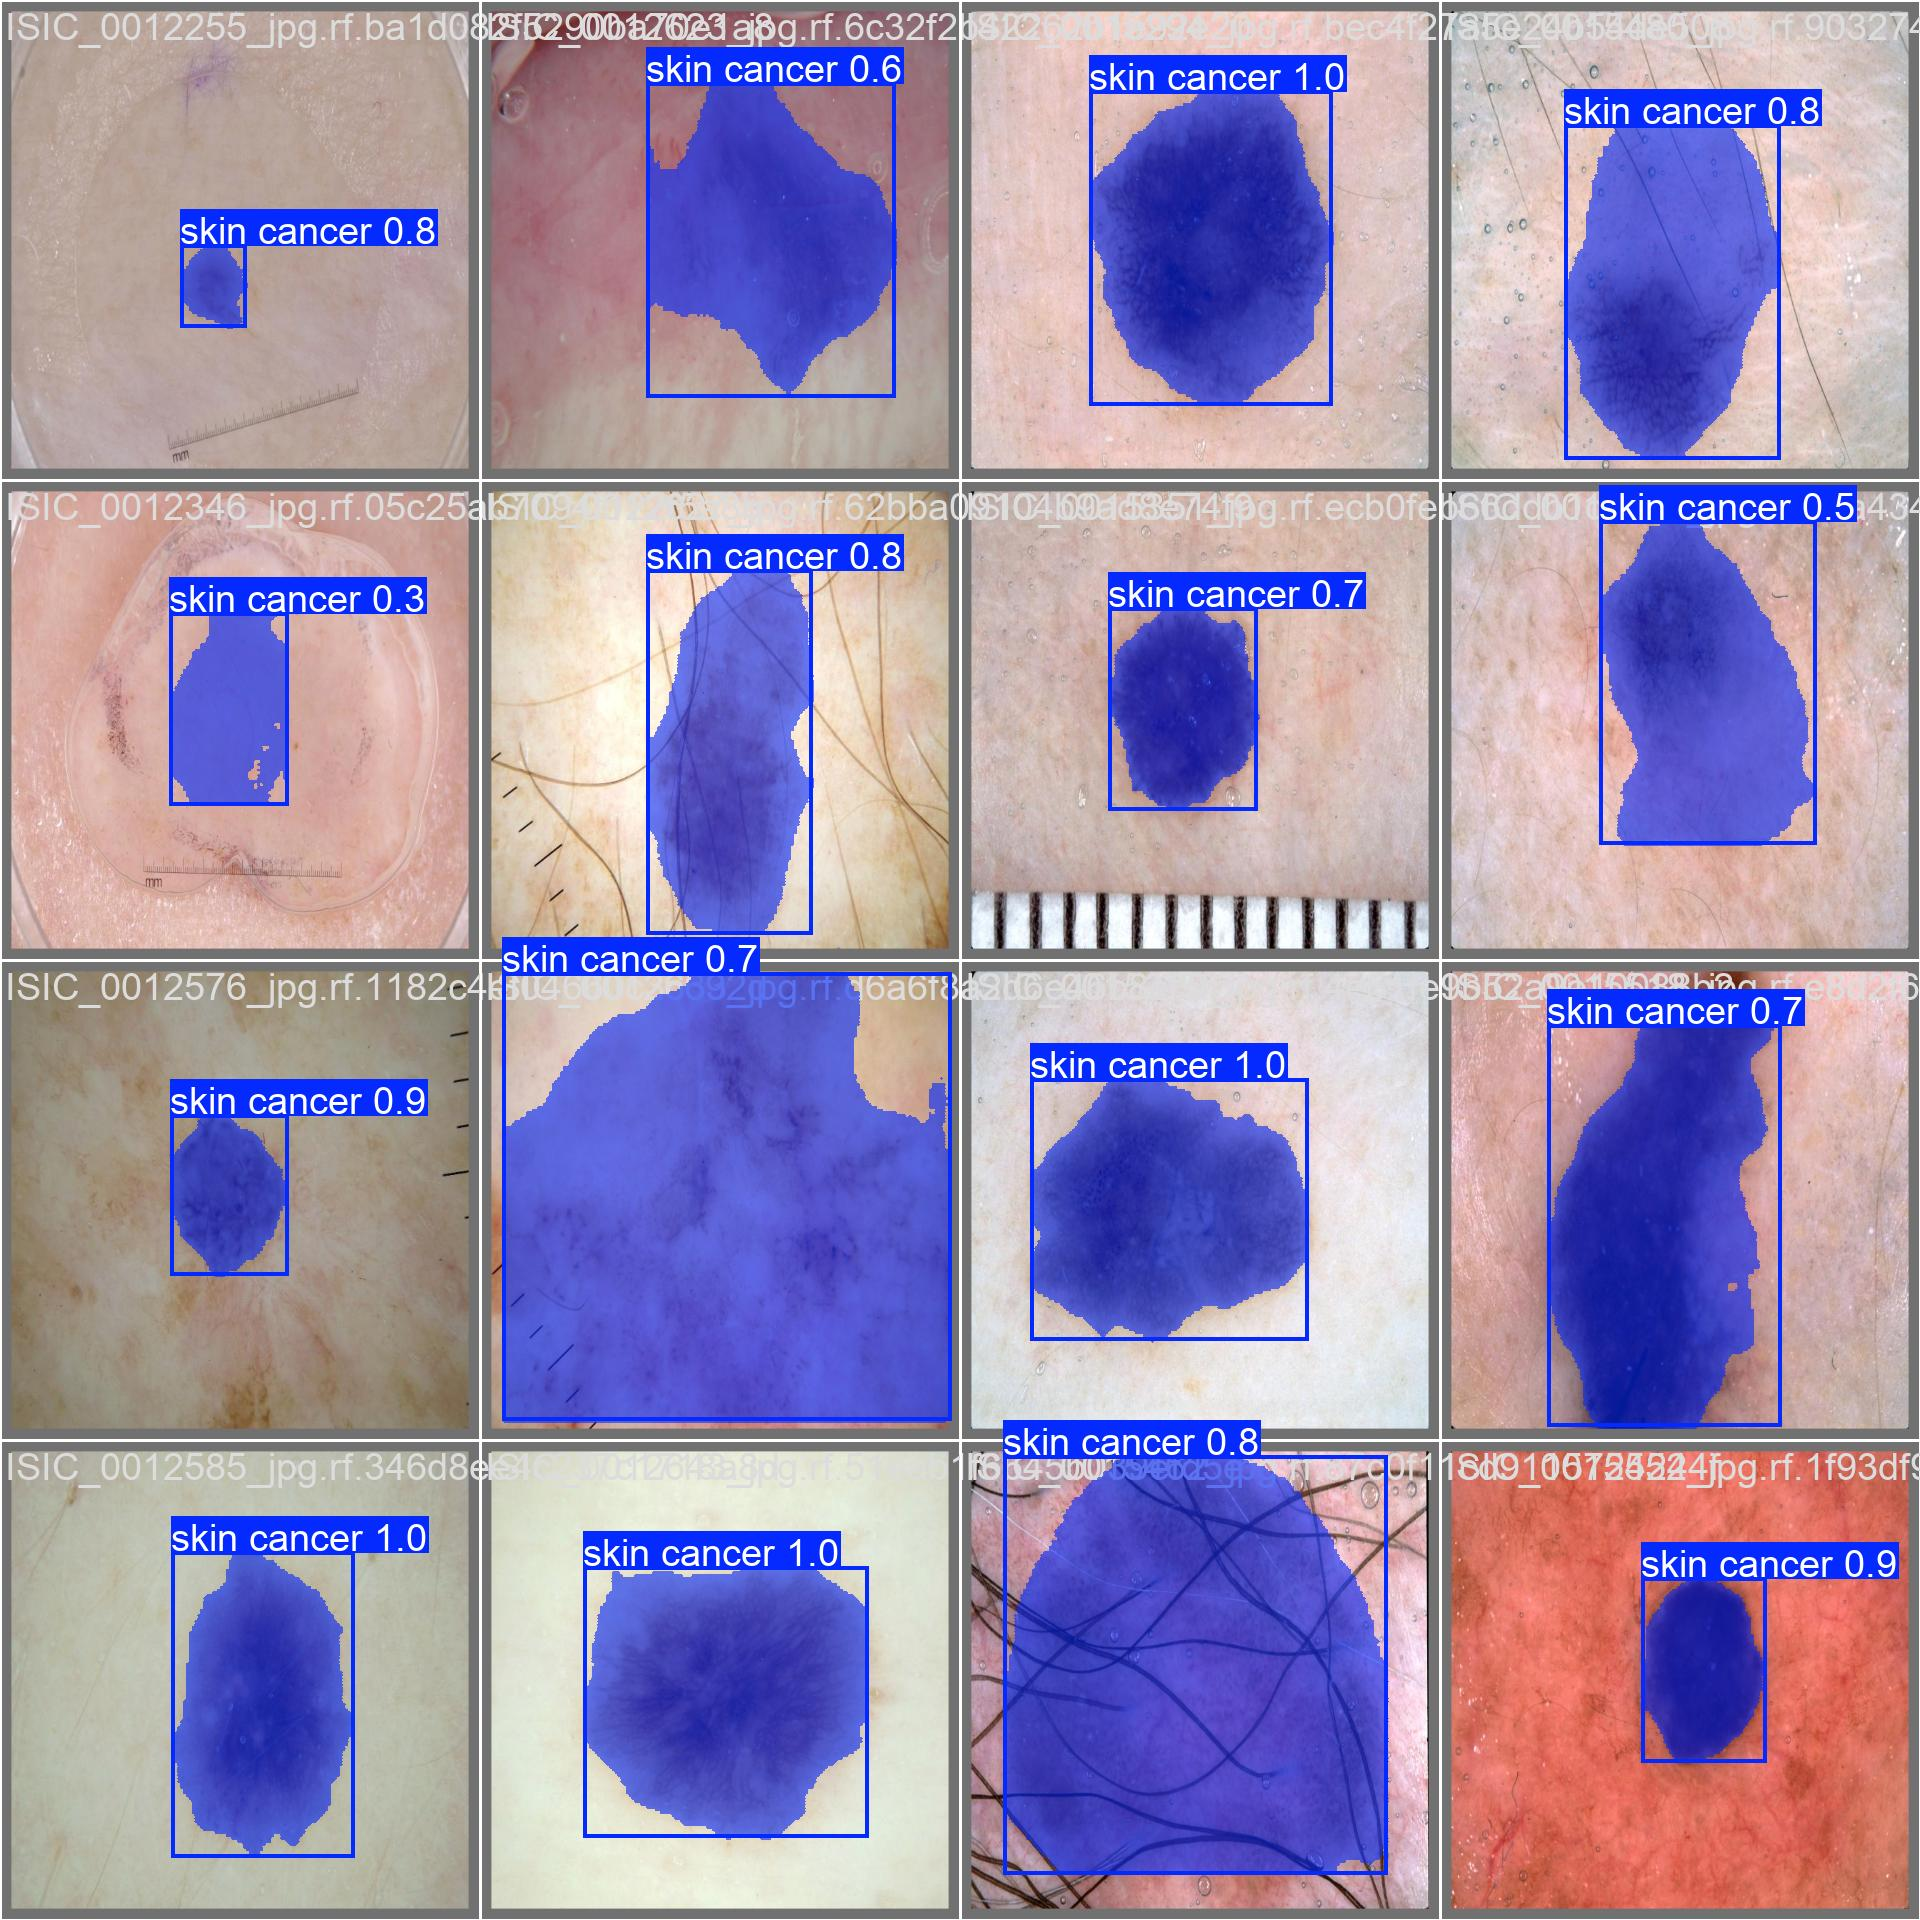
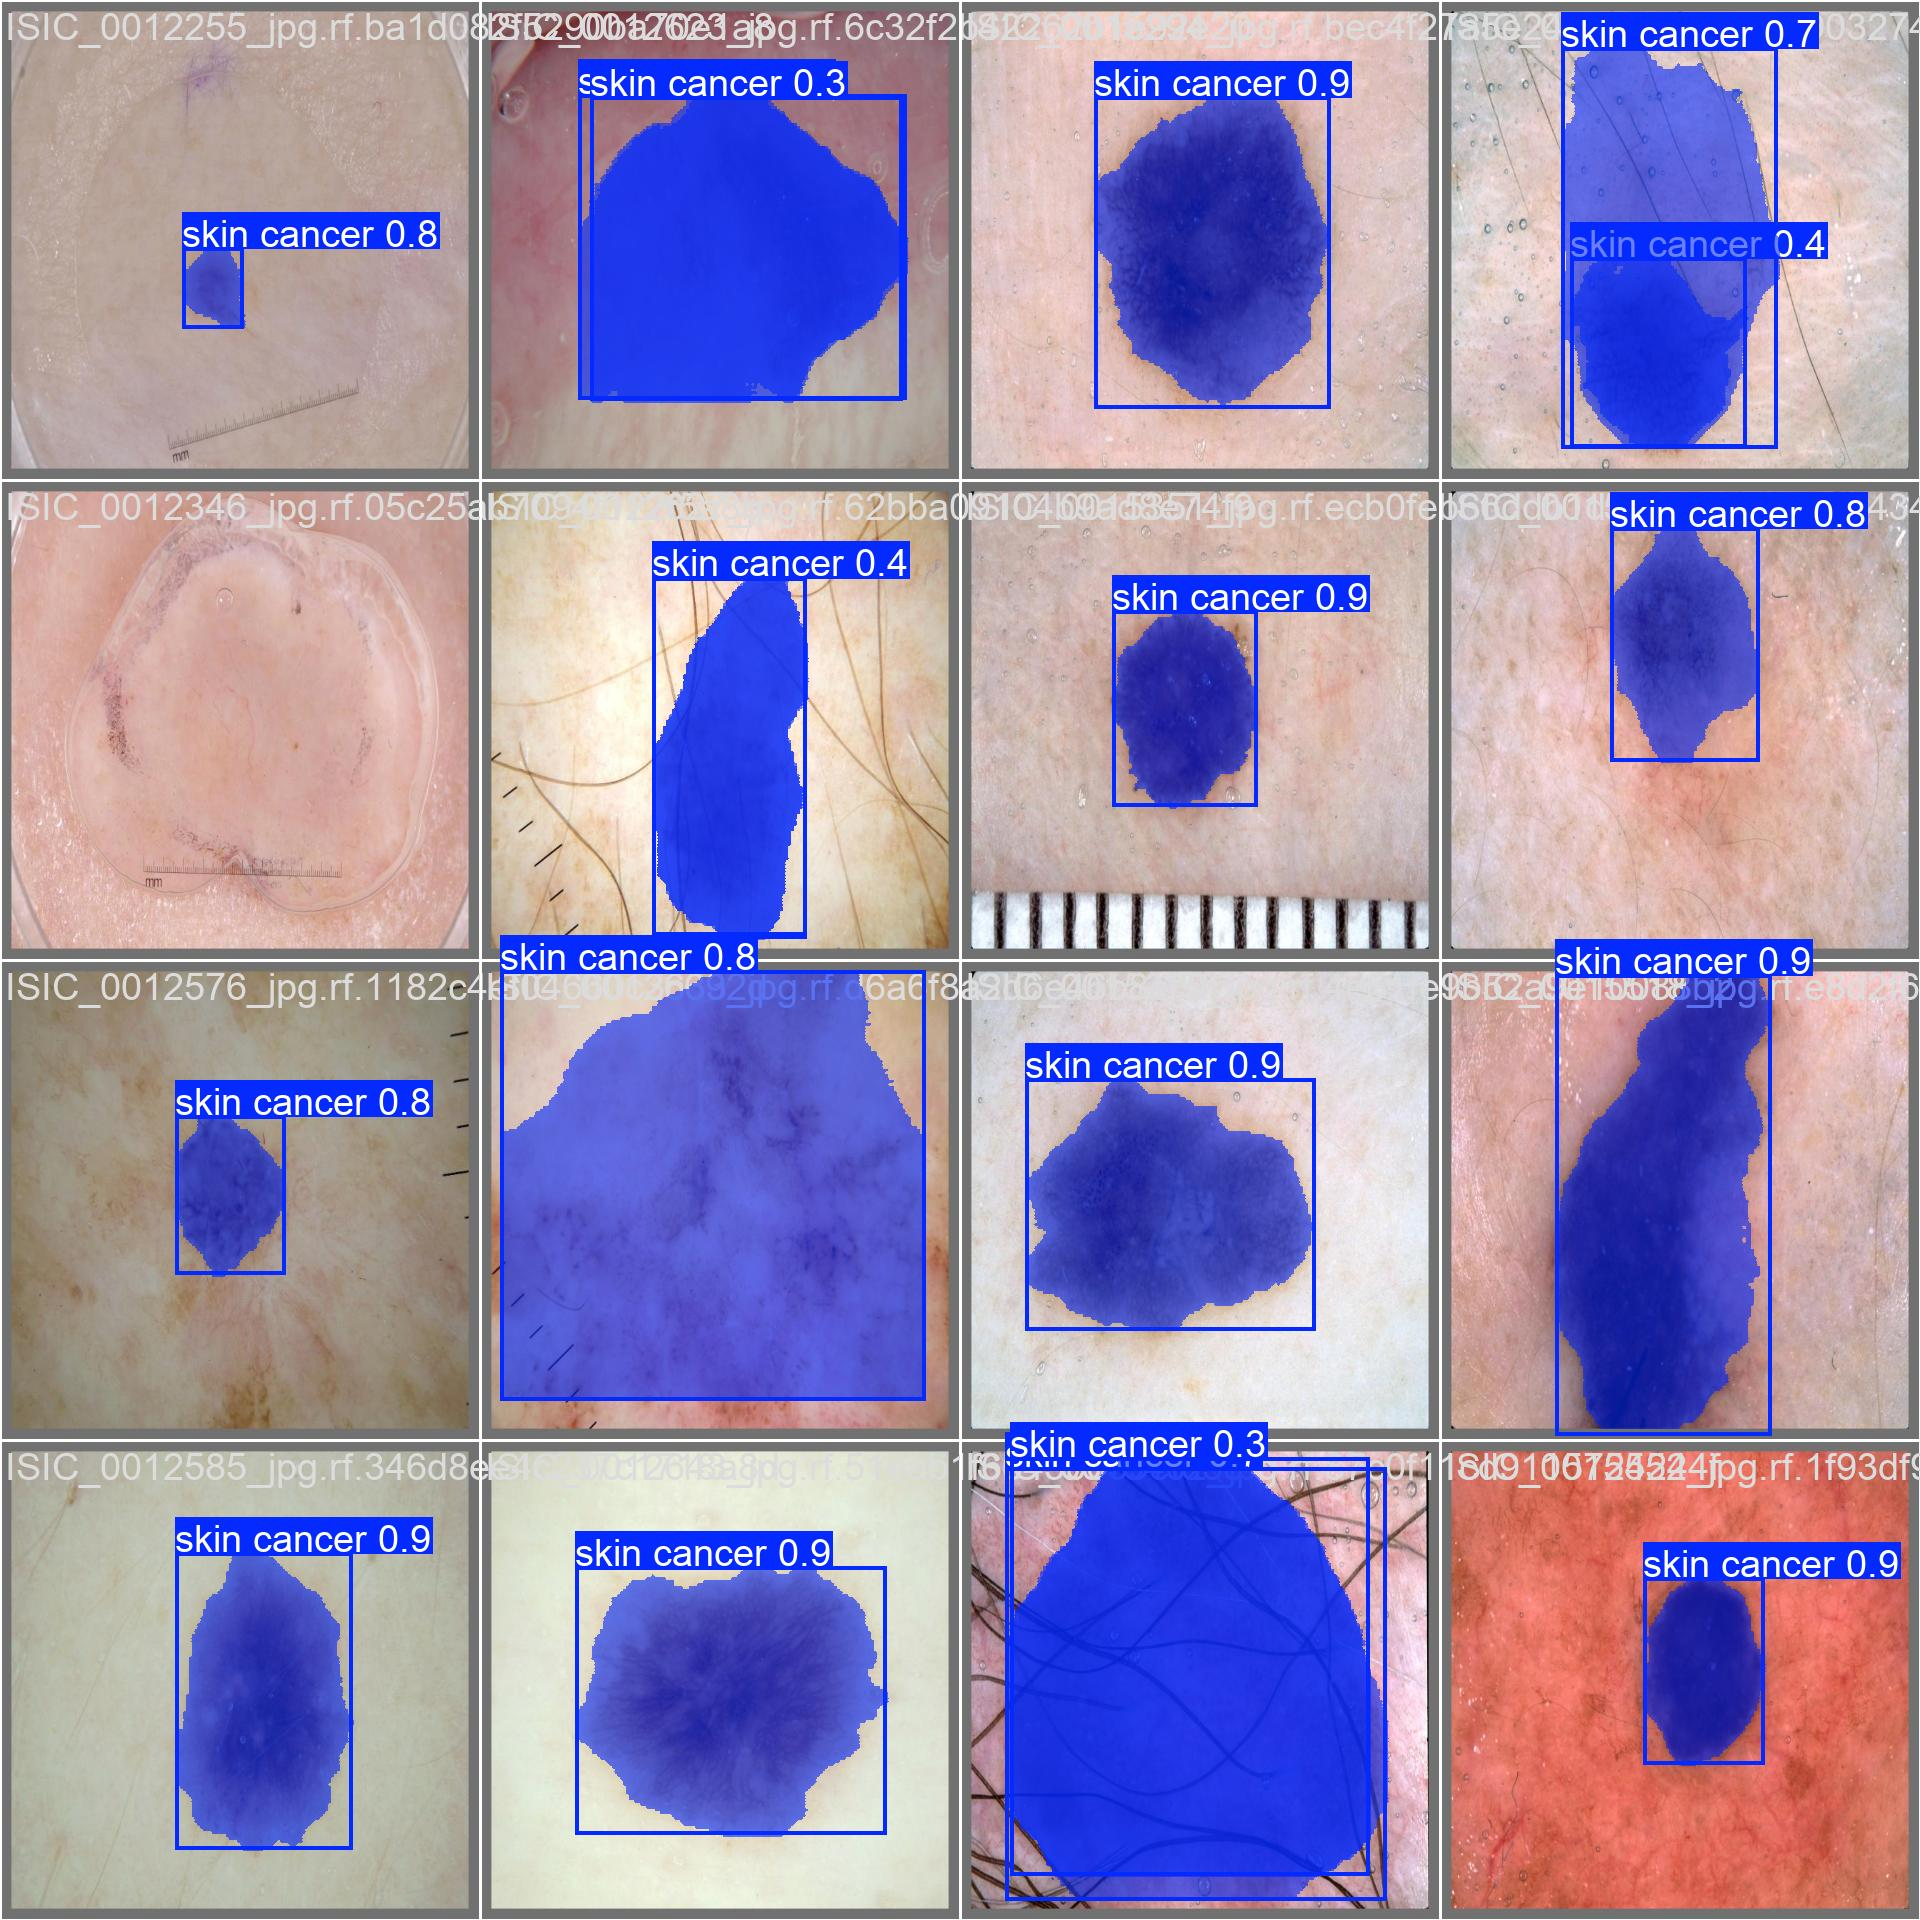
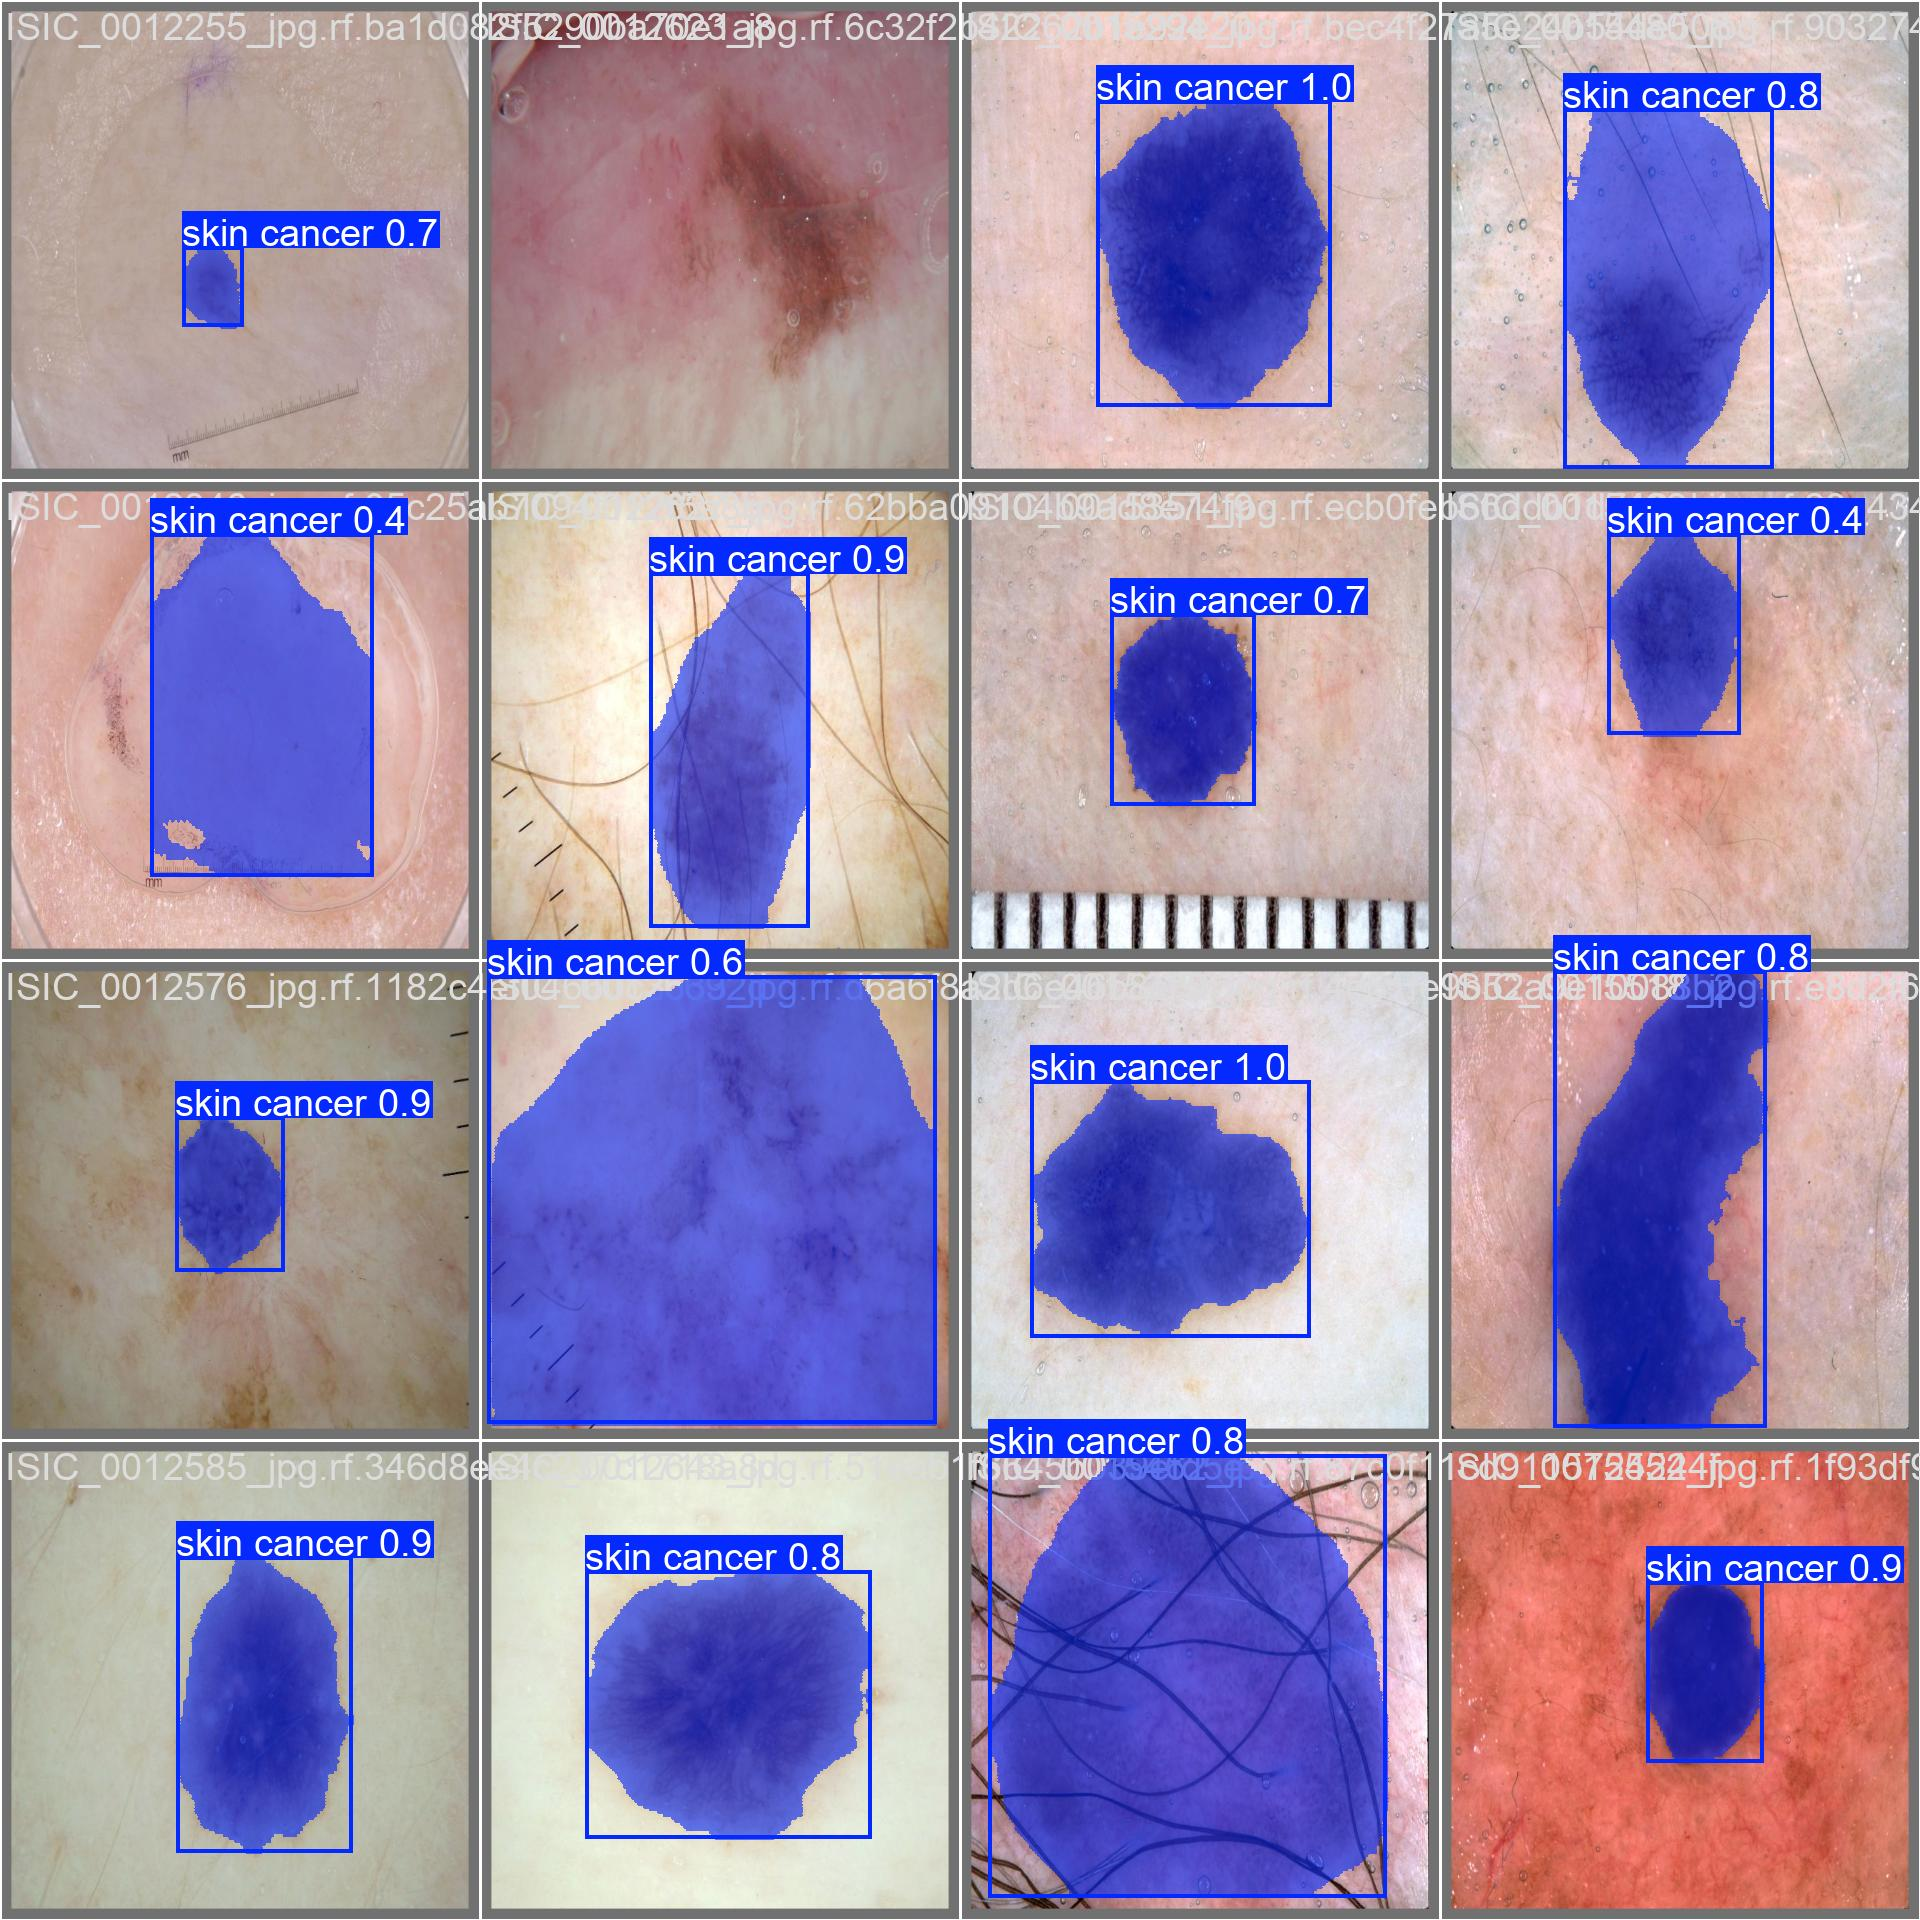
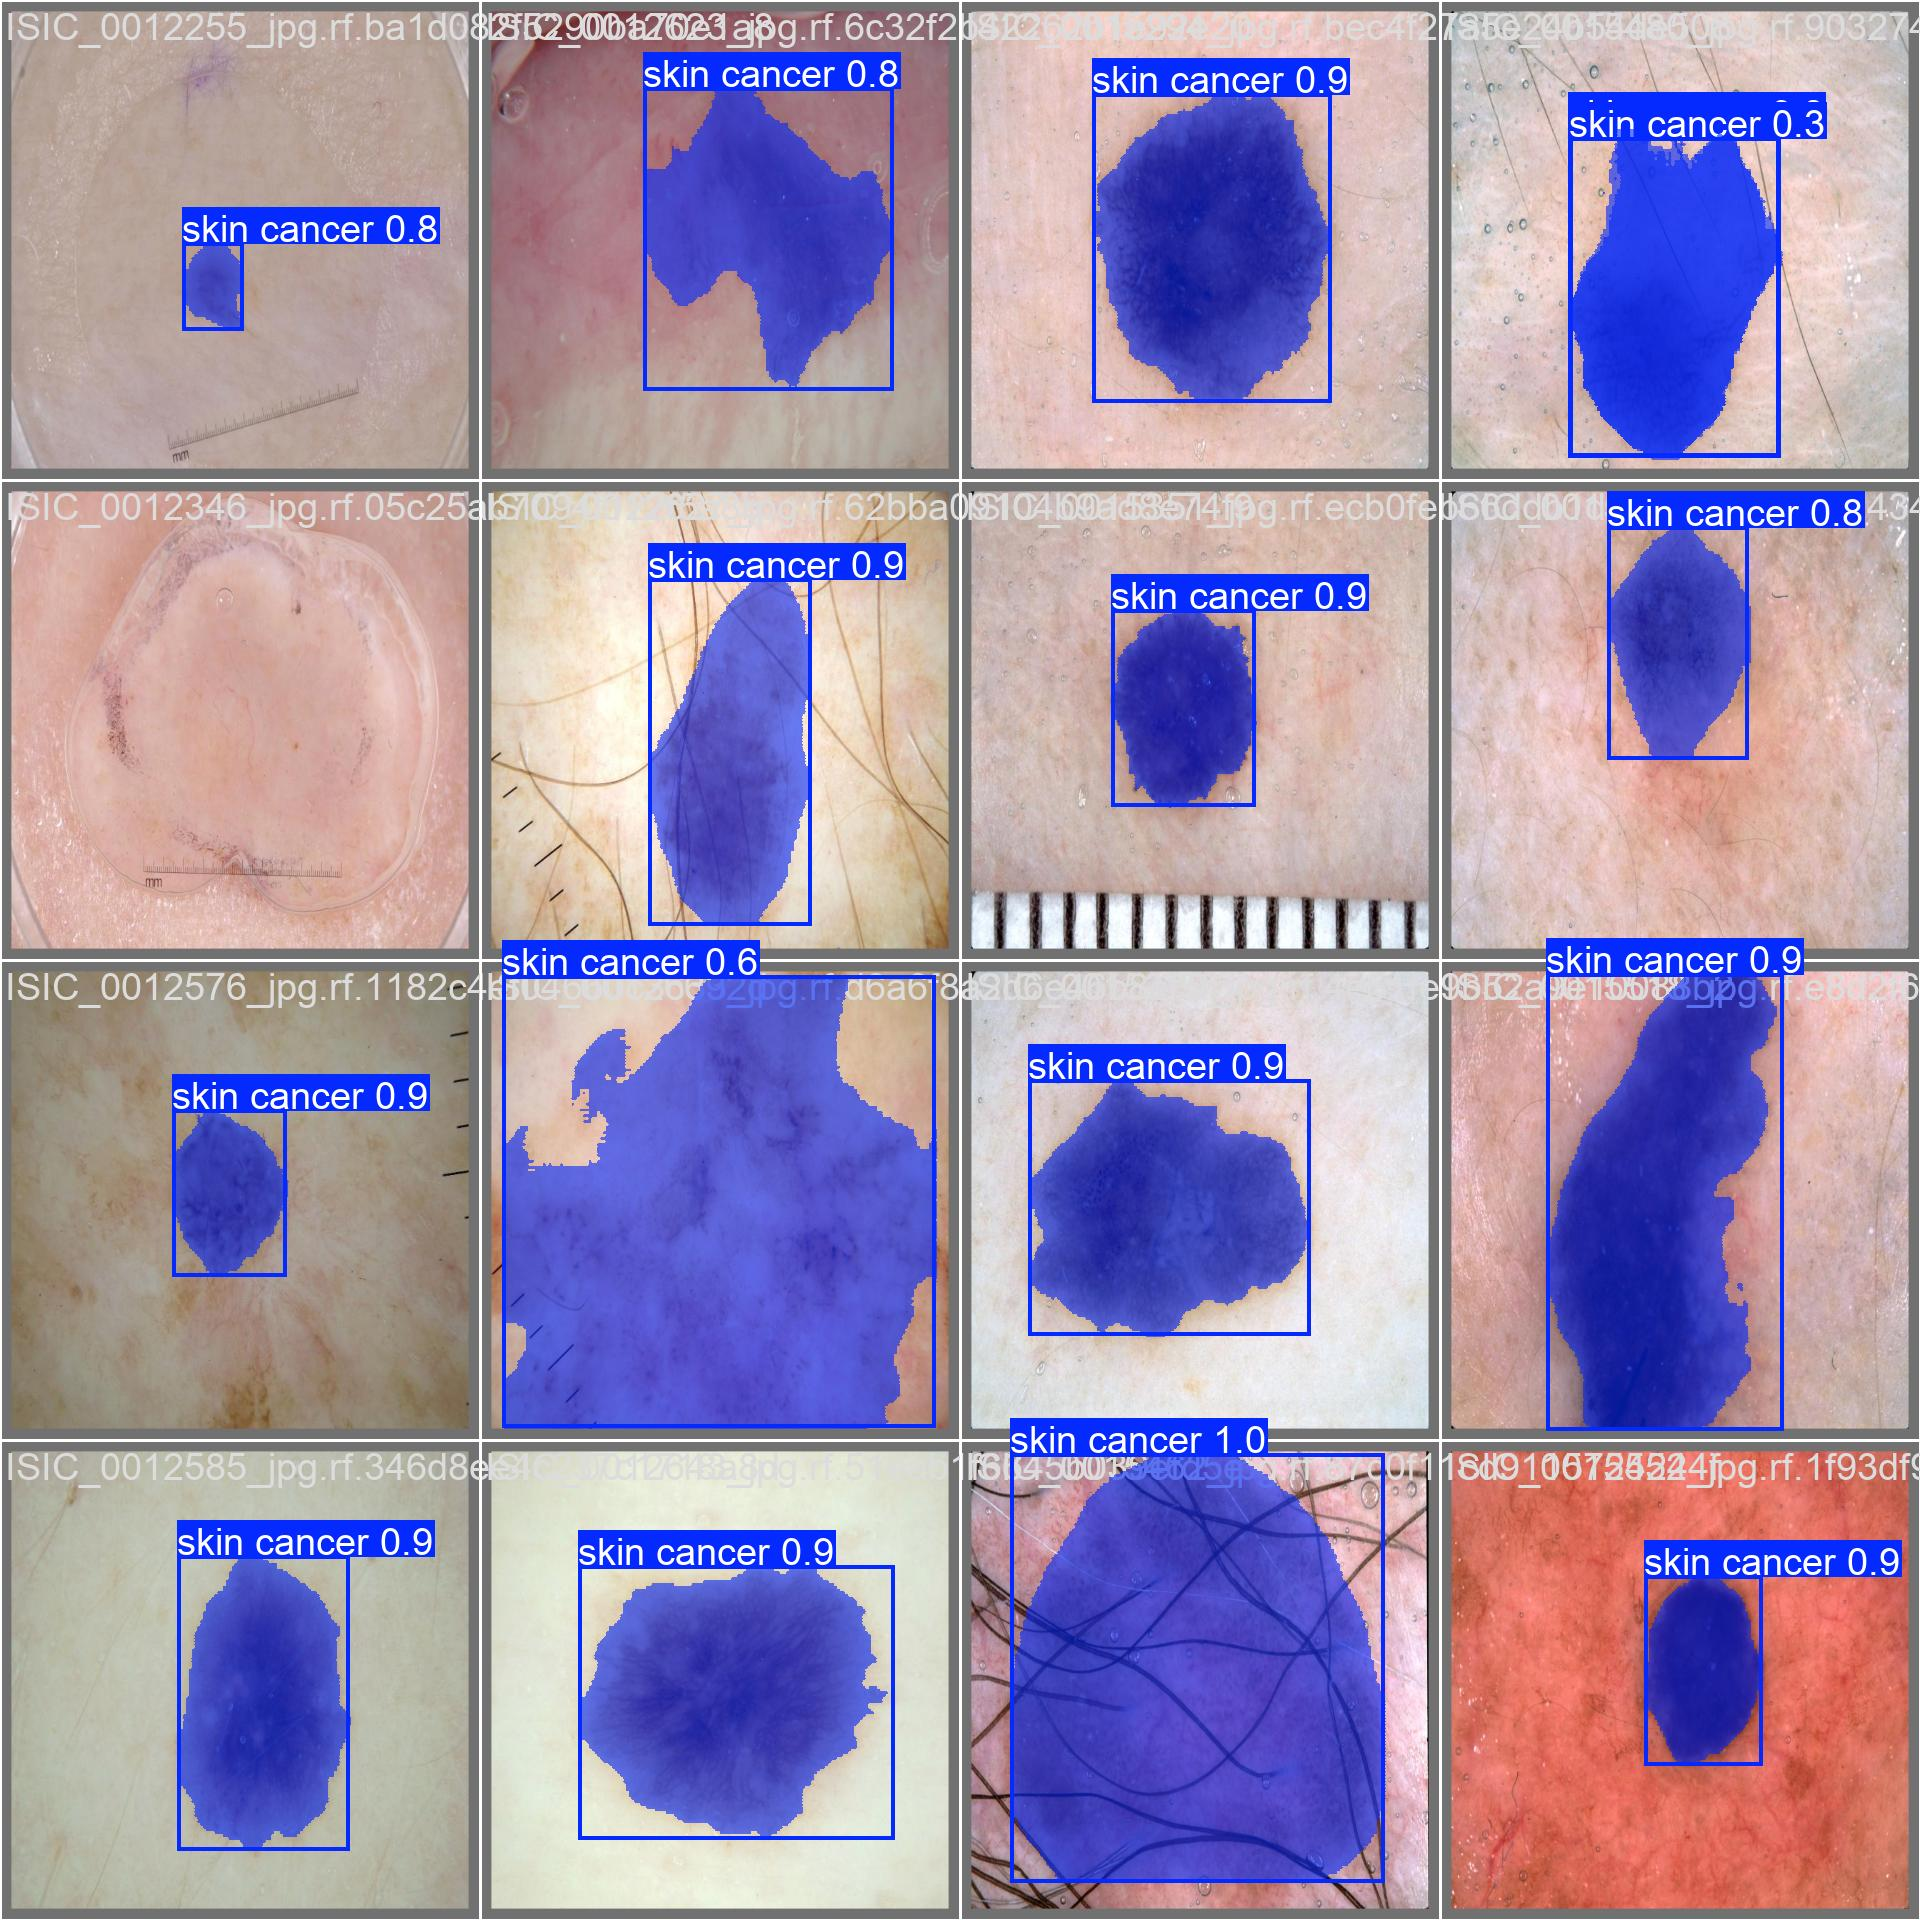
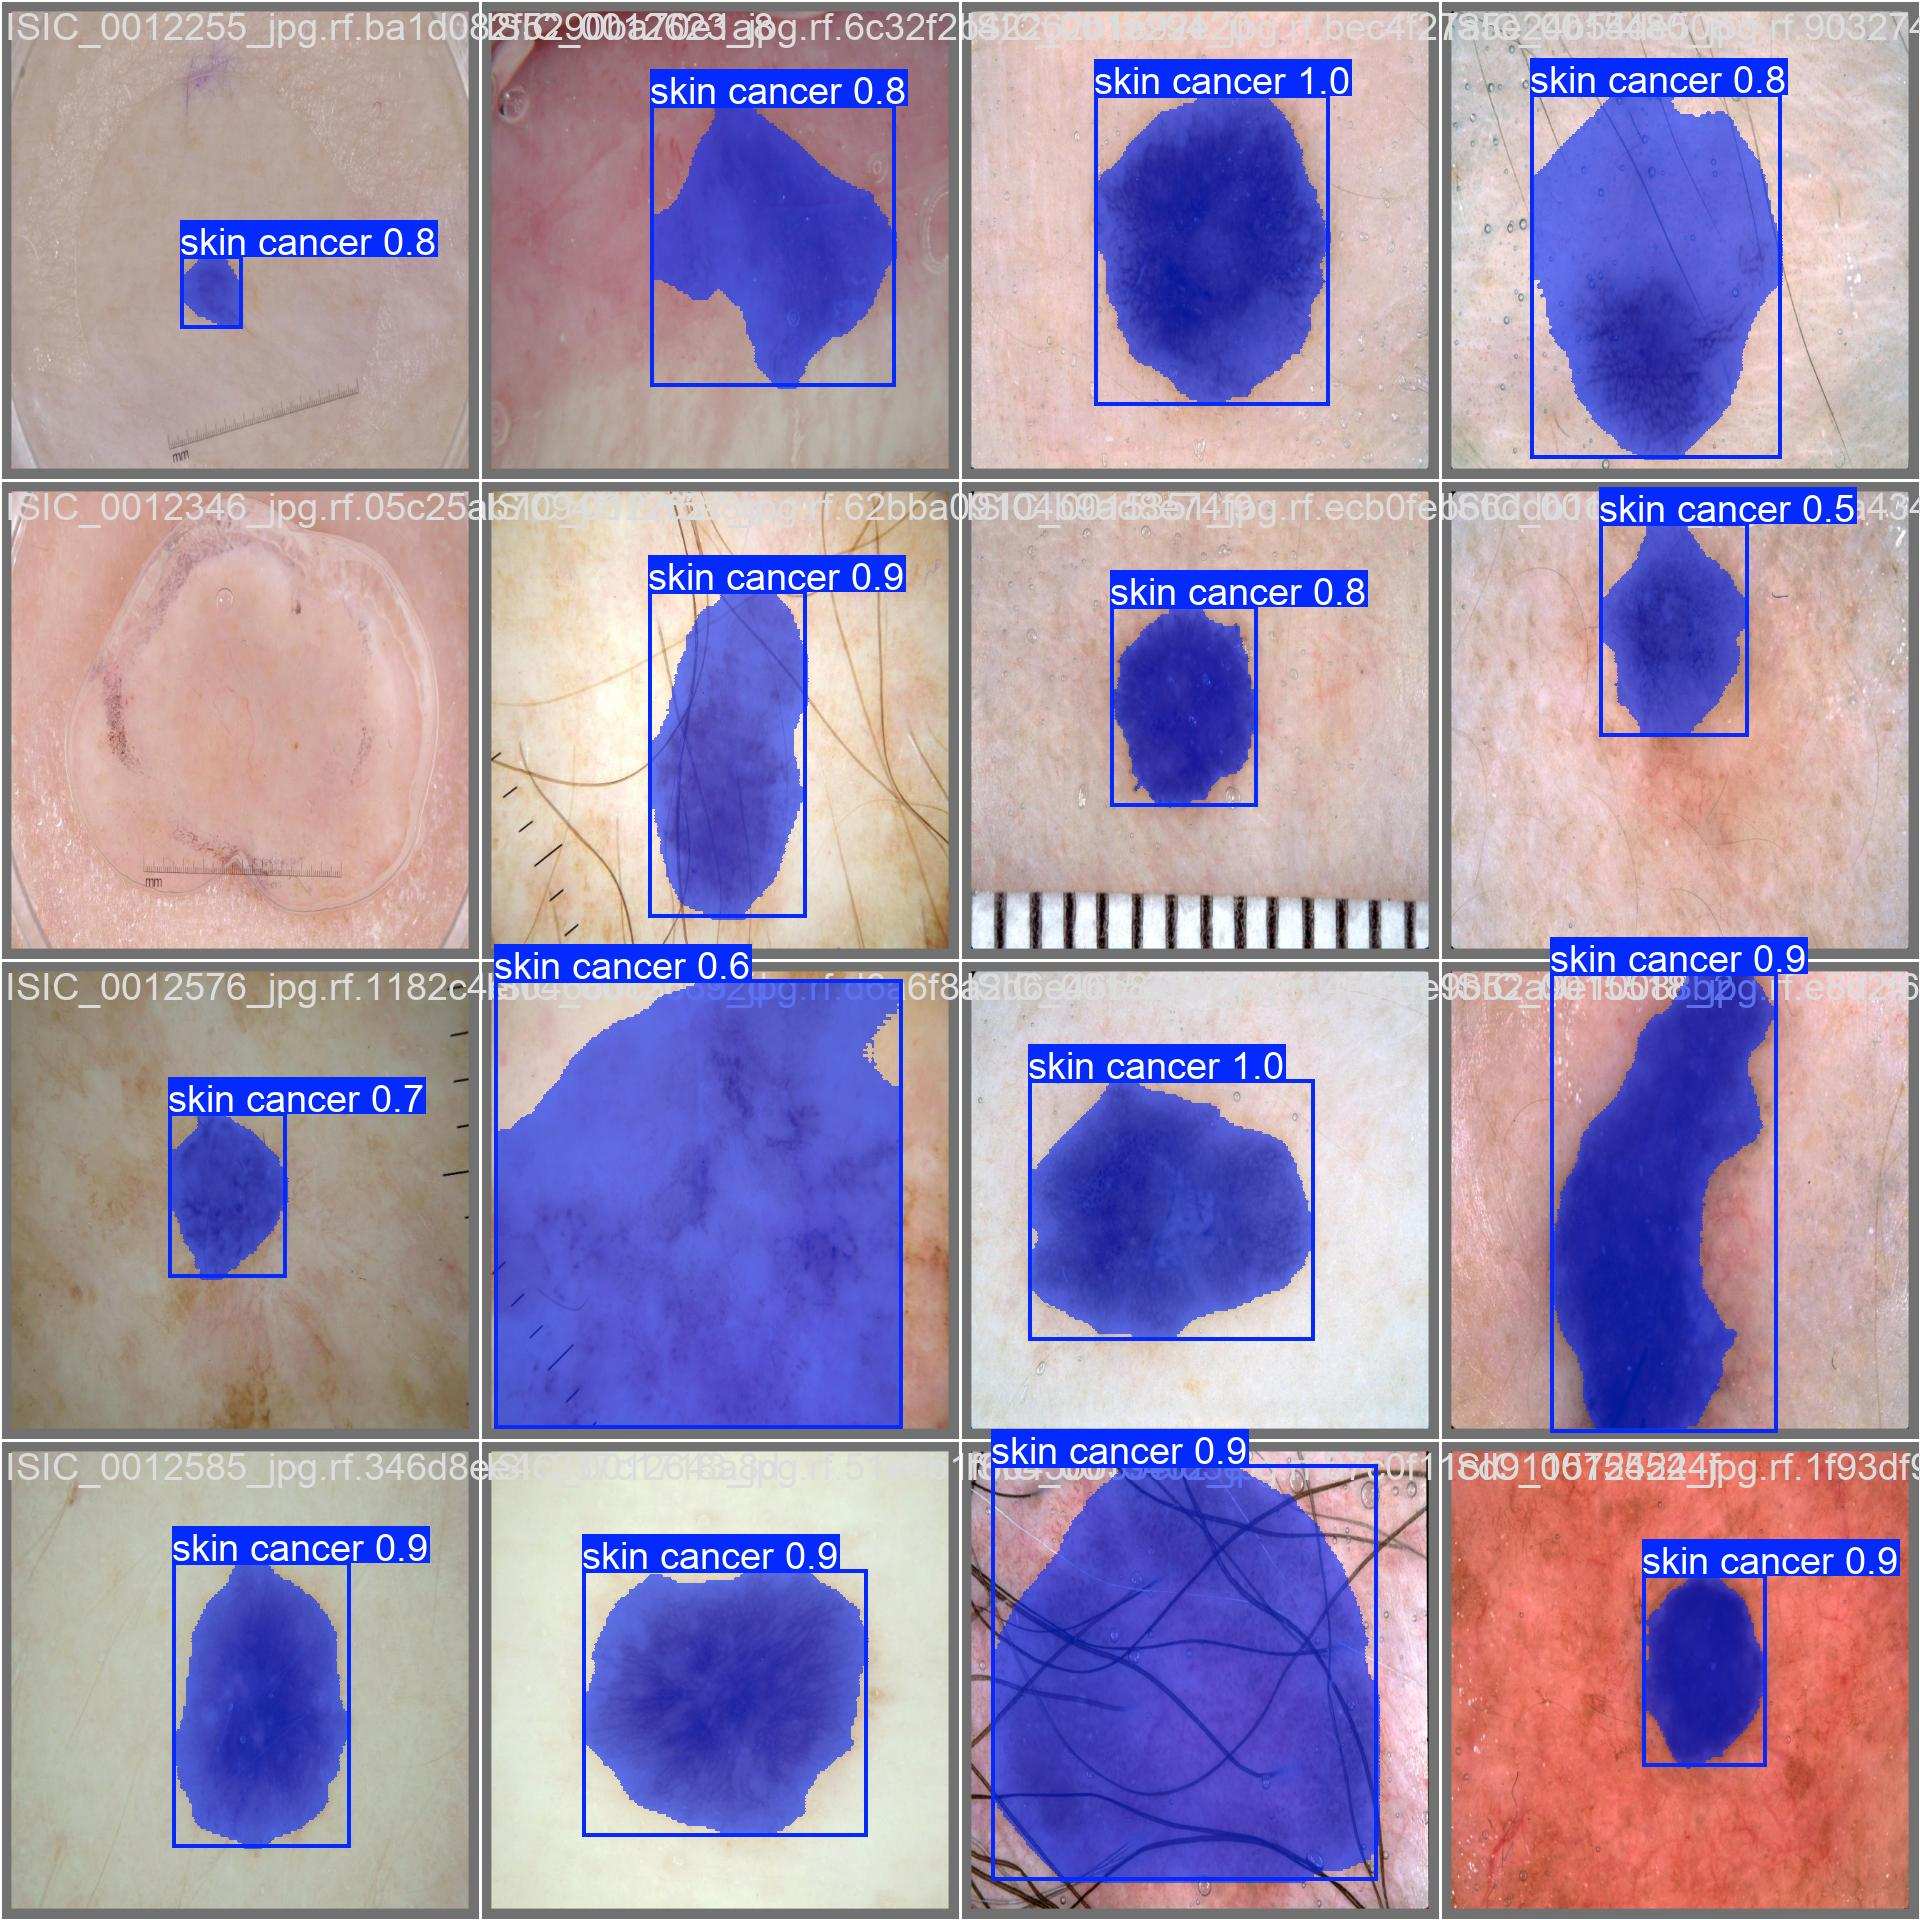

### Mask F1-Confidence Curve


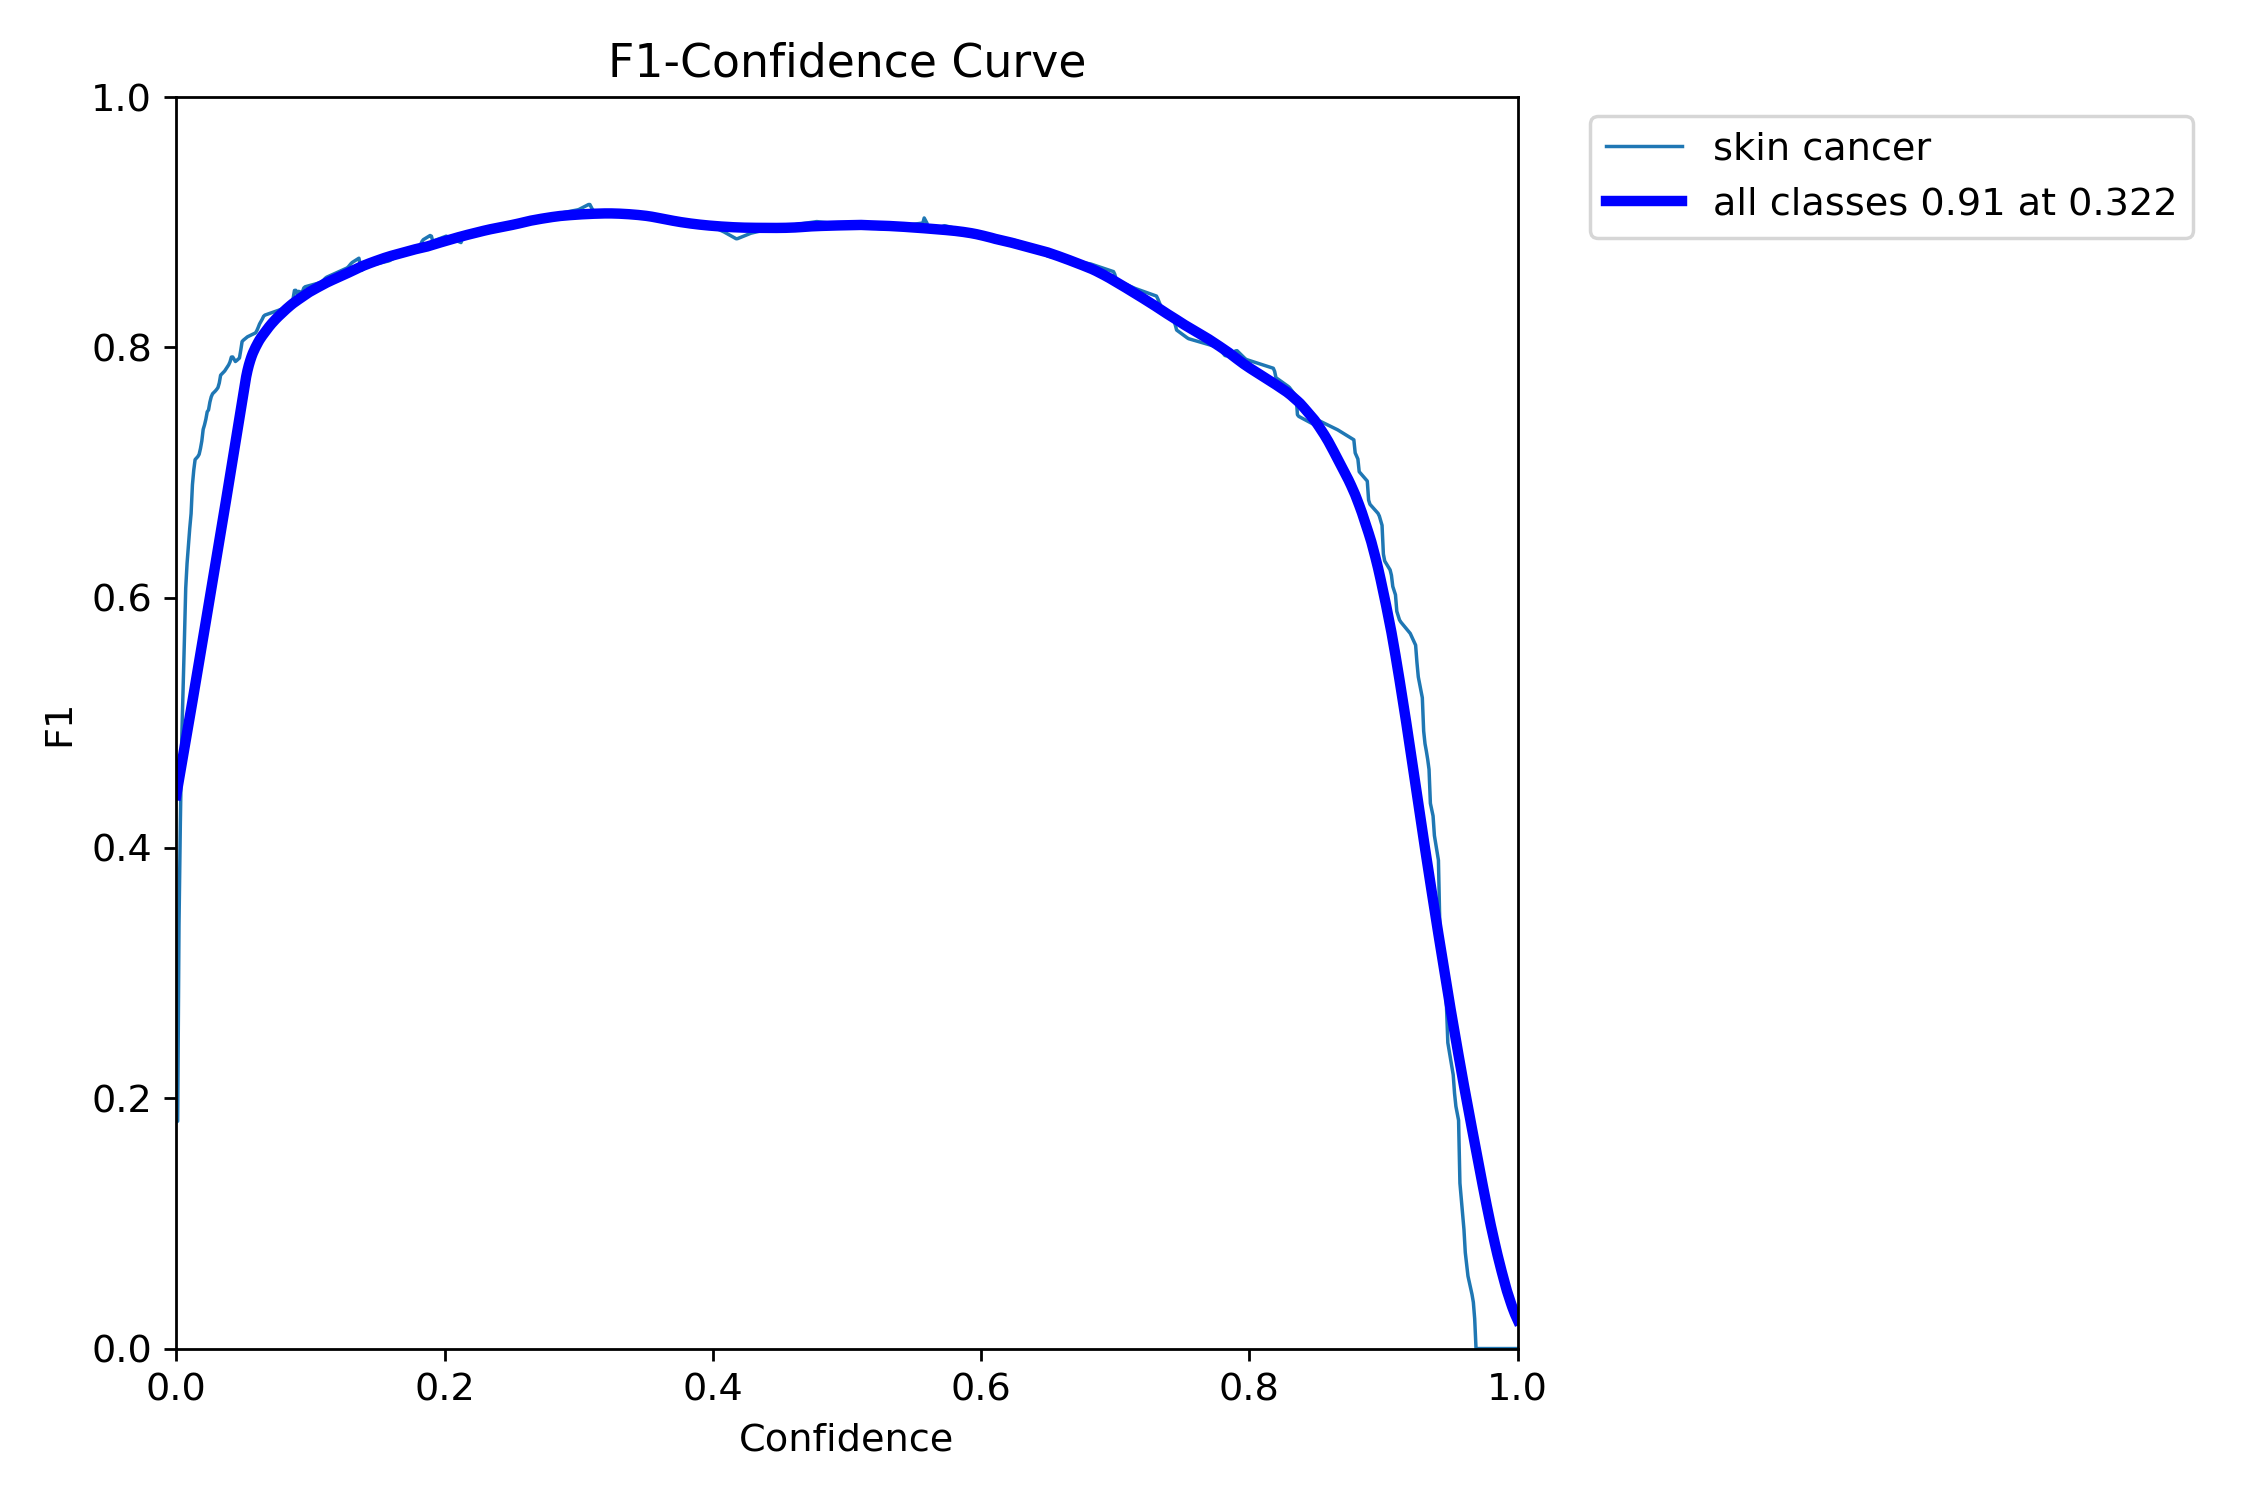
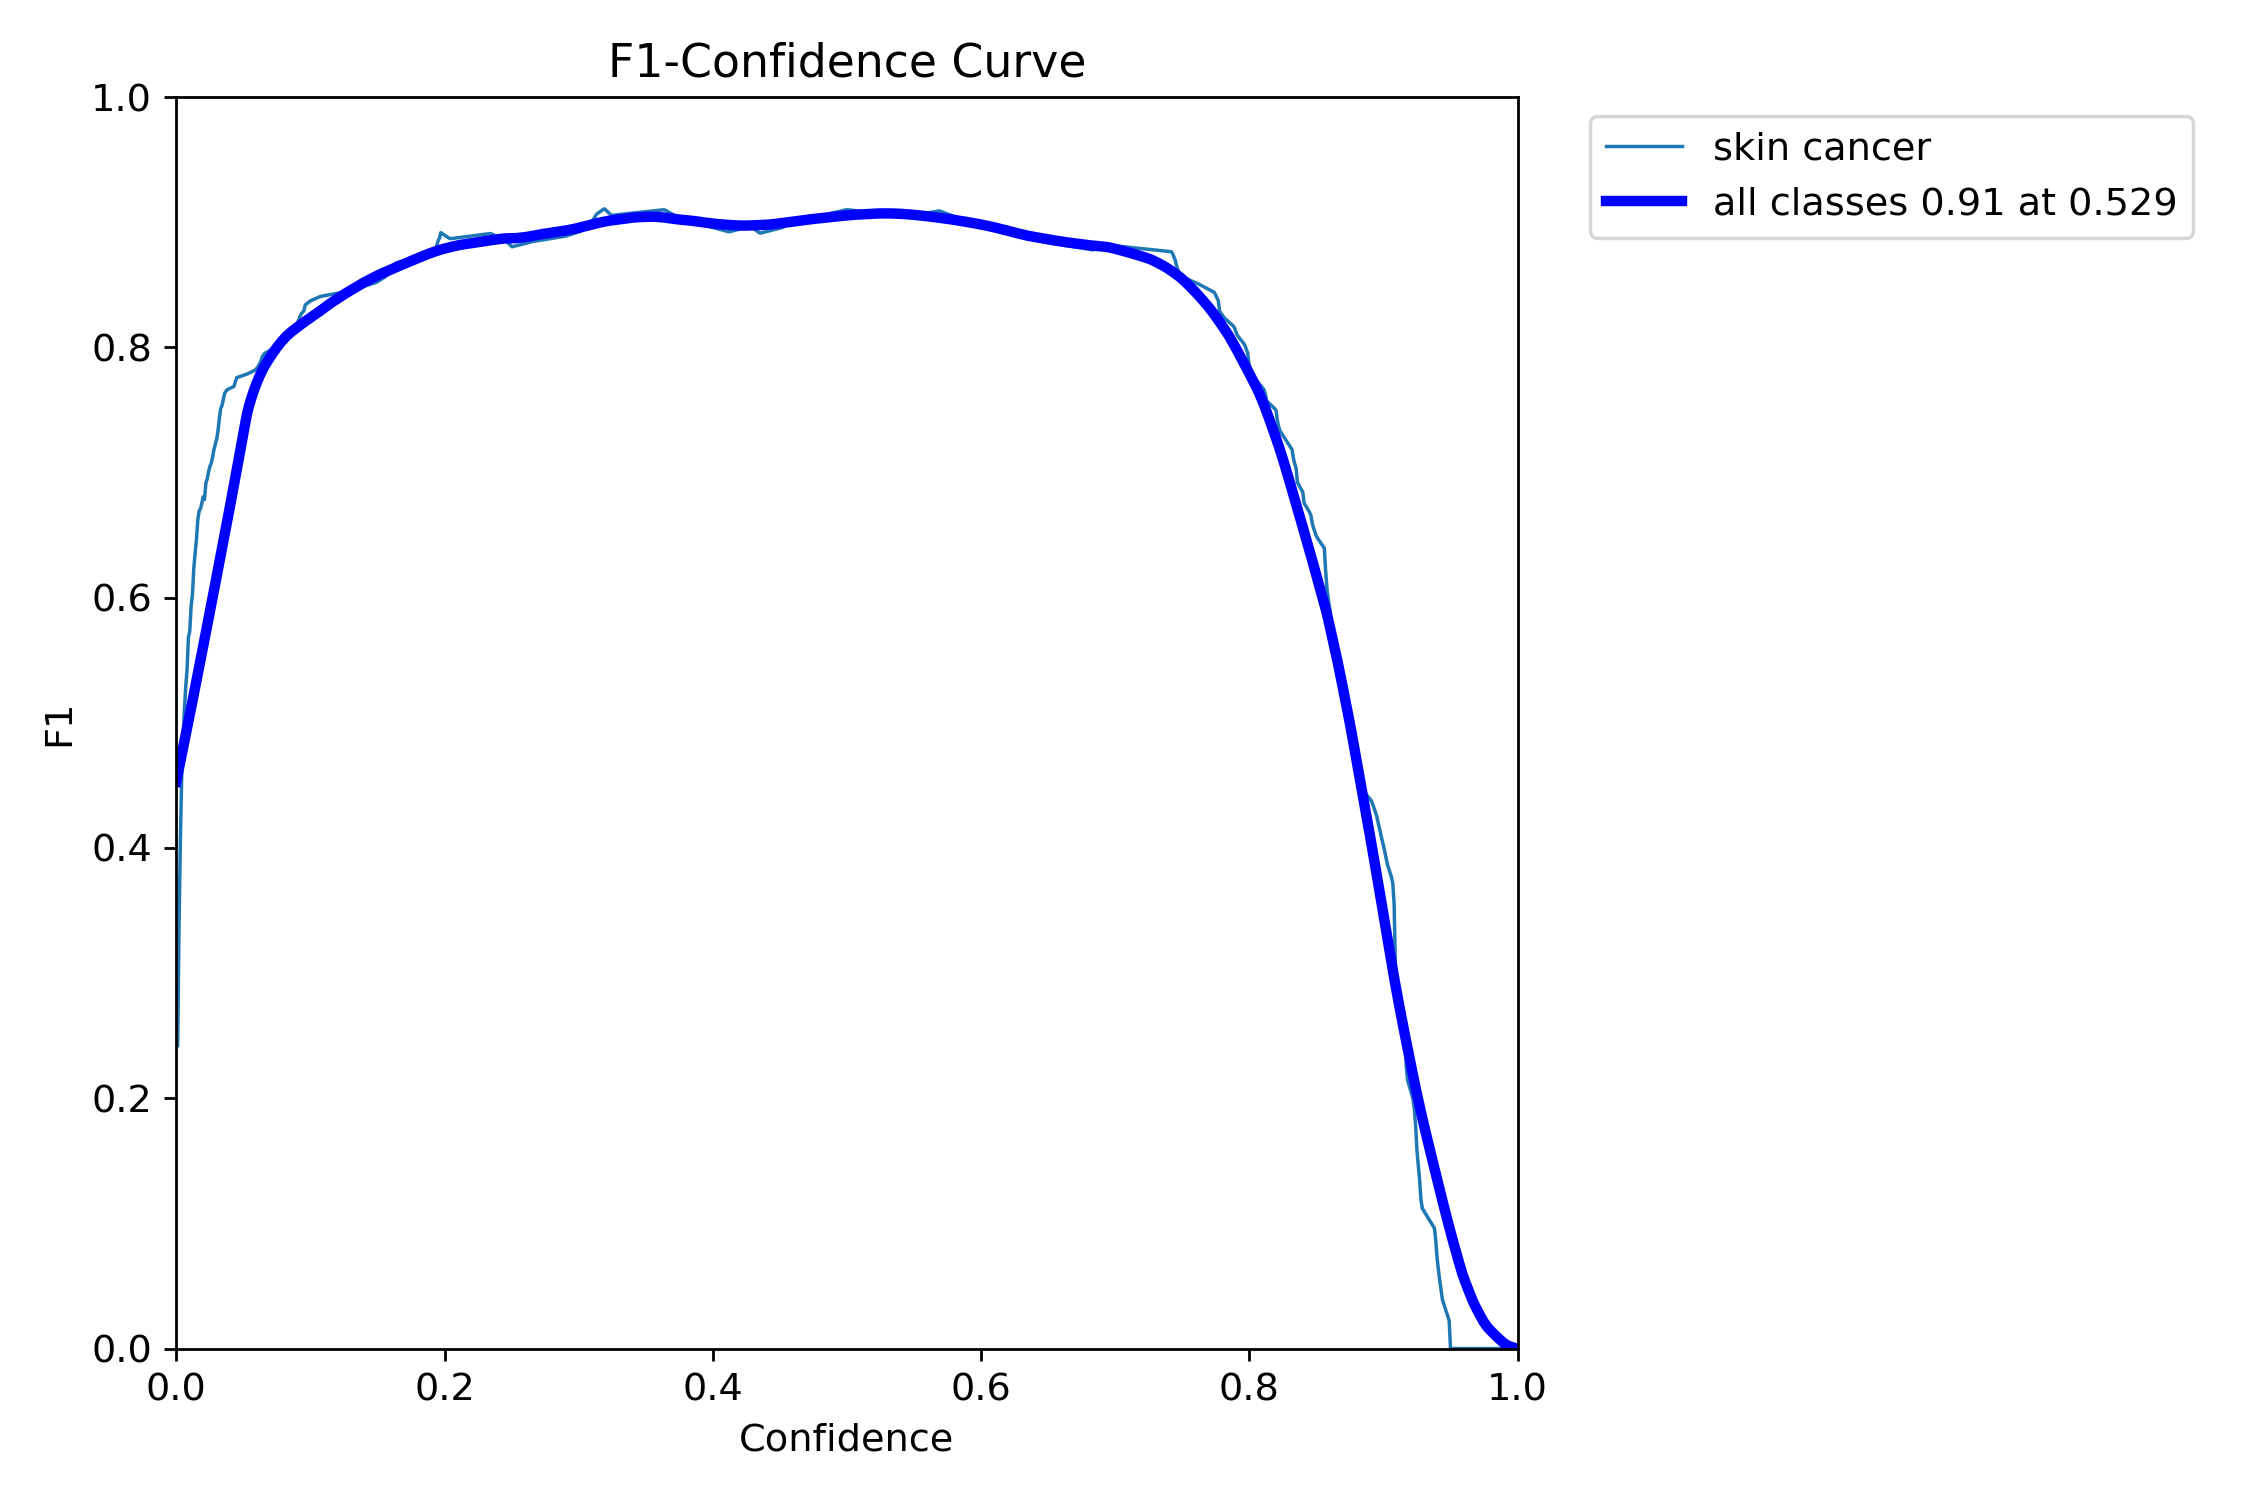
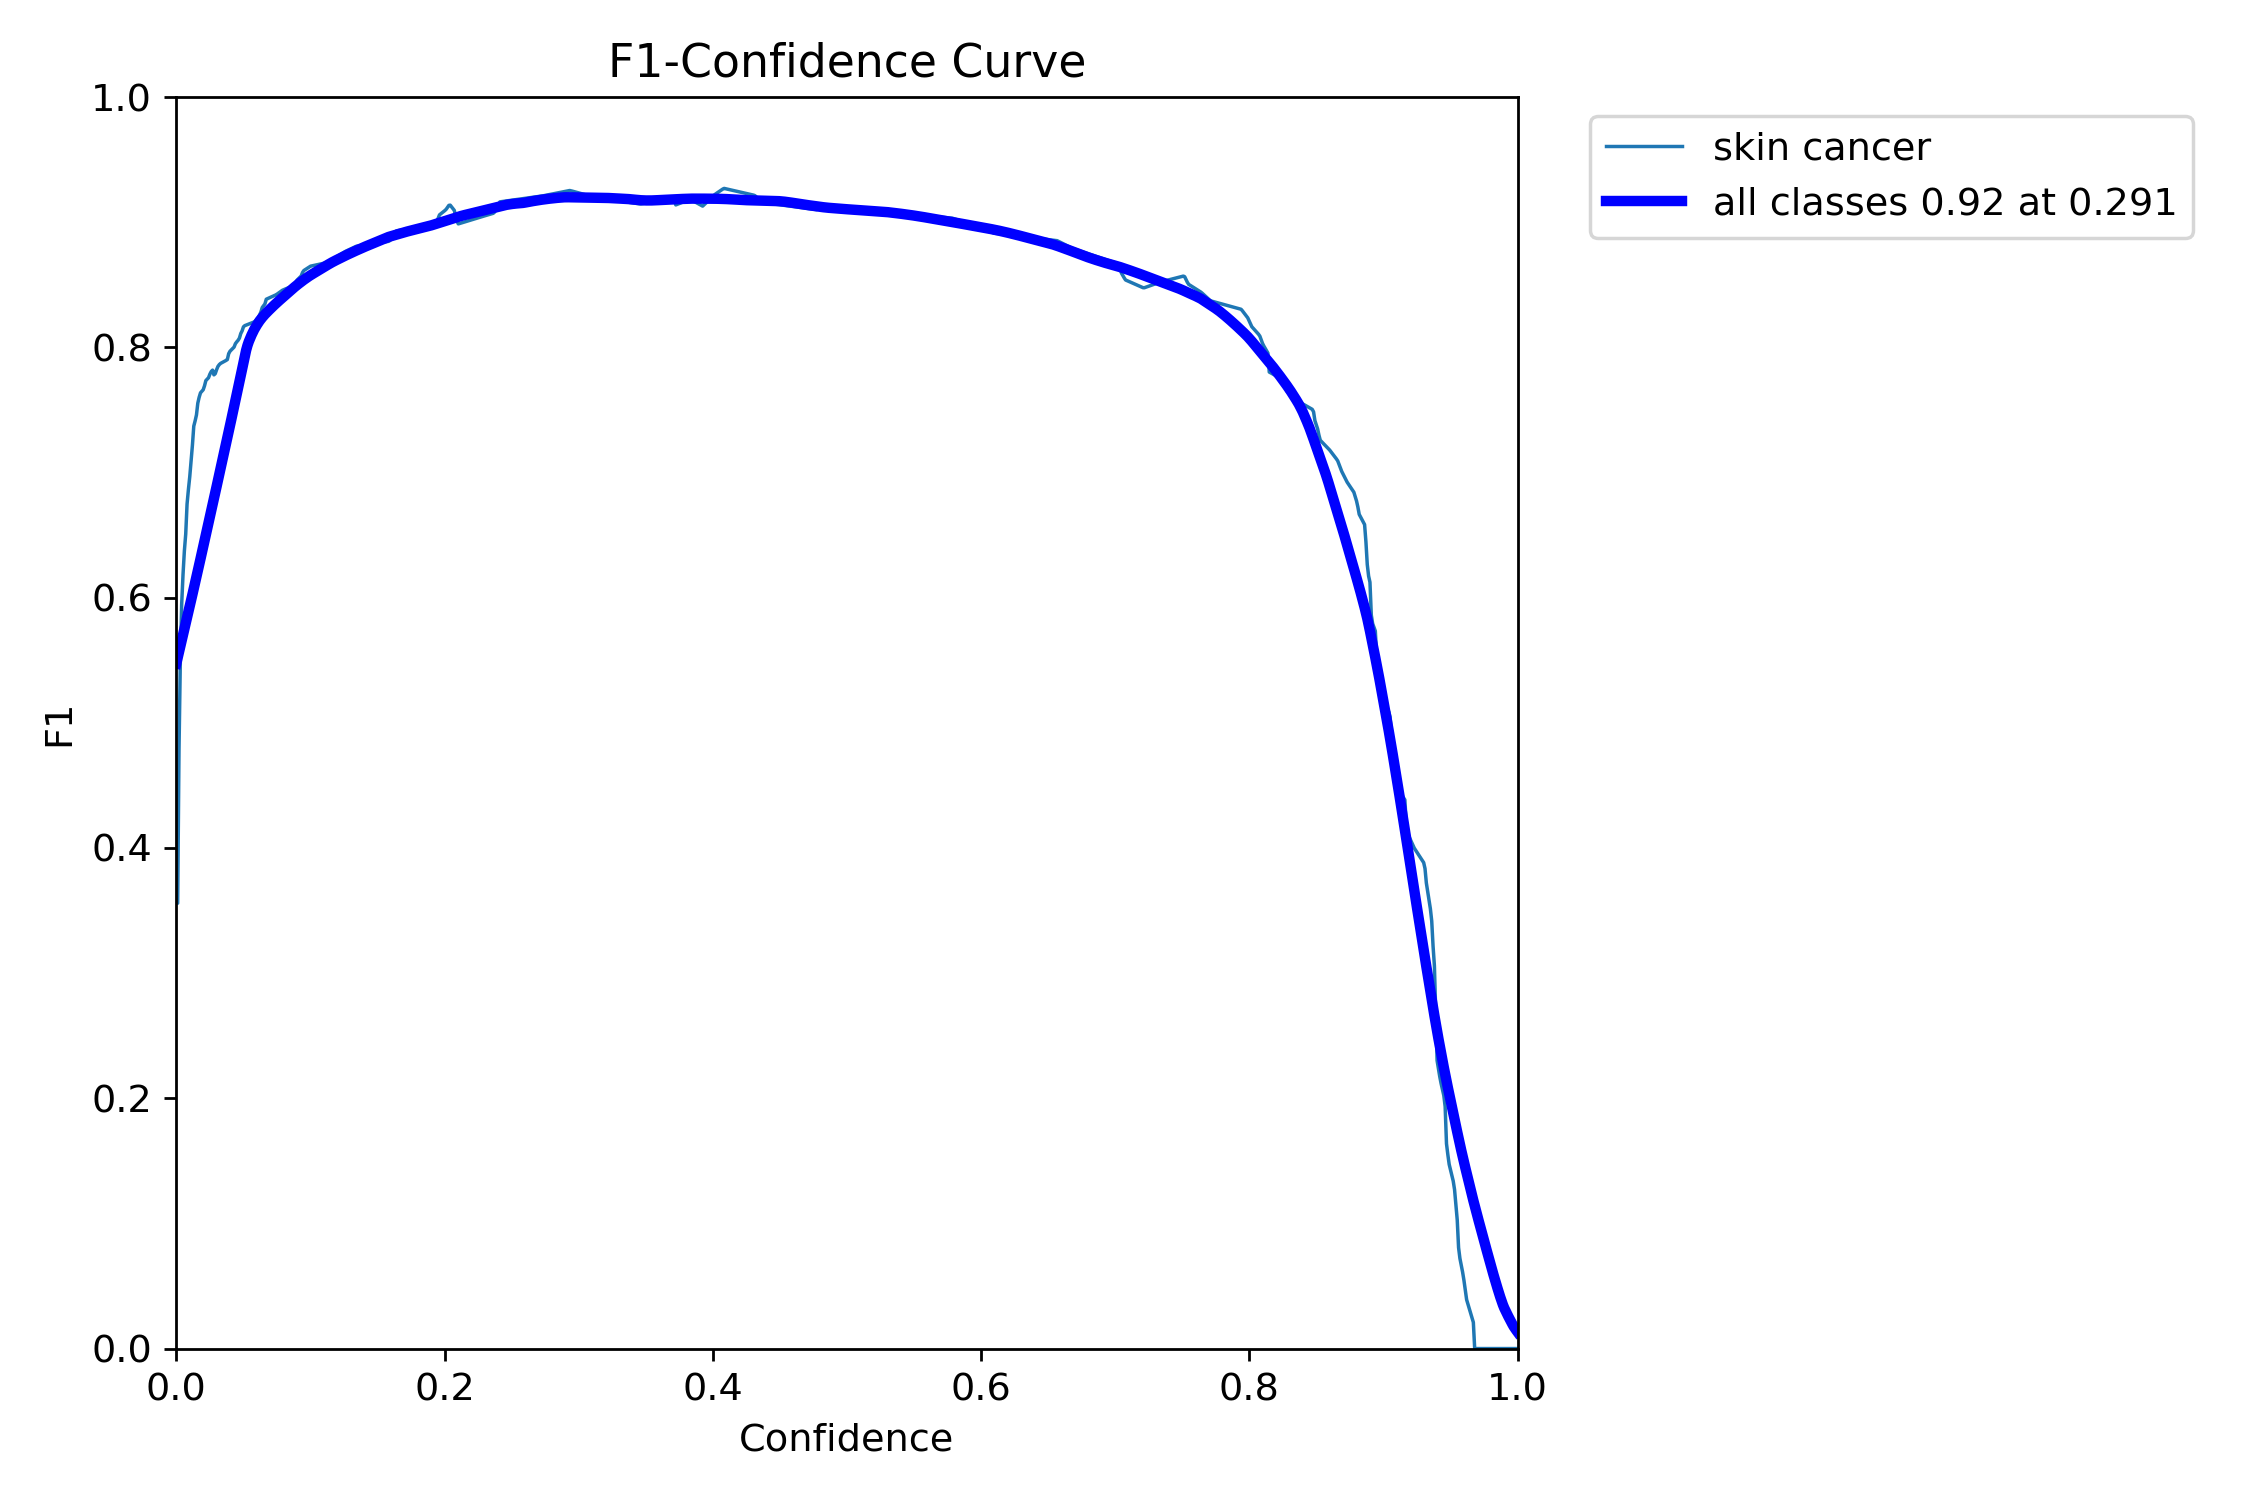
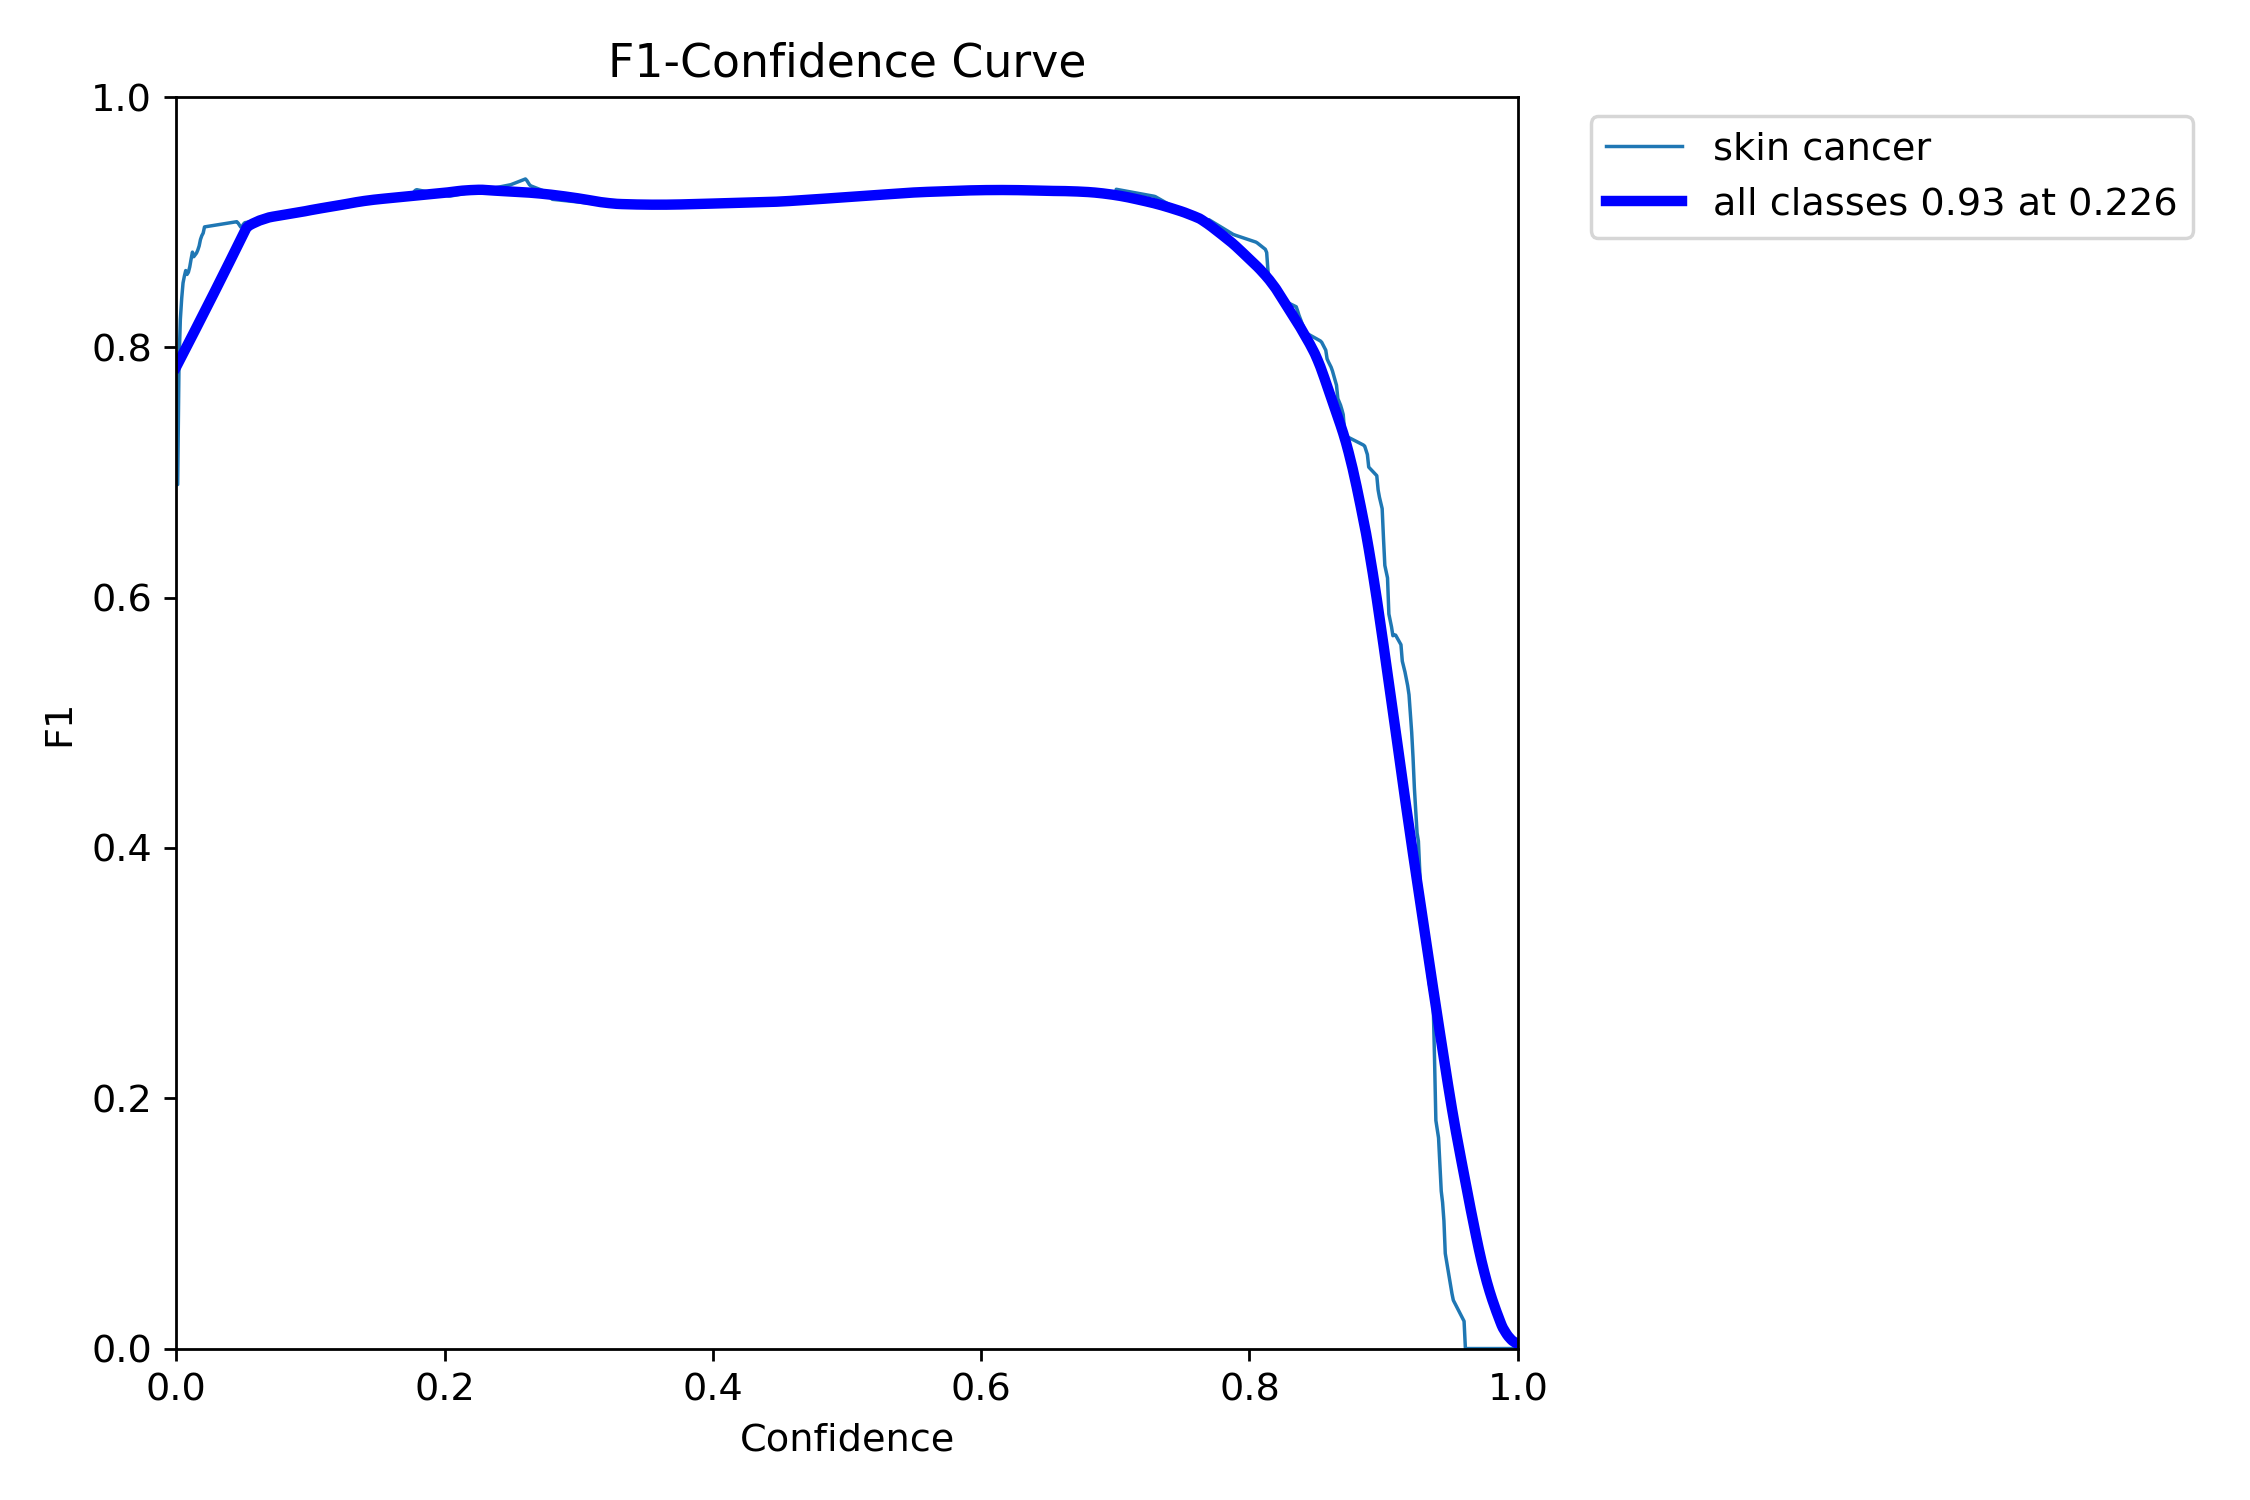
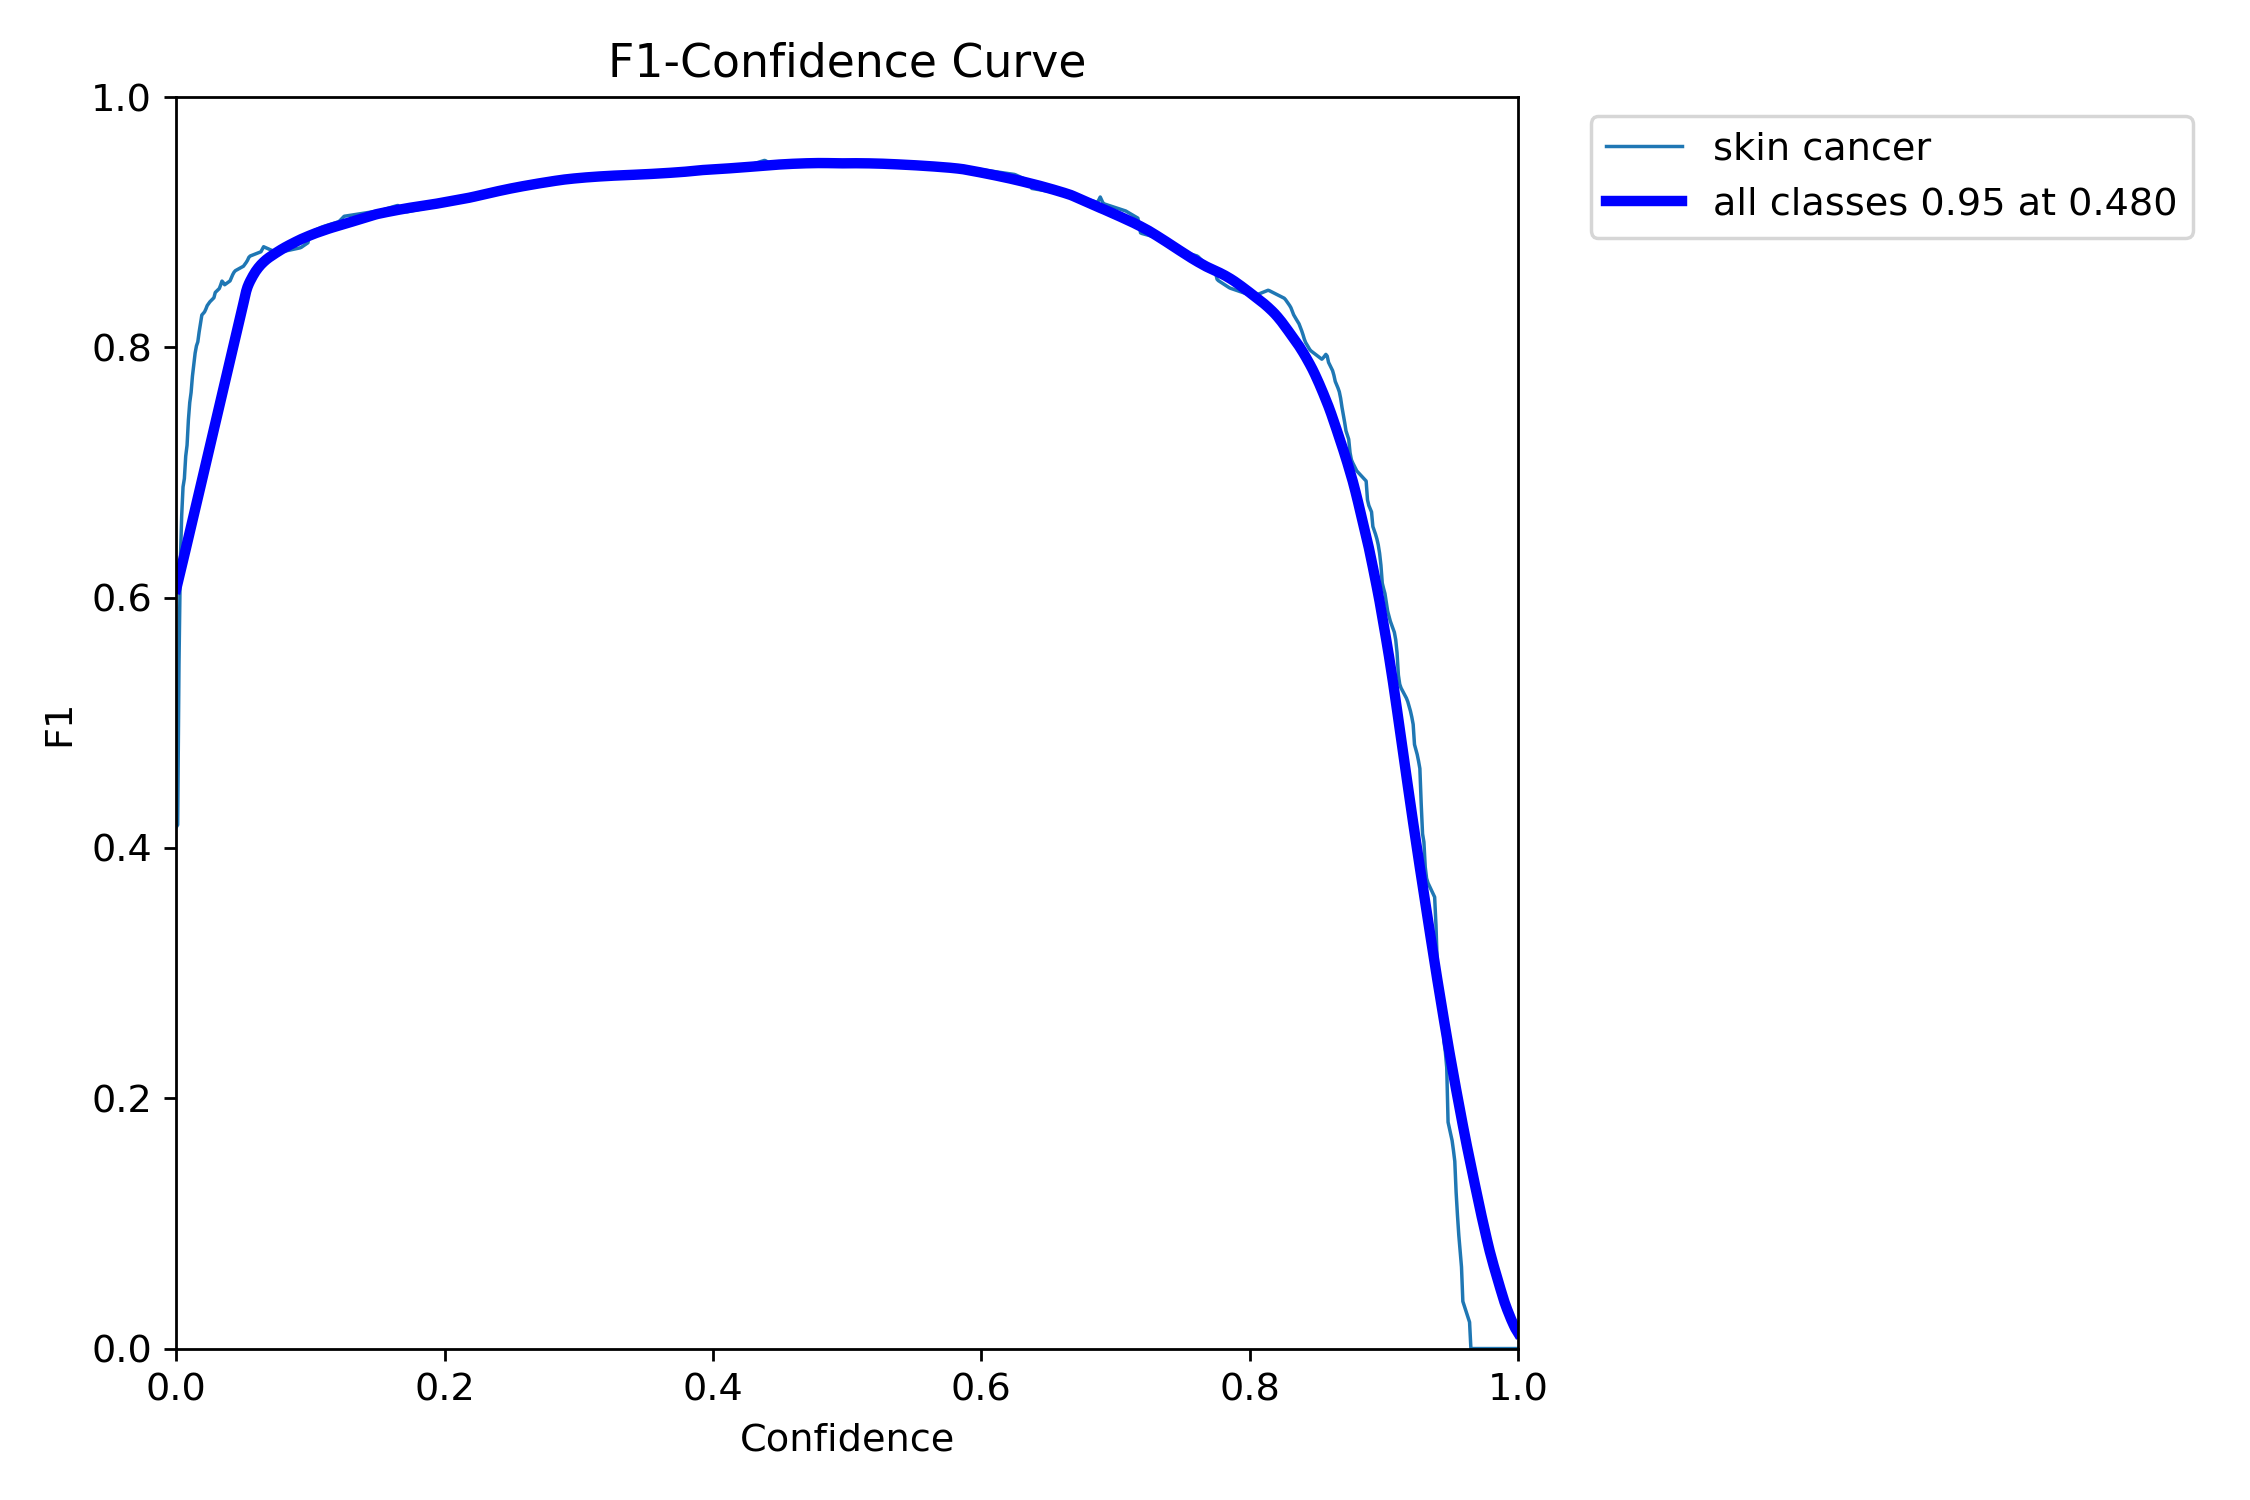

### Results overview


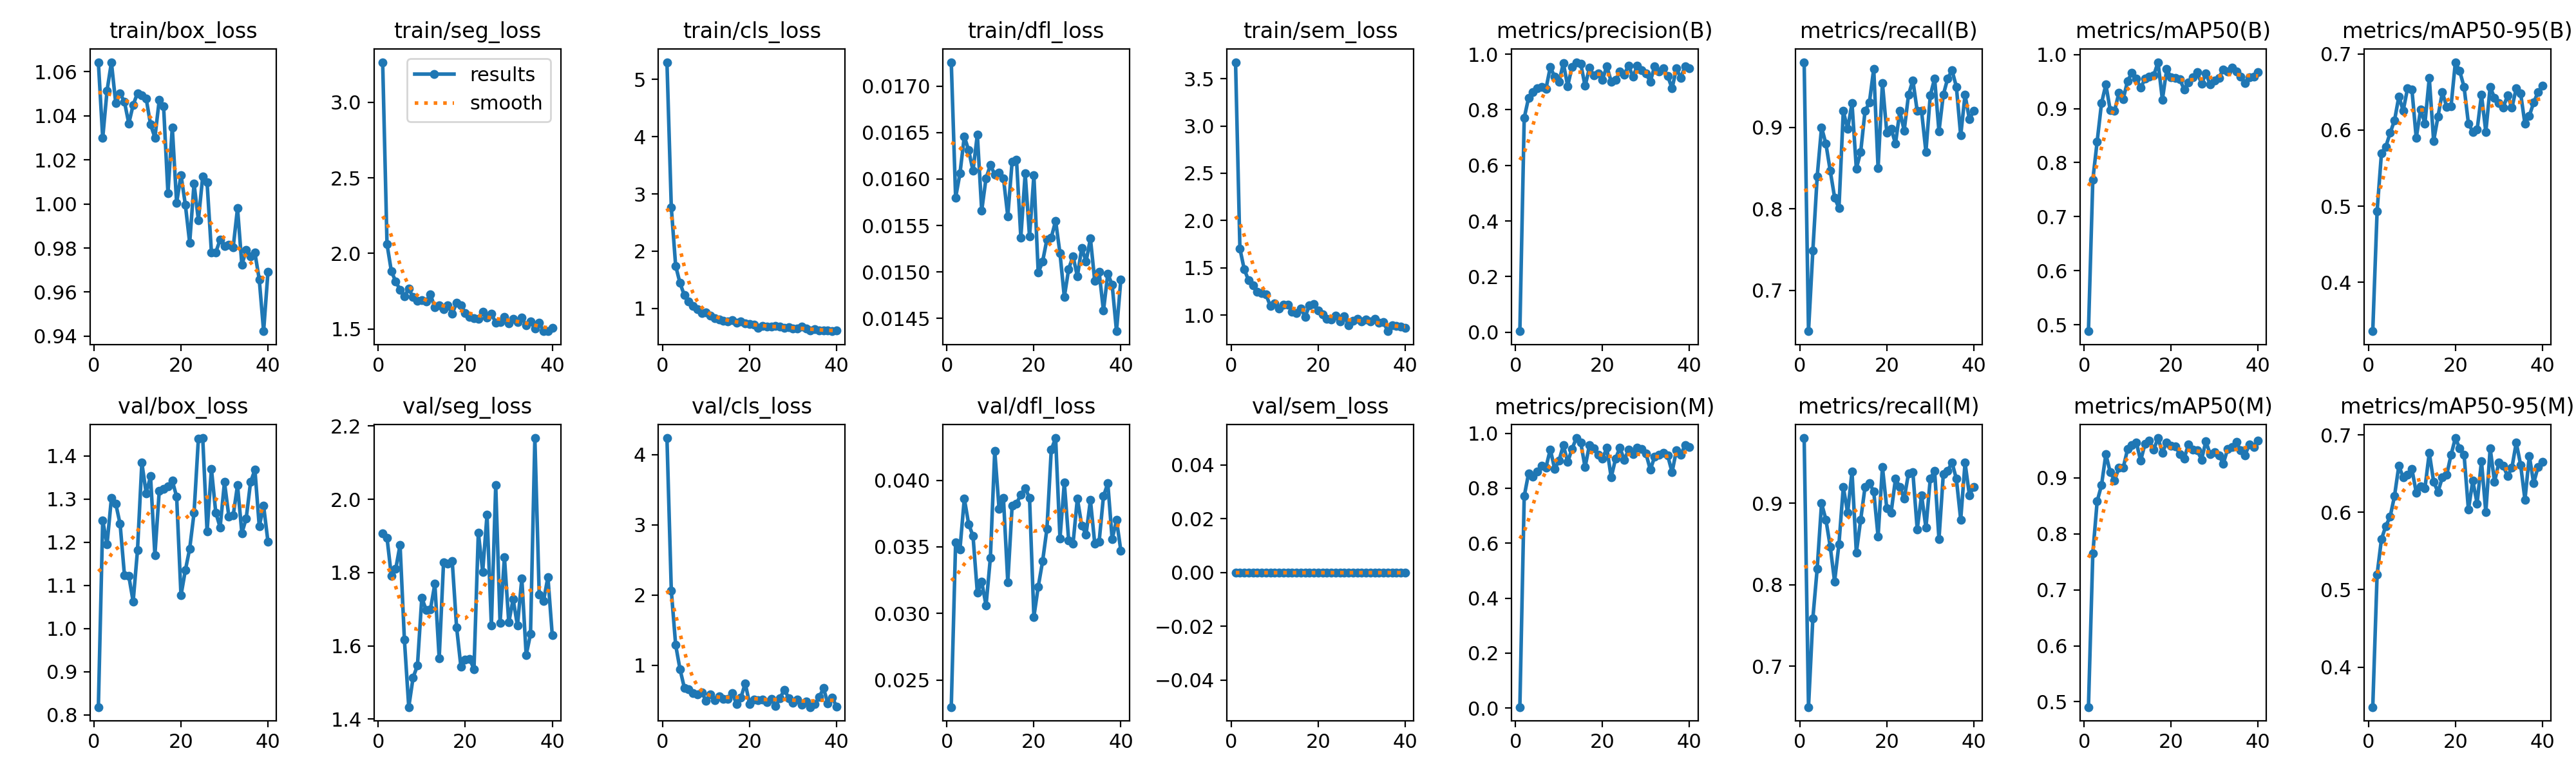
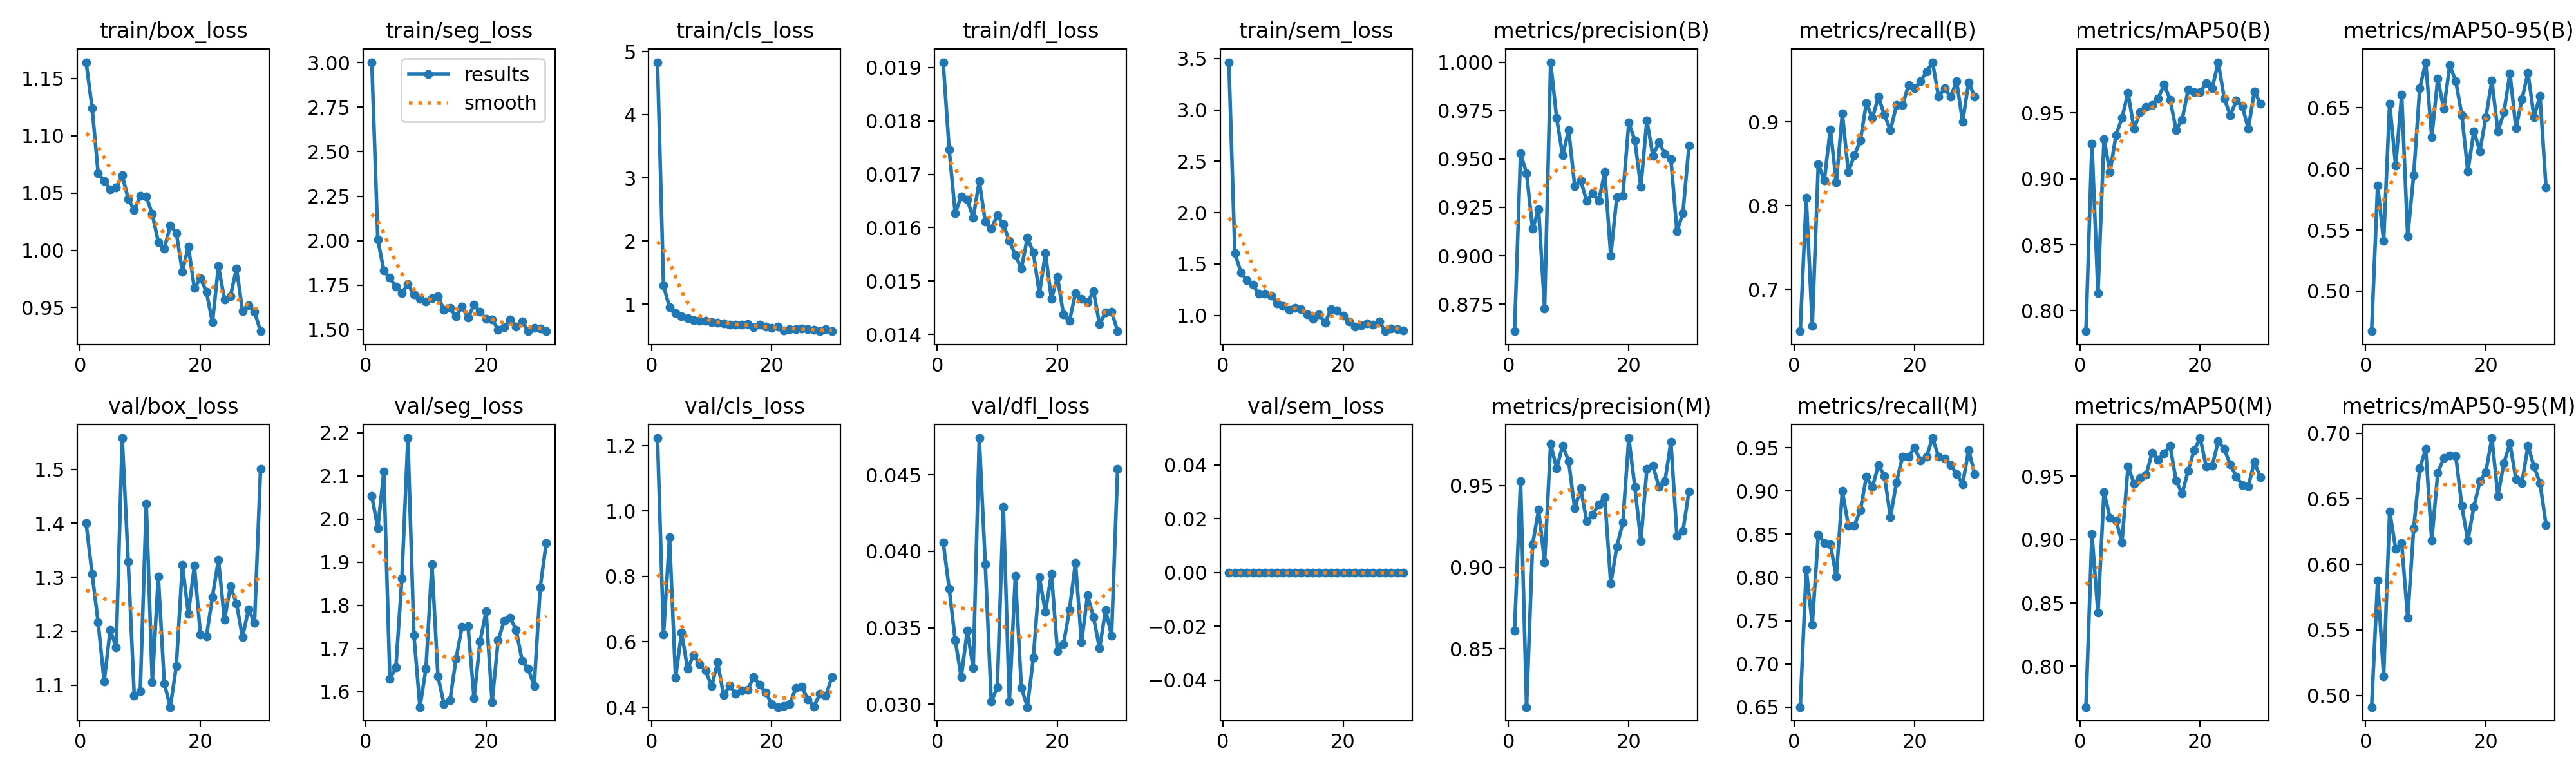
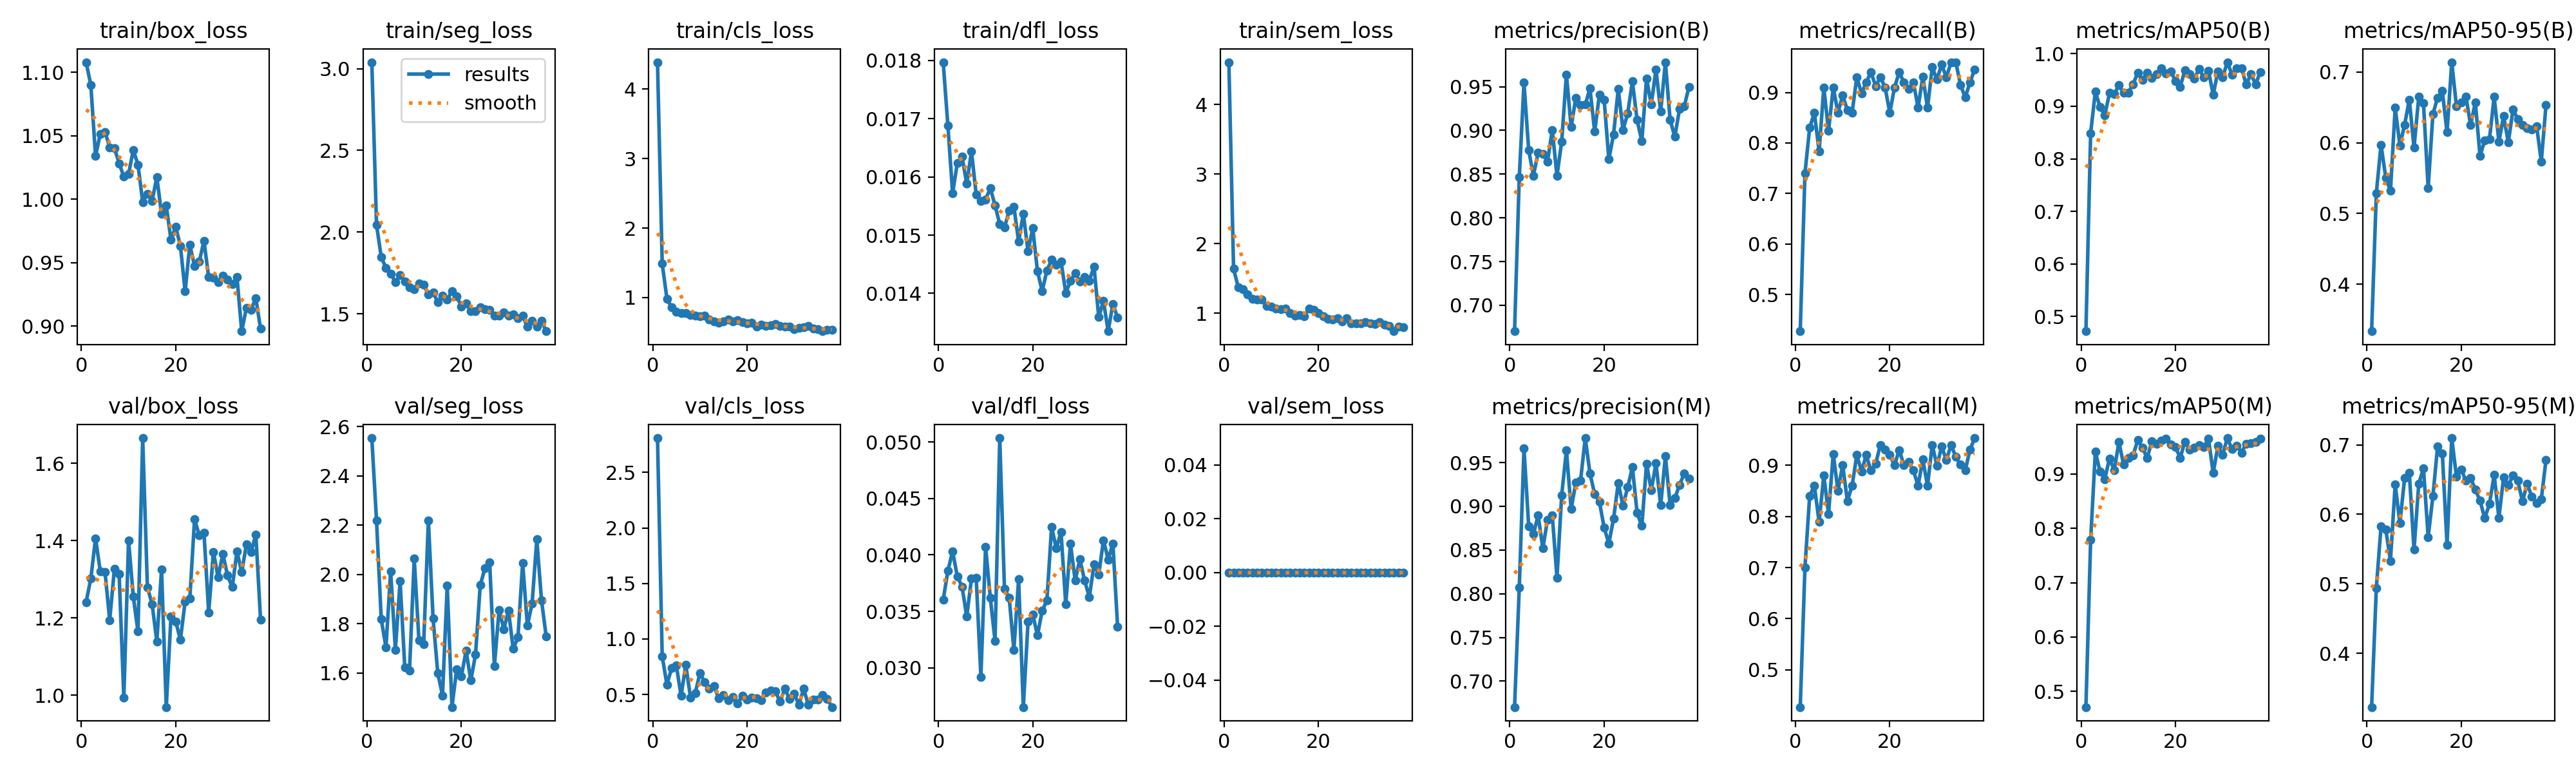
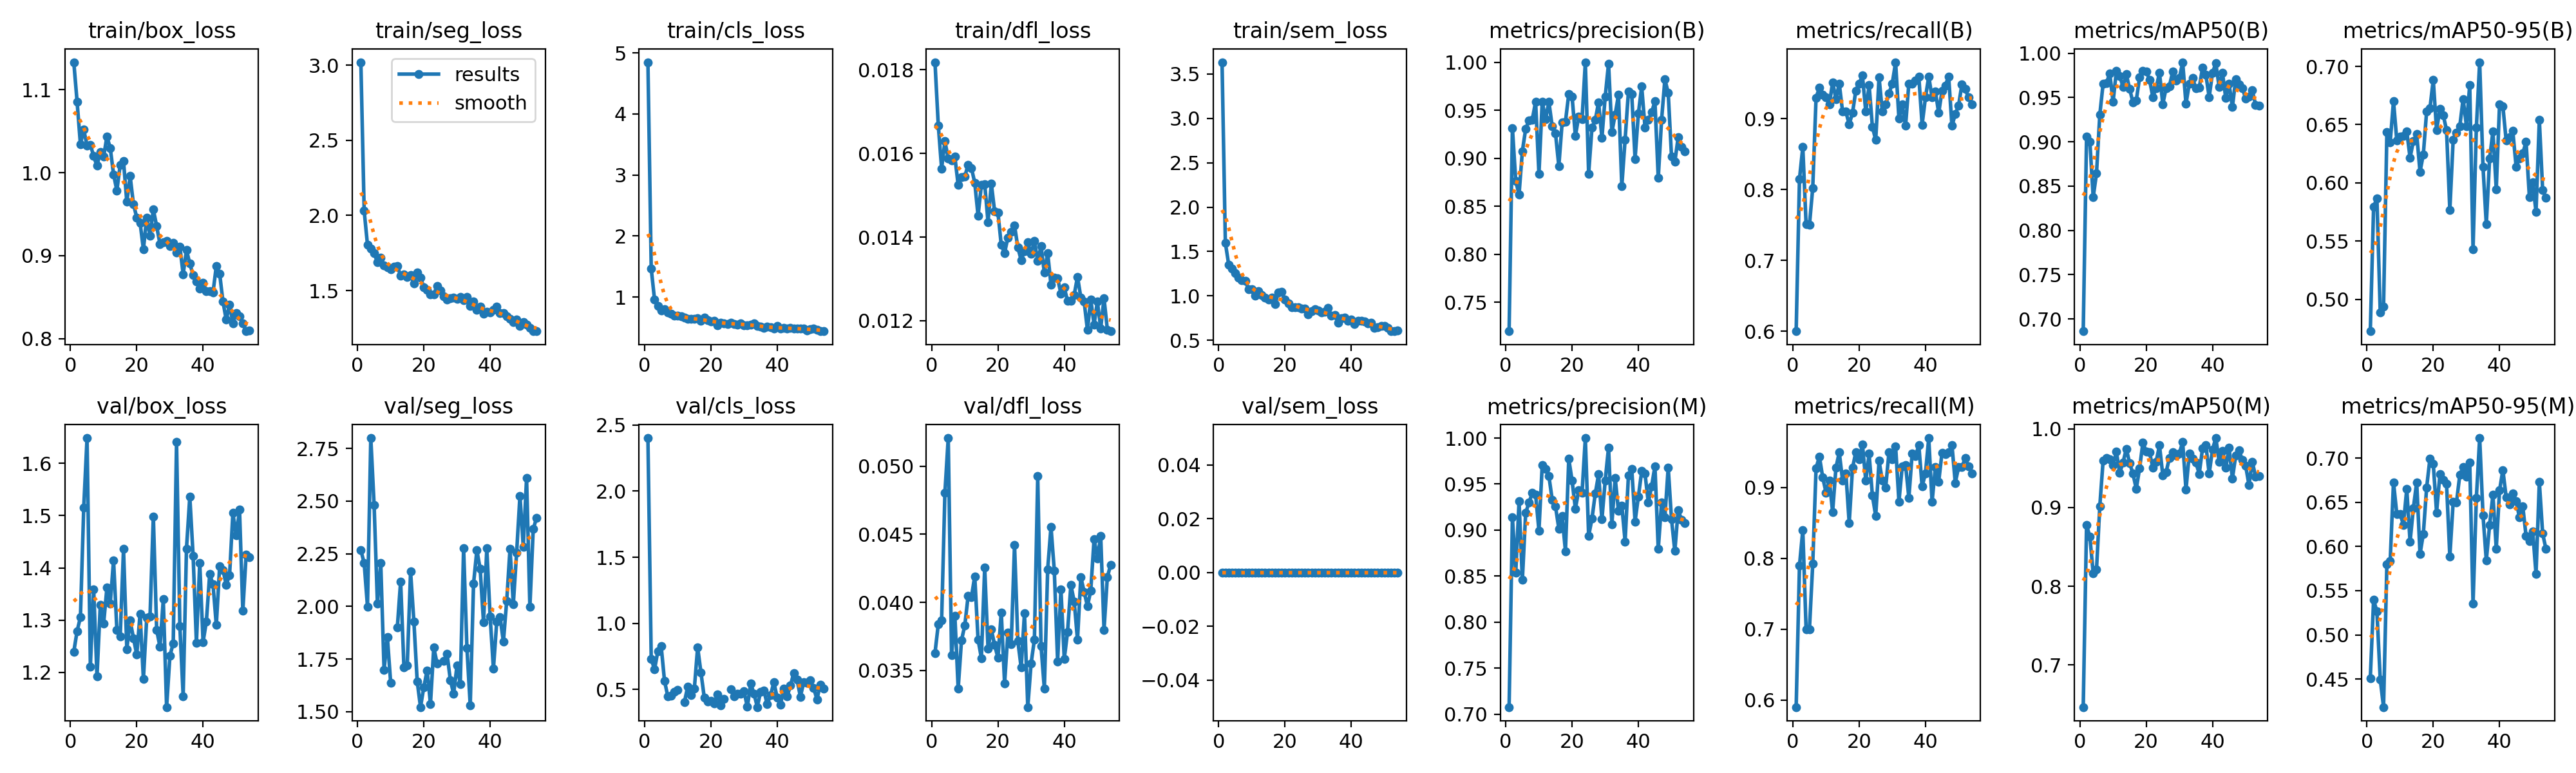
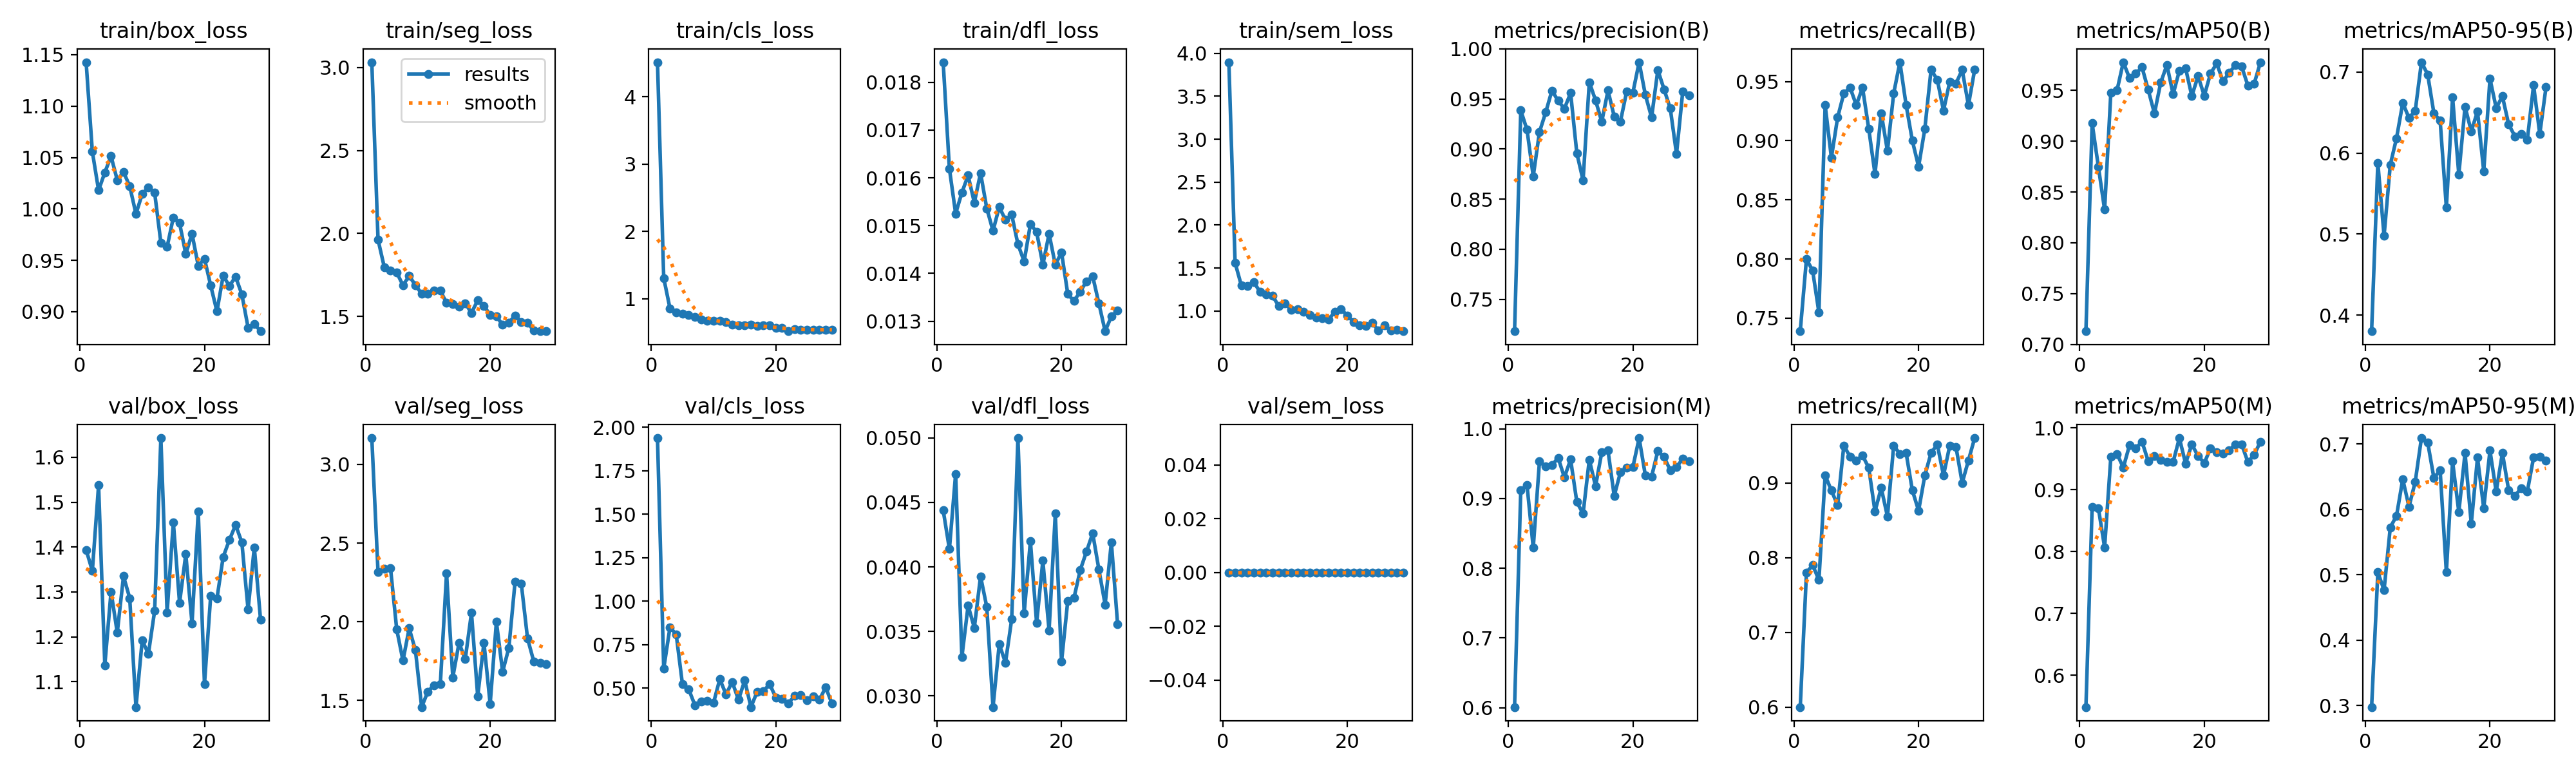

In [19]:
import base64

def get_base64_image(image_path: Path) -> str:
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


PLOTS_TO_COMPARE = {
    "Qualitative Predictions (Validation)": "val_batch0_pred.jpg",
    "Mask F1-Confidence Curve": "MaskF1_curve.png",
    "Results overview": "results.png",
}

from IPython.display import HTML

for plot_title, filename in PLOTS_TO_COMPARE.items():
    display(Markdown(f"### {plot_title}"))
    html = "<div style='display: flex; flex-wrap: wrap; justify-content: space-around;'>"
    for model_name in MODEL_ORDER_PRESENT:
        img_path = LOG_DIR / MODEL_DIRS[model_name] / filename
        if img_path.exists():
            img_b64 = get_base64_image(img_path)
            html += (
                f"<div style='text-align: center; margin: 10px; width: 45%;'>"
                f"<h4 style='font-family: monospace; color: {MODEL_PALETTE[model_name]};'>"
                f"{model_name}</h4>"
                f"<img src='data:image/jpeg;base64,{img_b64}' "
                f"style='width: 100%; border: 2px solid {MODEL_PALETTE[model_name]}; "
                f"border-radius: 4px; padding: 4px;'>"
                f"</div>"
            )
        else:
            html += (
                f"<div style='text-align: center; margin: 10px; width: 45%;'>"
                f"<h4 style='color: red;'>{model_name} (Image Not Found)</h4>"
                f"</div>"
            )
    html += "</div>"
    display(HTML(html))


## 18. Inferência qualitativa — comparação visual em imagens fixas

Esta seção compara as **predições visuais** de cada tamanho de modelo sobre **as
mesmas imagens** do conjunto de teste. Diferente da seção anterior (que
mostra batches gerados aleatoriamente pelo Ultralytics), aqui:

* Você escolhe **explicitamente** quais imagens analisar editando a lista
  `IMAGE_STEMS` abaixo. Isso garante reprodutibilidade e permite focar em
  casos específicos (lesão pequena, baixo contraste, presença de pelo etc).
* Cada imagem-âncora é renderizada em **uma figura única** com `1 GT + N
  paineis lado a lado` (Nano · Small · Medium · Large · XLarge), tornando a comparação visual
  imediata.
* Sob cada painel: o **IoU** entre a máscara predita e a ground-truth, em
  pixels — métrica direta da qualidade da segmentação naquela imagem.
* As figuras são salvas em `figures/qualitative/` para uso posterior em
  apresentações.

In [ ]:
# ============================================================================
# Configuração da inferência qualitativa
# ============================================================================
# Edite IMAGE_STEMS para escolher quais imagens do conjunto de teste comparar.
# Cada figura mostra GT + Nano + Small + Medium + Large + XLarge lado a lado.

IMAGE_STEMS = [
    "ISIC_0012086",
    "ISIC_0012092",
    "ISIC_0012099",
    "ISIC_0012209",
    "ISIC_0012219",
    "ISIC_0012238",
]

# Default = teste do ISIC. Para inspecionar OOD no PH2:
#   TEST_IMAGES_DIR = BASE_DIR / "datasets/ph2/test/images"
#   TEST_LABELS_DIR = BASE_DIR / "datasets/ph2/test/labels"
TEST_IMAGES_DIR = BASE_DIR / "datasets" / "isic_2018_task1_yolo26" / "test" / "images"
TEST_LABELS_DIR = BASE_DIR / "datasets" / "isic_2018_task1_yolo26" / "test" / "labels"

# AXIS_CONFIG: rótulo do eixo (model size) -> best.pt
AXIS_CONFIG = {}
for m in MODEL_ORDER_PRESENT:
    wpath = LOG_DIR / MODEL_DIRS[m] / "weights" / "best.pt"
    AXIS_CONFIG[m] = wpath

AXIS_PALETTE = {m: MODEL_PALETTE.get(m, "#444") for m in AXIS_CONFIG}

print(f"Eixo: tamanhos do modelo (v7)")
for k, v in AXIS_CONFIG.items():
    print(f"  {k:7s} {'[OK]' if v.exists() else '[MISSING]':9s} {v}")
print(f"\nImagens-âncora: {IMAGE_STEMS}")
print(f"Test images dir: {TEST_IMAGES_DIR}  ", "[OK]" if TEST_IMAGES_DIR.exists() else "[MISSING]")


In [ ]:
try:
    import cv2
    from ultralytics import YOLO
    _qual_ok = True
except ImportError as e:
    print(f"OpenCV / Ultralytics não disponíveis: {e} — pulando seção qualitativa.")
    _qual_ok = False

import time

ALPHA = 0.45
COLOR_GT_BGR   = (113, 204,  46)   # lime green
COLOR_PRED_BGR = ( 60,  20, 220)   # crimson red
SAVE_DIR = BASE_DIR / "figures" / "qualitative"


def _read_gt_polys(label_path: Path, h: int, w: int):
    polys = []
    if label_path.exists():
        with label_path.open() as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) > 1:
                    coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)
                    coords[:, 0] *= w
                    coords[:, 1] *= h
                    polys.append(coords.astype(np.int32))
    return polys


def _polys_to_mask(polys, h: int, w: int) -> np.ndarray:
    m = np.zeros((h, w), dtype=np.uint8)
    for p in polys:
        cv2.fillPoly(m, [p], 1)
    return m


def _iou(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union) if union > 0 else float("nan")


def _draw_polys(img, polys, color_bgr, alpha=ALPHA, outline=(255, 255, 255)):
    for p in polys:
        ov = img.copy()
        cv2.fillPoly(ov, [p], color_bgr)
        cv2.addWeighted(ov, alpha, img, 1 - alpha, 0, img)
        cv2.polylines(img, [p], isClosed=True, color=outline, thickness=3, lineType=cv2.LINE_8)


def _resolve_image(stem: str, img_dir: Path) -> Path | None:
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"):
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None


def compare_qualitative(image_stems, axis_config, axis_palette,
                        test_images_dir, test_labels_dir,
                        save_prefix: str, alt_image_dirs: dict | None = None):
    """Render side-by-side qualitative comparison.

    alt_image_dirs (optional): for color-space comparison, maps axis_label ->
      images_dir. The model loaded for that axis will be inferred on the
      same-stem image from that dir. GT polys always come from the canonical
      test_labels_dir (RGB layout, since geometry is the same)."""
    if not _qual_ok:
        return
    if not test_images_dir.exists():
        print(f"⚠ Test images dir não encontrada: {test_images_dir}")
        return

    # Carrega modelos uma vez
    print("Carregando modelos…")
    loaded = {}
    for axis, wpath in axis_config.items():
        if not wpath.exists():
            print(f"  ⚠ Pesos faltando para {axis}: {wpath}")
            continue
        loaded[axis] = YOLO(wpath)
    if not loaded:
        print("Nenhum modelo carregado — pulando.")
        return

    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    for stem in image_stems:
        img_path = _resolve_image(stem, test_images_dir)
        if img_path is None:
            print(f"  ⚠ Imagem não encontrada (test/): {stem}")
            continue
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            print(f"  ⚠ Falha lendo {img_path}")
            continue
        h, w = img_bgr.shape[:2]

        gt_polys = _read_gt_polys(test_labels_dir / f"{stem}.txt", h, w)
        gt_mask = _polys_to_mask(gt_polys, h, w)

        n_panels = 1 + len(loaded)  # GT + axes
        cols = min(n_panels, 4)
        rows = (n_panels + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 4.8 * rows))
        axes = np.atleast_1d(axes).flatten()

        # GT panel (sempre no slot 0)
        img_gt = img_bgr.copy()
        _draw_polys(img_gt, gt_polys, COLOR_GT_BGR)
        axes[0].imshow(cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Ground Truth", fontsize=12, fontweight="bold")
        axes[0].axis("off")

        # paineis por eixo
        for idx, (axis, model) in enumerate(loaded.items(), start=1):
            # imagem usada para inferência (pode ser HED/LAB)
            inf_path = img_path
            if alt_image_dirs and axis in alt_image_dirs:
                alt = _resolve_image(stem, alt_image_dirs[axis])
                if alt is not None:
                    inf_path = alt
            inf_img = cv2.imread(str(inf_path))
            if inf_img is None:
                axes[idx].axis("off")
                axes[idx].set_title(f"{axis}\n(read fail)", fontsize=11)
                continue

            t0 = time.perf_counter()
            res = model.predict(source=inf_img, conf=0.5, imgsz=640, verbose=False)
            dt_ms = (time.perf_counter() - t0) * 1000

            # canvas para visualização — sempre desenha sobre o RGB original
            disp = img_bgr.copy()
            # GT em verde por baixo
            for p in gt_polys:
                cv2.polylines(disp, [p], isClosed=True, color=COLOR_GT_BGR,
                              thickness=3, lineType=cv2.LINE_AA)

            pred_polys = []
            if res[0].masks is not None and len(res[0].masks.xy) > 0:
                for mxy in res[0].masks.xy:
                    pred_polys.append(mxy.astype(np.int32))
                _draw_polys(disp, pred_polys, COLOR_PRED_BGR)

            # IoU pixel-wise
            pred_mask = _polys_to_mask(pred_polys, h, w)
            iou_val = _iou(gt_mask, pred_mask)
            iou_str = f"IoU = {iou_val:.3f}" if not np.isnan(iou_val) else "IoU = n/a"

            axes[idx].imshow(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB))
            color = axis_palette.get(axis, "#444")
            axes[idx].set_title(f"{axis}    {iou_str}\n{dt_ms:.1f} ms",
                                fontsize=11, color=color, fontweight="bold")
            axes[idx].axis("off")

        # off para slots vazios
        for j in range(n_panels, len(axes)):
            axes[j].axis("off")

        fig.suptitle(f"{img_path.name}", fontsize=13, y=1.02)
        plt.tight_layout()
        out_path = SAVE_DIR / f"{save_prefix}_{stem}.png"
        plt.savefig(out_path, dpi=130, bbox_inches="tight")
        plt.show()
        print(f"  saved → {out_path}")


In [ ]:
compare_qualitative(
    image_stems=IMAGE_STEMS,
    axis_config=AXIS_CONFIG,
    axis_palette=AXIS_PALETTE,
    test_images_dir=TEST_IMAGES_DIR,
    test_labels_dir=TEST_LABELS_DIR,
    save_prefix="compare_models_v7",
)


## 19. Export — tabela completa para CSV

In [21]:
export_cols = [
    "Model", "Params (M)", "GFLOPs",
    "Mask mAP@50", "Mask mAP@50-95", "BBox mAP@50", "BBox mAP@50-95",
    "Mask Precision", "Mask Recall", "Mask retention",
    "Val seg_loss", "Train seg_loss", "Overfit gap (seg)",
    "Best epoch", "Total epochs", "Train time (min)",
    "Eps to 95% best", "Eps to 99% best", "Stability (std last10)",
    "lr/pg0 start", "lr/pg0 mid", "lr/pg0 end",
    "mAP / min", "mAP / M-param",
    "optimizer", "lr0", "amp", "batch", "weight_decay", "dropout",
]
export_cols = [c for c in export_cols if c in df_long.columns]
export = df_long[export_cols].copy()

out = BASE_DIR / "logs" / "compare_models_v7_summary.csv"
try:
    export.to_csv(out, index=False)
    print(f"Salvo: {out}")
except OSError as e:
    print(f"(sem permissão para salvar em {out}: {e})")

display(export.style.format(precision=4, na_rep="—"))


Salvo: /home/antoniovinicius/projects/sandbox_yolo26/logs/compare_models_v7_summary.csv


,Model,Params (M),GFLOPs,Mask mAP@50,Mask mAP@50-95,BBox mAP@50,BBox mAP@50-95,Mask Precision,Mask Recall,Mask retention,Val seg_loss,Train seg_loss,Overfit gap (seg),Best epoch,Total epochs,Train time (min),Eps to 95% best,Eps to 99% best,Stability (std last10),lr/pg0 start,lr/pg0 mid,lr/pg0 end,mAP / min,mAP / M-param,optimizer,lr0,amp,batch,weight_decay,dropout
0,Nano,3.4000,10.4000,0.9578,0.6960,0.9575,0.6893,0.9085,0.8938,0.7266,1.5625,1.6043,-0.0418,20,40,21.2078,14,20,0.0200,0.0045,0.0056,0.0047,0.0328,0.2047,MuSGD,0.0020,True,32,0.0005,0.0000
1,Small,11.4000,37.1000,0.9576,0.6964,0.9728,0.6723,0.9493,0.9353,0.7272,1.5760,1.5579,0.0181,21,30,17.7677,9,21,0.0204,0.0040,0.0058,0.0052,0.0392,0.0611,MuSGD,0.0020,True,32,0.0005,0.0000
2,Medium,25.9000,98.9000,0.9653,0.7097,0.9622,0.7140,0.9137,0.9400,0.7352,1.4623,1.6365,-0.1741,18,38,31.7605,15,18,0.0196,0.0040,0.0057,0.0048,0.0223,0.0274,MuSGD,0.0020,True,32,0.0005,0.0000
3,Large,43.7000,165.7000,0.9618,0.7227,0.9718,0.7036,0.9210,0.9321,0.7514,1.5296,1.3960,0.1335,34,54,52.6363,19,34,0.0298,0.0048,0.0053,0.0037,0.0137,0.0165,MuSGD,0.0020,True,32,0.0005,0.0000
4,XLarge,68.2000,257.8000,0.9670,0.7090,0.9665,0.7120,0.9303,0.9349,0.7332,1.4582,1.6359,-0.1777,9,29,38.1735,9,9,0.0293,0.0030,0.0058,0.0053,0.0186,0.0104,MuSGD,0.0020,True,32,0.0005,0.0000
